In [1]:
#  Các thư viện sau đã được cài sẵn trên hệ thống AI UITIOT:
# torch, torchvision, pandas, scikit-learn, matplotlib, seaborn, pillow, tensorflow
# KHÔNG cần cài lại — cài lại có thể gây xung đột phiên bản!
print('Hệ thống AI UITIOT đã có sẵn các thư viện cần thiết.')

Hệ thống AI UITIOT đã có sẵn các thư viện cần thiết.


In [ ]:
#  tensorflow==2.19.1 đã được cài sẵn trên hệ thống AI UITIOT
# KHÔNG cần cài lại!
# !pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 805.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 91.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 71.6 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [ ]:
#  keras==3.x đã được cài sẵn trên hệ thống AI UITIOT
# KHÔNG cần cài lại!
# !pip install keras

In [2]:
#   eli5 chưa có sẵn trên hệ thống AI UITIOT → cần cài
!pip install eli5

Defaulting to user installation because normal site-packages is not writeable


In [3]:
#  opencv-python đã có sẵn trên hệ thống AI UITIOT (4.13.0.92) — KHÔNG cần cài lại
#  Các thư viện sau cũng đã có sẵn: pandas, numpy, matplotlib, seaborn, pillow, tensorflow, scikit-learn

# ── Tắt warning CUDA không cần thiết khi import TensorFlow ──────────────
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # 0=all, 1=info, 2=warning, 3=error

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os
import cv2
import h5py

# Deep learning libraries
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, Input, concatenate
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, VGG16
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

2026-05-07 02:43:59.048383: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778121839.084291  889350 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778121839.096771  889350 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778121839.126055  889350 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778121839.126108  889350 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778121839.126115  889350 computation_placer.cc:177] computation placer alr

In [4]:
#import torch
#import torchvision
import pandas as pd
import sklearn
import matplotlib
import seaborn
import PIL
import tensorflow
import keras
import eli5

#print("torch:", torch.__version__)
#print("torchvision:", torchvision.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", seaborn.__version__)
print("Pillow:", PIL.__version__)
print("tensorflow:", tensorflow.__version__)
print("keras:", keras.__version__)
print("eli5:", eli5.__version__)

pandas: 2.3.3
scikit-learn: 1.8.0
matplotlib: 3.10.8
seaborn: 0.13.2
Pillow: 12.1.0
tensorflow: 2.19.1
keras: 3.12.0
eli5: 0.16.0


In [5]:
#   boto3 và s3fs chưa có sẵn trên hệ thống AI UITIOT → cần cài
!pip install boto3 s3fs


Defaulting to user installation because normal site-packages is not writeable


In [6]:
!pip install python-dotenv
import boto3
import s3fs
import os

# ─── Cấu hình AWS Credentials ───────────────────────────────────────────────
# CÁCH 1: Thiết lập biến môi trường (khuyên dùng trong Colab)
# Đảm bảo bạn đã cấu hình các biến môi trường này trong Colab secrets
# hoặc thay thế bằng giá trị trực tiếp (KHÔNG KHUYẾN KHÍCH KHI DÙNG CHUNG)

# os.environ['AWS_ACCESS_KEY_ID']     = 'YOUR_AWS_ACCESS_KEY_ID'
# os.environ['AWS_SECRET_ACCESS_KEY'] = 'YOUR_AWS_SECRET_ACCESS_KEY'
# os.environ['AWS_SESSION_TOKEN']     = 'YOUR_AWS_SESSION_TOKEN' # Chỉ cần nếu dùng temporary credentials

# Cách tốt nhất là dùng Colab secrets:
from dotenv import load_dotenv

load_dotenv(dotenv_path="load.env")


AWS_ACCESS_KEY_ID     = os.getenv("AWS_ACCESS_KEY_ID")
AWS_SECRET_ACCESS_KEY = os.getenv("AWS_SECRET_ACCESS_KEY")
AWS_SESSION_TOKEN = None

print(AWS_ACCESS_KEY_ID is not None)
print(AWS_SECRET_ACCESS_KEY is not None)

# ─── Cấu hình S3 ────────────────────────────────────────────────────────────
S3_INPUT_BUCKET  = 'kltn-isic-2024-challenge'
S3_INPUT_PREFIX  = 'isic-2024-challenge'          # thư mục gốc trong bucket nguồn
S3_OUTPUT_BUCKET = 'kltn-isic-2024-colab'     # bucket lưu dữ liệu đã xử lý

# Đường dẫn S3 tới từng file thô
S3_METADATA_PATH = f's3://{S3_INPUT_BUCKET}/{S3_INPUT_PREFIX}/train-metadata.csv'
S3_HDF5_PATH     = f's3://{S3_INPUT_BUCKET}/{S3_INPUT_PREFIX}/train-image.hdf5'

# Đường dẫn local tạm (Colab /content)
LOCAL_METADATA = 'train-metadata.csv'
LOCAL_HDF5     = 'train-image.hdf5'

# Khởi tạo S3 client với credentials
s3_client = boto3.client(
    's3',
    aws_access_key_id=AWS_ACCESS_KEY_ID,
    aws_secret_access_key=AWS_SECRET_ACCESS_KEY,
    aws_session_token=AWS_SESSION_TOKEN,
)

# s3fs cũng cần credentials
fs = s3fs.S3FileSystem(
    anon=False,
    key=AWS_ACCESS_KEY_ID,
    secret=AWS_SECRET_ACCESS_KEY,
    token=AWS_SESSION_TOKEN,
)

print(f'Input  S3 bucket : s3://{S3_INPUT_BUCKET}/{S3_INPUT_PREFIX}/')
print(f'Output S3 bucket : s3://{S3_OUTPUT_BUCKET}/')

# ─── Tải metadata CSV từ S3 ─────────────────────────────────────────────────
print('\nĐang tải train-metadata.csv từ S3...')
s3_client.download_file(
    S3_INPUT_BUCKET,
    f'{S3_INPUT_PREFIX}/train-metadata.csv',
    LOCAL_METADATA
)
print(f'   Đã lưu -> {LOCAL_METADATA}')

# ─── Tải HDF5 ảnh từ S3 ─────────────────────────────────────────────────────
print('\nĐang tải train-image.hdf5 từ S3 (file lớn, có thể mất vài phút)...')
s3_client.download_file(
    S3_INPUT_BUCKET,
    f'{S3_INPUT_PREFIX}/train-image.hdf5',
    LOCAL_HDF5
)
print(f'   Đã lưu -> {LOCAL_HDF5}')

Defaulting to user installation because normal site-packages is not writeable
True
True
Input  S3 bucket : s3://kltn-isic-2024-challenge/isic-2024-challenge/
Output S3 bucket : s3://kltn-isic-2024-colab/

Đang tải train-metadata.csv từ S3...
   Đã lưu -> train-metadata.csv

Đang tải train-image.hdf5 từ S3 (file lớn, có thể mất vài phút)...
   Đã lưu -> train-image.hdf5


In [7]:
import boto3

# ─── Tạo S3 output bucket để lưu dữ liệu đã xử lý ─────────────────
# Cấu trúc bucket theo sơ đồ tổ chức dữ liệu:
#
#  s3://kltn-isic-2024-processed/
#  ├── raw/
#  │   ├── all_images/             ← Ảnh trích xuất từ HDF5
#  │   └── metadata.csv            ← Metadata gốc
#  ├── preprocessed/
#  │   ├── metadata_clean.csv      ← Metadata sau làm sạch
#  │   ├── images_resized/         ← Ảnh đã resize/tiền xử lý
#  │   └── encoders.pkl            ← LabelEncoder / scaler đã fit
#  ├── features/
#  │   ├── X_tabular.npy           ← Đặc trưng tabular
#  │   ├── X_images.npy            ← Đặc trưng ảnh
#  │   └── y_labels.npy            ← Nhãn
#  └── splits/
#      ├── train/
#      │   ├── X_tab_train.npy
#      │   └── X_img_train.npy
#      ├── val/
#      │   ├── X_tab_val.npy
#      │   └── X_img_val.npy
#      └── test/
#          ├── X_tab_test.npy
#          └── X_img_test.npy

S3_OUTPUT_BUCKET = 'kltn-isic-2024-colab'
AWS_REGION       = 'ap-southeast-1'   # Đổi region nếu cần

s3_client = boto3.client(
    's3',
    region_name=AWS_REGION,
    aws_access_key_id=AWS_ACCESS_KEY_ID,
    aws_secret_access_key=AWS_SECRET_ACCESS_KEY,
    aws_session_token=AWS_SESSION_TOKEN
)

def create_s3_bucket_if_not_exists(bucket_name, region):
    try:
        s3_client.head_bucket(Bucket=bucket_name)
        print(f'  Bucket đã tồn tại: s3://{bucket_name}')
    except s3_client.exceptions.ClientError:
        try:
            if region == 'us-east-1':
                s3_client.create_bucket(Bucket=bucket_name)
            else:
                s3_client.create_bucket(
                    Bucket=bucket_name,
                    CreateBucketConfiguration={'LocationConstraint': region}
                )
            print(f'   Đã tạo bucket: s3://{bucket_name}')
        except Exception as e:
            print(f'   Lỗi tạo bucket: {e}')

create_s3_bucket_if_not_exists(S3_OUTPUT_BUCKET, AWS_REGION)

# Helper: upload file lên S3
def upload_to_s3(local_path, s3_key, bucket=S3_OUTPUT_BUCKET):
    print(f'  Uploading {local_path} -> s3://{bucket}/{s3_key}')
    s3_client.upload_file(local_path, bucket, s3_key)
    print(f'   Done')

print('\nS3 output bucket sẵn sàng!')
print(f'   s3://{S3_OUTPUT_BUCKET}/')


  Bucket đã tồn tại: s3://kltn-isic-2024-colab

S3 output bucket sẵn sàng!
   s3://kltn-isic-2024-colab/


In [8]:
np.random.seed(42)
tf.random.set_seed(42)

In [9]:
def load_csv_data(file_path):
    """
    Tải EHR data từ CSV file (train-metadata.csv của ISIC 2024)
    """
    print("Loading CSV data...")
    df = pd.read_csv(file_path)
    return df

In [10]:
# Hiển thị thông tin dữ liệu CSV
# ISIC 2024: file metadata là train-metadata.csv
df = load_csv_data(LOCAL_METADATA)
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
df.head()

Loading CSV data...


/tmp/ipykernel_889350/2835783501.py:6: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Dataset shape: (401059, 55)

First few rows:


,isic_id,target,patient_id,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,image_type,tbp_tile_type,tbp_lv_A,...,lesion_id,iddx_full,iddx_1,iddx_2,iddx_3,iddx_4,iddx_5,mel_mitotic_index,mel_thick_mm,tbp_lv_dnn_lesion_confidence
0,ISIC_0015670,0,IP_1235828,60.0,male,lower extremity,3.04,TBP tile: close-up,3D: white,20.244422,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,97.517282
1,ISIC_0015845,0,IP_8170065,60.0,male,head/neck,1.10,TBP tile: close-up,3D: white,31.712570,...,IL_6727506,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,3.141455
2,ISIC_0015864,0,IP_6724798,60.0,male,posterior torso,3.40,TBP tile: close-up,3D: XP,22.575830,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.804040
3,ISIC_0015902,0,IP_4111386,65.0,male,anterior torso,3.22,TBP tile: close-up,3D: XP,14.242329,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.989998
4,ISIC_0024200,0,IP_8313778,55.0,male,anterior torso,2.73,TBP tile: close-up,3D: white,24.725520,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,70.442510


In [11]:
# 2.1 Phân phối dữ liệu
"""
 Phân tích:
Số lượng giá trị duy nhất trong mỗi cột
Number of unique values in each column
Kiểm tra giá trị thiếu trong mỗi cột
Missing values in each column
"""
print("\nUnique values in each column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")


Unique values in each column:
isic_id: 401059 unique values
target: 2 unique values
patient_id: 1042 unique values
age_approx: 16 unique values
sex: 2 unique values
anatom_site_general: 5 unique values
clin_size_long_diam_mm: 1758 unique values
image_type: 1 unique values
tbp_tile_type: 2 unique values
tbp_lv_A: 386052 unique values
tbp_lv_Aext: 385304 unique values
tbp_lv_B: 389890 unique values
tbp_lv_Bext: 387763 unique values
tbp_lv_C: 390703 unique values
tbp_lv_Cext: 388865 unique values
tbp_lv_H: 389798 unique values
tbp_lv_Hext: 390743 unique values
tbp_lv_L: 395726 unique values
tbp_lv_Lext: 396358 unique values
tbp_lv_areaMM2: 8029 unique values
tbp_lv_area_perim_ratio: 167648 unique values
tbp_lv_color_std_mean: 371189 unique values
tbp_lv_deltaA: 398257 unique values
tbp_lv_deltaB: 398886 unique values
tbp_lv_deltaL: 396505 unique values
tbp_lv_deltaLB: 395511 unique values
tbp_lv_deltaLBnorm: 396877 unique values
tbp_lv_eccentricity: 396648 unique values
tbp_lv_location: 

In [12]:
# 2.2 Kiểm tra các giá trị còn thiếu
print("\nMissing values in each column:")
print(df.isnull().sum())


Missing values in each column:
isic_id                              0
target                               0
patient_id                           0
age_approx                        2798
sex                              11517
anatom_site_general               5756
clin_size_long_diam_mm               0
image_type                           0
tbp_tile_type                        0
tbp_lv_A                             0
tbp_lv_Aext                          0
tbp_lv_B                             0
tbp_lv_Bext                          0
tbp_lv_C                             0
tbp_lv_Cext                          0
tbp_lv_H                             0
tbp_lv_Hext                          0
tbp_lv_L                             0
tbp_lv_Lext                          0
tbp_lv_areaMM2                       0
tbp_lv_area_perim_ratio              0
tbp_lv_color_std_mean                0
tbp_lv_deltaA                        0
tbp_lv_deltaB                        0
tbp_lv_deltaL                   

In [13]:
# ===== Khám phá dữ liệu cơ bản =====
print("=== THÔNG TIN TỔNG QUAN VỀ DATASET ISIC 2024 ===")
print(f"Số dòng: {df.shape[0]}")
print(f"Số cột: {df.shape[1]}")
print(f"\nTên các cột:")
for i, col in enumerate(df.columns):
    print(f"{i+1}. {col}")

print(f"\nKiểu dữ liệu:")
print(df.dtypes)

print(f"\nMẫu dữ liệu đầu tiên:")
display(df.head())

print(f"\nThống kê mô tả:")
display(df.describe())

# ===== Kiểm tra và làm sạch dữ liệu =====
print("=== KIỂM TRA DỮ LIỆU THIẾU ===")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])

# Hiển thị % dữ liệu thiếu
if missing_data.sum() > 0:
    missing_percent = (df.isnull().sum() / len(df)) * 100
    missing_df = pd.DataFrame({
        'Cột': df.columns,
        'Số dòng thiếu': missing_data,
        'Phần trăm': missing_percent
    })
    display(missing_df[missing_df['Số dòng thiếu'] > 0])
else:
    print("Không có dữ liệu thiếu!")

=== THÔNG TIN TỔNG QUAN VỀ DATASET ISIC 2024 ===
Số dòng: 401059
Số cột: 55

Tên các cột:
1. isic_id
2. target
3. patient_id
4. age_approx
5. sex
6. anatom_site_general
7. clin_size_long_diam_mm
8. image_type
9. tbp_tile_type
10. tbp_lv_A
11. tbp_lv_Aext
12. tbp_lv_B
13. tbp_lv_Bext
14. tbp_lv_C
15. tbp_lv_Cext
16. tbp_lv_H
17. tbp_lv_Hext
18. tbp_lv_L
19. tbp_lv_Lext
20. tbp_lv_areaMM2
21. tbp_lv_area_perim_ratio
22. tbp_lv_color_std_mean
23. tbp_lv_deltaA
24. tbp_lv_deltaB
25. tbp_lv_deltaL
26. tbp_lv_deltaLB
27. tbp_lv_deltaLBnorm
28. tbp_lv_eccentricity
29. tbp_lv_location
30. tbp_lv_location_simple
31. tbp_lv_minorAxisMM
32. tbp_lv_nevi_confidence
33. tbp_lv_norm_border
34. tbp_lv_norm_color
35. tbp_lv_perimeterMM
36. tbp_lv_radial_color_std_max
37. tbp_lv_stdL
38. tbp_lv_stdLExt
39. tbp_lv_symm_2axis
40. tbp_lv_symm_2axis_angle
41. tbp_lv_x
42. tbp_lv_y
43. tbp_lv_z
44. attribution
45. copyright_license
46. lesion_id
47. iddx_full
48. iddx_1
49. iddx_2
50. iddx_3
51. iddx_4
52. i

,isic_id,target,patient_id,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,image_type,tbp_tile_type,tbp_lv_A,...,lesion_id,iddx_full,iddx_1,iddx_2,iddx_3,iddx_4,iddx_5,mel_mitotic_index,mel_thick_mm,tbp_lv_dnn_lesion_confidence
0,ISIC_0015670,0,IP_1235828,60.0,male,lower extremity,3.04,TBP tile: close-up,3D: white,20.244422,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,97.517282
1,ISIC_0015845,0,IP_8170065,60.0,male,head/neck,1.10,TBP tile: close-up,3D: white,31.712570,...,IL_6727506,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,3.141455
2,ISIC_0015864,0,IP_6724798,60.0,male,posterior torso,3.40,TBP tile: close-up,3D: XP,22.575830,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.804040
3,ISIC_0015902,0,IP_4111386,65.0,male,anterior torso,3.22,TBP tile: close-up,3D: XP,14.242329,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.989998
4,ISIC_0024200,0,IP_8313778,55.0,male,anterior torso,2.73,TBP tile: close-up,3D: white,24.725520,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,70.442510



Thống kê mô tả:


,target,age_approx,clin_size_long_diam_mm,tbp_lv_A,tbp_lv_Aext,tbp_lv_B,tbp_lv_Bext,tbp_lv_C,tbp_lv_Cext,tbp_lv_H,...,tbp_lv_radial_color_std_max,tbp_lv_stdL,tbp_lv_stdLExt,tbp_lv_symm_2axis,tbp_lv_symm_2axis_angle,tbp_lv_x,tbp_lv_y,tbp_lv_z,mel_thick_mm,tbp_lv_dnn_lesion_confidence
count,401059.000000,398261.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,...,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,63.000000,4.010590e+05
mean,0.000980,58.012986,3.930827,19.974007,14.919247,28.281706,26.913015,34.786341,30.921279,54.653689,...,1.016459,2.715190,2.238605,0.306823,86.332073,-3.091862,1039.598221,55.823389,0.670952,9.716220e+01
std,0.031288,13.596165,1.743068,3.999489,3.529384,5.278676,4.482994,5.708469,4.829345,5.520849,...,0.734631,1.738165,0.623884,0.125038,52.559511,197.257995,409.819653,87.968245,0.792798,8.995782e+00
min,0.000000,5.000000,1.000000,-2.487115,-9.080269,-0.730989,9.237066,3.054228,11.846520,-1.574164,...,0.000000,0.268160,0.636247,0.052034,0.000000,-624.870728,-1052.134000,-291.890442,0.200000,1.261082e-16
25%,0.000000,50.000000,2.840000,17.330821,12.469740,24.704372,23.848125,31.003148,27.658285,51.566273,...,0.563891,1.456570,1.834745,0.211429,40.000000,-147.022125,746.519673,-8.962647,0.300000,9.966882e+01
50%,0.000000,60.000000,3.370000,19.801910,14.713930,28.171570,26.701704,34.822580,30.804893,55.035632,...,0.902281,2.186693,2.149758,0.282297,90.000000,-5.747253,1172.803000,67.957947,0.400000,9.999459e+01
75%,0.000000,70.000000,4.380000,22.304628,17.137175,31.637429,29.679913,38.430298,33.963868,58.298184,...,1.334523,3.474565,2.531443,0.382022,130.000000,140.474835,1342.131540,126.611567,0.600000,9.999996e+01
max,1.000000,85.000000,28.400000,48.189610,37.021680,54.306900,48.372700,58.765170,54.305290,105.875784,...,11.491140,17.563650,25.534791,0.977055,175.000000,614.471700,1887.766846,319.407000,5.000000,1.000000e+02


=== KIỂM TRA DỮ LIỆU THIẾU ===
age_approx               2798
sex                     11517
anatom_site_general      5756
lesion_id              379001
iddx_2                 399991
iddx_3                 399994
iddx_4                 400508
iddx_5                 401058
mel_mitotic_index      401006
mel_thick_mm           400996
dtype: int64


,Cột,Số dòng thiếu,Phần trăm
age_approx,age_approx,2798,0.697653
sex,sex,11517,2.871647
anatom_site_general,anatom_site_general,5756,1.435200
lesion_id,lesion_id,379001,94.500061
iddx_2,iddx_2,399991,99.733705
iddx_3,iddx_3,399994,99.734453
iddx_4,iddx_4,400508,99.862614
iddx_5,iddx_5,401058,99.999751
mel_mitotic_index,mel_mitotic_index,401006,99.986785
mel_thick_mm,mel_thick_mm,400996,99.984292


In [14]:
# 2.2 Kiểm tra các giá trị còn thiếu
print("\nMissing values in each column:")
print(df.isnull().sum())


Missing values in each column:
isic_id                              0
target                               0
patient_id                           0
age_approx                        2798
sex                              11517
anatom_site_general               5756
clin_size_long_diam_mm               0
image_type                           0
tbp_tile_type                        0
tbp_lv_A                             0
tbp_lv_Aext                          0
tbp_lv_B                             0
tbp_lv_Bext                          0
tbp_lv_C                             0
tbp_lv_Cext                          0
tbp_lv_H                             0
tbp_lv_Hext                          0
tbp_lv_L                             0
tbp_lv_Lext                          0
tbp_lv_areaMM2                       0
tbp_lv_area_perim_ratio              0
tbp_lv_color_std_mean                0
tbp_lv_deltaA                        0
tbp_lv_deltaB                        0
tbp_lv_deltaL                   

Sử dụng cột 'target' làm cột chẩn đoán
Phân bố nhãn: 0 = Benign (lành tính), 1 = Malignant (ác tính)


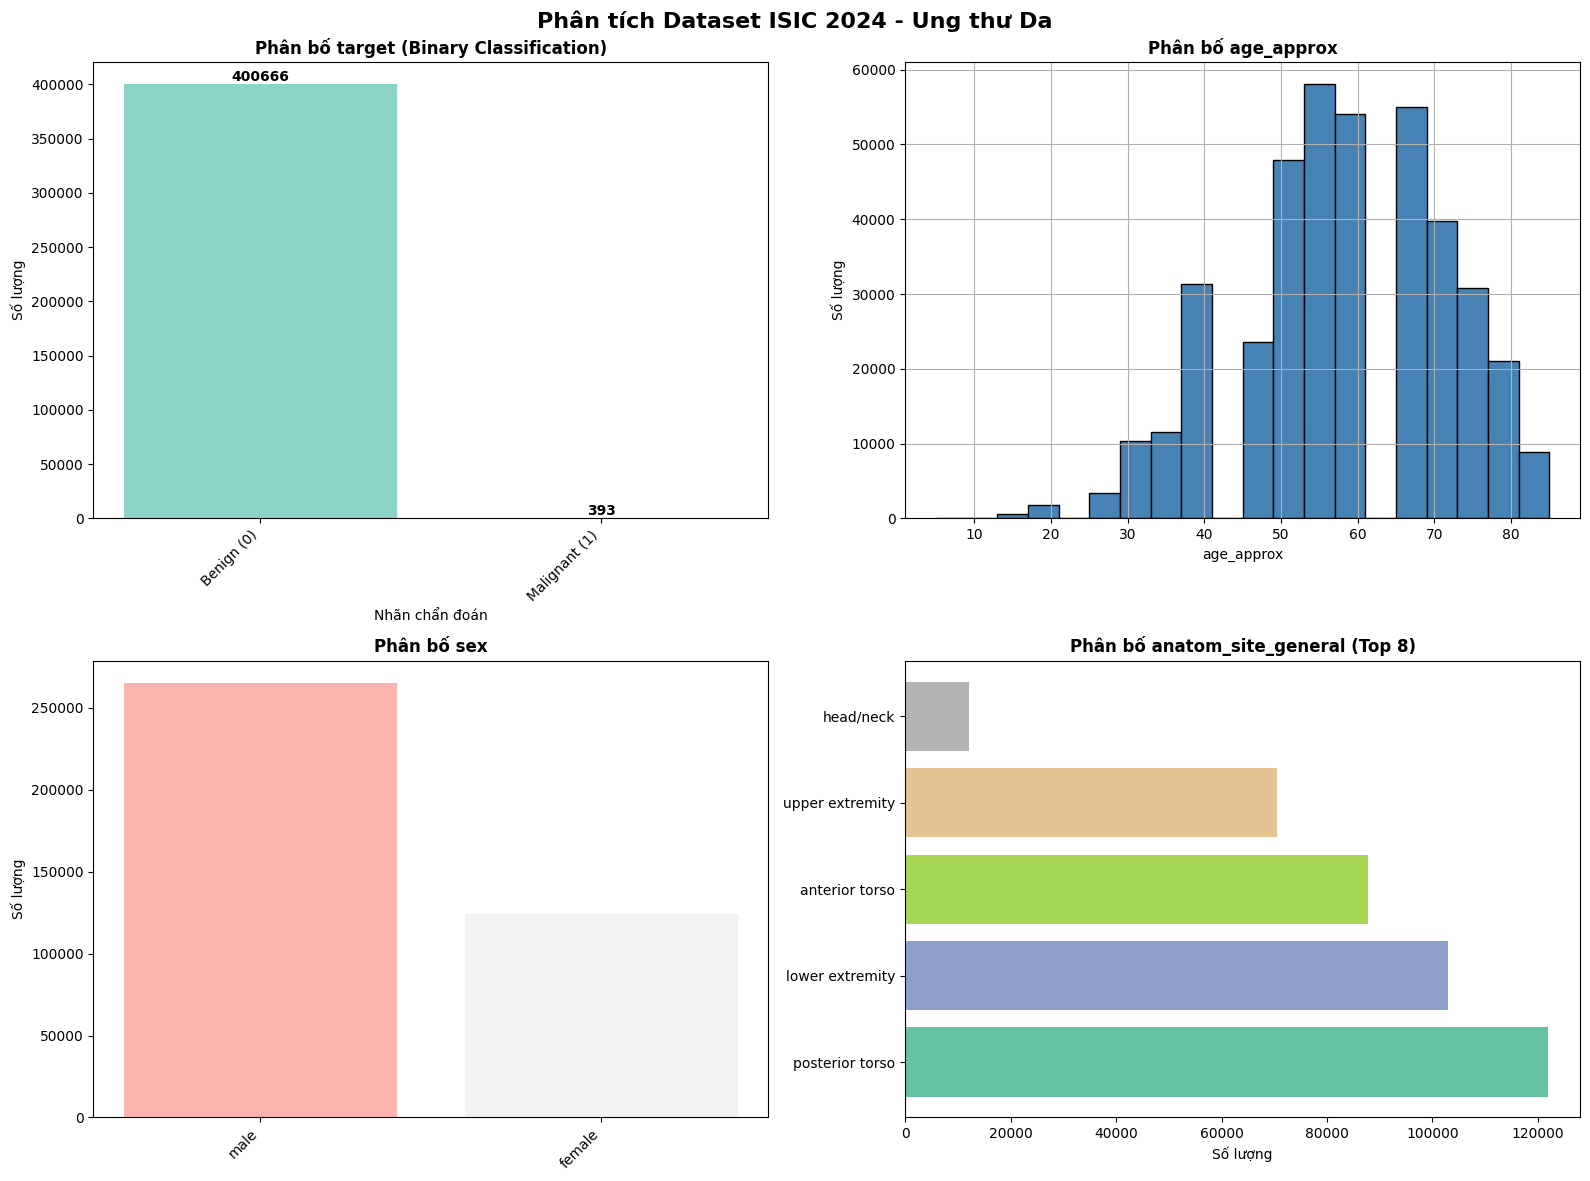

In [15]:
# ===== Visualizations chính =====
# ISIC 2024: cột target là 'target' (0 = benign, 1 = malignant) - binary classification
# Tự động detect cột chẩn đoán
diagnostic_col = None
possible_diagnostic_cols = ['target', 'diagnostic', 'diagnosis', 'class', 'label', 'category']

for col in possible_diagnostic_cols:
    if col.lower() in [c.lower() for c in df.columns]:
        diagnostic_col = [c for c in df.columns if c.lower() == col.lower()][0]
        break

if diagnostic_col is None:
    categorical_cols = df.select_dtypes(include=['object']).columns
    if len(categorical_cols) > 0:
        diagnostic_col = categorical_cols[0]
        for col in categorical_cols:
            if df[col].nunique() < df[diagnostic_col].nunique():
                diagnostic_col = col

print(f"Sử dụng cột '{diagnostic_col}' làm cột chẩn đoán")
print(f"Phân bố nhãn: 0 = Benign (lành tính), 1 = Malignant (ác tính)")

# Tạo figure chính
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Phân tích Dataset ISIC 2024 - Ung thư Da', fontsize=16, fontweight='bold')

# Subplot 1: Phân bố chẩn đoán (target)
if diagnostic_col:
    diagnostic_counts = df[diagnostic_col].value_counts()
    label_names = {0: 'Benign (0)', 1: 'Malignant (1)'}

    ax1 = axes[0, 0]
    bars = ax1.bar(range(len(diagnostic_counts)), diagnostic_counts.values,
                   color=plt.cm.Set3(np.linspace(0, 1, len(diagnostic_counts))))
    ax1.set_title(f'Phân bố {diagnostic_col} (Binary Classification)', fontweight='bold')
    ax1.set_xlabel('Nhãn chẩn đoán')
    ax1.set_ylabel('Số lượng')
    ax1.set_xticks(range(len(diagnostic_counts)))
    ax1.set_xticklabels([label_names.get(int(k), str(k)) for k in diagnostic_counts.index],
                        rotation=45, ha='right')

    for i, bar in enumerate(bars):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold')

# Subplot 2: Phân bố tuổi (age_approx)
age_col = None
possible_age_cols = ['age_approx', 'age', 'tuoi', 'years', 'year']
for col in possible_age_cols:
    if col.lower() in [c.lower() for c in df.columns]:
        age_col = [c for c in df.columns if c.lower() == col.lower()][0]
        break

if age_col:
    ax2 = axes[0, 1]
    df[age_col].dropna().hist(ax=ax2, bins=20, color='steelblue', edgecolor='black')
    ax2.set_title(f'Phân bố {age_col}', fontweight='bold')
    ax2.set_xlabel(age_col)
    ax2.set_ylabel('Số lượng')

# Subplot 3: Phân bố giới tính (sex)
sex_col = None
possible_sex_cols = ['sex', 'gender']
for col in possible_sex_cols:
    if col.lower() in [c.lower() for c in df.columns]:
        sex_col = [c for c in df.columns if c.lower() == col.lower()][0]
        break

if sex_col:
    ax3 = axes[1, 0]
    sex_counts = df[sex_col].value_counts()
    ax3.bar(range(len(sex_counts)), sex_counts.values,
            color=plt.cm.Pastel1(np.linspace(0, 1, len(sex_counts))))
    ax3.set_title(f'Phân bố {sex_col}', fontweight='bold')
    ax3.set_xticks(range(len(sex_counts)))
    ax3.set_xticklabels(sex_counts.index, rotation=45, ha='right')
    ax3.set_ylabel('Số lượng')

# Subplot 4: Phân bố vị trí giải phẫu (anatom_site_general)
site_col = None
possible_site_cols = ['anatom_site_general', 'anatom_site', 'region', 'location']
for col in possible_site_cols:
    if col.lower() in [c.lower() for c in df.columns]:
        site_col = [c for c in df.columns if c.lower() == col.lower()][0]
        break

if site_col:
    ax4 = axes[1, 1]
    site_counts = df[site_col].value_counts().head(8)
    ax4.barh(range(len(site_counts)), site_counts.values,
             color=plt.cm.Set2(np.linspace(0, 1, len(site_counts))))
    ax4.set_title(f'Phân bố {site_col} (Top 8)', fontweight='bold')
    ax4.set_yticks(range(len(site_counts)))
    ax4.set_yticklabels(site_counts.index)
    ax4.set_xlabel('Số lượng')

plt.tight_layout()
plt.show()

=== THỐNG KÊ CHI TIẾT ===

Phân bố target (0=Benign, 1=Malignant):


,Số lượng,Tỷ lệ (%)
target,,
0,400666,99.9
1,393,0.1



Thống kê cho các cột số:


,target,age_approx,clin_size_long_diam_mm,tbp_lv_A,tbp_lv_Aext,tbp_lv_B,tbp_lv_Bext,tbp_lv_C,tbp_lv_Cext,tbp_lv_H,...,tbp_lv_radial_color_std_max,tbp_lv_stdL,tbp_lv_stdLExt,tbp_lv_symm_2axis,tbp_lv_symm_2axis_angle,tbp_lv_x,tbp_lv_y,tbp_lv_z,mel_thick_mm,tbp_lv_dnn_lesion_confidence
count,401059.00,398261.00,401059.00,401059.00,401059.00,401059.00,401059.00,401059.00,401059.00,401059.00,...,401059.00,401059.00,401059.00,401059.00,401059.00,401059.00,401059.00,401059.00,63.00,401059.00
mean,0.00,58.01,3.93,19.97,14.92,28.28,26.91,34.79,30.92,54.65,...,1.02,2.72,2.24,0.31,86.33,-3.09,1039.60,55.82,0.67,97.16
std,0.03,13.60,1.74,4.00,3.53,5.28,4.48,5.71,4.83,5.52,...,0.73,1.74,0.62,0.13,52.56,197.26,409.82,87.97,0.79,9.00
min,0.00,5.00,1.00,-2.49,-9.08,-0.73,9.24,3.05,11.85,-1.57,...,0.00,0.27,0.64,0.05,0.00,-624.87,-1052.13,-291.89,0.20,0.00
25%,0.00,50.00,2.84,17.33,12.47,24.70,23.85,31.00,27.66,51.57,...,0.56,1.46,1.83,0.21,40.00,-147.02,746.52,-8.96,0.30,99.67
50%,0.00,60.00,3.37,19.80,14.71,28.17,26.70,34.82,30.80,55.04,...,0.90,2.19,2.15,0.28,90.00,-5.75,1172.80,67.96,0.40,99.99
75%,0.00,70.00,4.38,22.30,17.14,31.64,29.68,38.43,33.96,58.30,...,1.33,3.47,2.53,0.38,130.00,140.47,1342.13,126.61,0.60,100.00
max,1.00,85.00,28.40,48.19,37.02,54.31,48.37,58.77,54.31,105.88,...,11.49,17.56,25.53,0.98,175.00,614.47,1887.77,319.41,5.00,100.00


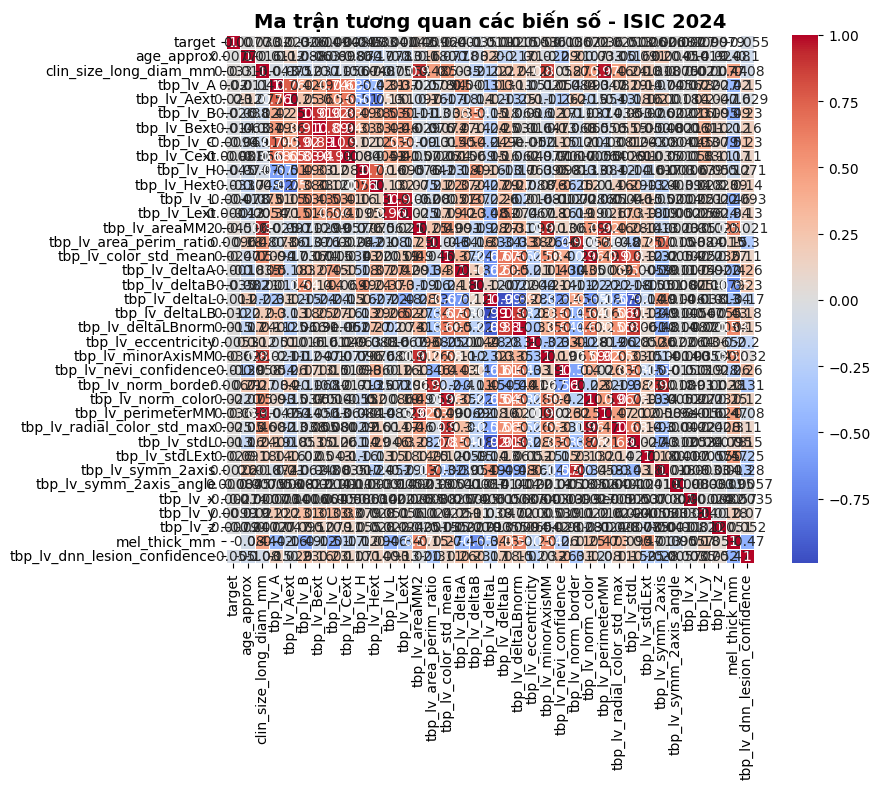

Các cặp biến có tương quan cao (|r| > 0.7):


,Biến 1,Biến 2,Tương quan
0,clin_size_long_diam_mm,tbp_lv_areaMM2,0.903
1,clin_size_long_diam_mm,tbp_lv_minorAxisMM,0.859
2,clin_size_long_diam_mm,tbp_lv_perimeterMM,0.965
3,tbp_lv_A,tbp_lv_Aext,0.760
4,tbp_lv_A,tbp_lv_C,0.736
5,tbp_lv_Aext,tbp_lv_Hext,-0.749
6,tbp_lv_B,tbp_lv_Bext,0.910
7,tbp_lv_B,tbp_lv_C,0.921
8,tbp_lv_B,tbp_lv_Cext,0.827
9,tbp_lv_Bext,tbp_lv_C,0.885


In [16]:
# ===== Thống kê chi tiết =====
print("=== THỐNG KÊ CHI TIẾT ===")
if diagnostic_col:
    print(f"\nPhân bố {diagnostic_col} (0=Benign, 1=Malignant):")
    counts = df[diagnostic_col].value_counts()
    percentages = df[diagnostic_col].value_counts(normalize=True) * 100

    result_df = pd.DataFrame({
        'Số lượng': counts,
        'Tỷ lệ (%)': percentages.round(2)
    })
    display(result_df)

# Thống kê cho các cột số
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
if len(numeric_cols) > 0:
    print(f"\nThống kê cho các cột số:")
    display(df[numeric_cols].describe().round(2))

# Ma trận tương quan (nếu có nhiều cột số)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
if len(numeric_cols) >= 2:
    plt.figure(figsize=(10, 8))
    correlation_matrix = df[numeric_cols].corr()

    sns.heatmap(correlation_matrix,
                annot=True,
                cmap='coolwarm',
                center=0,
                square=True,
                linewidths=0.5)
    plt.title('Ma trận tương quan các biến số - ISIC 2024', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("Các cặp biến có tương quan cao (|r| > 0.7):")
    high_corr_pairs = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            corr_value = correlation_matrix.iloc[i, j]
            if abs(corr_value) > 0.7:
                high_corr_pairs.append({
                    'Biến 1': correlation_matrix.columns[i],
                    'Biến 2': correlation_matrix.columns[j],
                    'Tương quan': round(corr_value, 3)
                })

    if high_corr_pairs:
        display(pd.DataFrame(high_corr_pairs))
    else:
        print("Không có cặp biến nào có tương quan cao!")

=== BIỂU ĐỒ BỔ SUNG ===


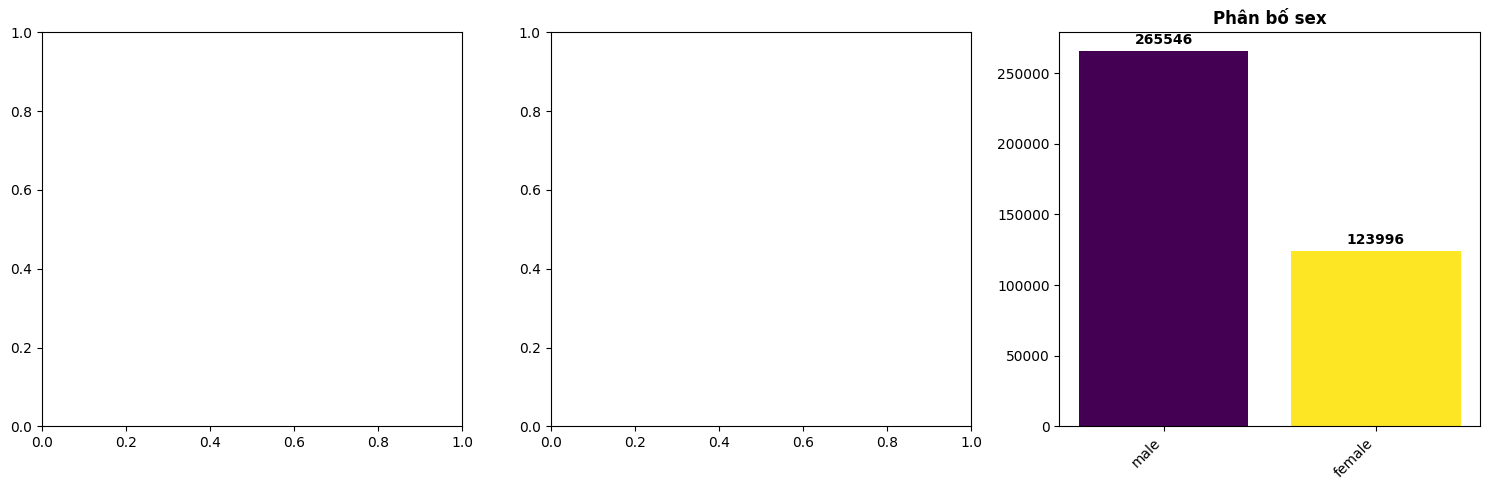

In [17]:
# ===== Biểu đồ bổ sung =====
print("=== BIỂU ĐỒ BỔ SUNG ===")

# Tìm các cột categorical khác
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
if diagnostic_col in categorical_cols:
    categorical_cols.remove(diagnostic_col)

if len(categorical_cols) > 0:
    n_cats = min(3, len(categorical_cols))
    fig, axes = plt.subplots(1, n_cats, figsize=(5*n_cats, 5))
    if n_cats == 1:
        axes = [axes]

    for i, col in enumerate(categorical_cols[:n_cats]):
        if df[col].nunique() <= 15:
            counts = df[col].value_counts().head(10)
            axes[i].bar(range(len(counts)), counts.values,
                       color=plt.cm.viridis(np.linspace(0, 1, len(counts))))
            axes[i].set_title(f'Phân bố {col}', fontweight='bold')
            axes[i].set_xticks(range(len(counts)))
            axes[i].set_xticklabels(counts.index, rotation=45, ha='right')

            for j, v in enumerate(counts.values):
                axes[i].text(j, v + max(counts.values)*0.01, str(v),
                           ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()

In [18]:
# ===== Hàm tiền xử lý dữ liệu =====
def preprocess_csv_data(df):
    """
    Hàm tiền xử lý dữ liệu cho dataset ISIC 2024
    ISIC 2024 có các cột: isic_id, target, age_approx, sex, anatom_site_general,
    clin_size_long_diam_mm, tbp_lv_* (nhiều cột đặc trưng ảnh đã trích xuất), v.v.

    Args:
        df: DataFrame gốc

    Returns:
        df_processed: DataFrame đã được tiền xử lý
        preprocessing_report: Báo cáo quá trình tiền xử lý
    """

    print(" Bắt đầu tiền xử lý dữ liệu ISIC 2024...")
    df_processed = df.copy()
    preprocessing_report = {}

    # 1. Thông tin ban đầu
    initial_shape = df_processed.shape
    preprocessing_report['initial_shape'] = initial_shape
    print(f" Kích thước ban đầu: {initial_shape}")

    # 2. Chuẩn hóa tên cột
    print("\n  Chuẩn hóa tên cột...")
    old_columns = df_processed.columns.tolist()
    df_processed.columns = df_processed.columns.str.strip().str.lower()
    df_processed.columns = df_processed.columns.str.replace(' ', '_')
    df_processed.columns = df_processed.columns.str.replace('[^a-zA-Z0-9_]', '_', regex=True)
    df_processed.columns = df_processed.columns.str.replace('_+', '_', regex=True)
    df_processed.columns = df_processed.columns.str.strip('_')
    new_columns = df_processed.columns.tolist()
    preprocessing_report['column_mapping'] = dict(zip(old_columns, new_columns))
    print(f"   Đã chuẩn hóa {len(old_columns)} tên cột")

    # 3. Xử lý dữ liệu thiếu
    print("\n Xử lý dữ liệu thiếu...")
    missing_before = df_processed.isnull().sum().sum()
    preprocessing_report['missing_before'] = int(missing_before)

    if missing_before > 0:
        print(f"  Tổng dữ liệu thiếu: {missing_before}")
        for col in df_processed.columns:
            missing_count = df_processed[col].isnull().sum()
            missing_percent = (missing_count / len(df_processed)) * 100
            if missing_count > 0:
                print(f"   - {col}: {missing_count} ({missing_percent:.1f}%)")
                # Điền giá trị thiếu
                if df_processed[col].dtype in ['float64', 'int64']:
                    df_processed[col].fillna(df_processed[col].median(), inplace=True)
                else:
                    df_processed[col].fillna(df_processed[col].mode()[0] if len(df_processed[col].mode()) > 0 else 'unknown', inplace=True)
    else:
        print("  Không có dữ liệu thiếu!")

    missing_after = df_processed.isnull().sum().sum()
    preprocessing_report['missing_after'] = int(missing_after)

    # 4. Xử lý outliers trong các cột số
    print("\n Xử lý outliers...")
    numeric_cols = df_processed.select_dtypes(include=['float64', 'int64']).columns
    # Loại bỏ cột target khỏi xử lý outlier
    numeric_cols = [c for c in numeric_cols if c not in ['target']]
    outlier_report = {}

    for col in numeric_cols[:10]:  # Giới hạn 10 cột đầu tiên để tránh quá lâu
        Q1 = df_processed[col].quantile(0.25)
        Q3 = df_processed[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = ((df_processed[col] < lower) | (df_processed[col] > upper)).sum()
        if outliers > 0:
            outlier_percent = (outliers / len(df_processed)) * 100
            outlier_report[col] = {'count': int(outliers), 'percent': float(outlier_percent)}
            # Clip outliers thay vì xóa
            df_processed[col] = df_processed[col].clip(lower, upper)

    preprocessing_report['outliers'] = outlier_report
    preprocessing_report['final_shape'] = df_processed.shape

    print(f" Hoàn thành! Kích thước cuối: {df_processed.shape}")
    return df_processed, preprocessing_report

In [19]:
# ===== Áp dụng tiền xử lý =====
print(" Áp dụng tiền xử lý cho dataset ISIC 2024...")
df_processed, report = preprocess_csv_data(df)

# Hiển thị báo cáo tiền xử lý
print("\n BÁO CÁO TIỀN XỬ LÝ:")
print(f"Kích thước ban đầu: {report['initial_shape']}")
print(f"Kích thước sau xử lý: {report['final_shape']}")
print(f"Dữ liệu thiếu trước: {report['missing_before']}")
print(f"Dữ liệu thiếu sau: {report['missing_after']}")

if report['outliers']:
    print("\nOutliers được xử lý:")
    for col, info in report['outliers'].items():
        print(f"- {col}: {info['count']} outliers ({info['percent']:.1f}%)")

# Cập nhật df
df = df_processed.copy()
print("\n Dataset ISIC 2024 đã được tiền xử lý và sẵn sàng cho phân tích!")

# ─── Upload metadata đã làm sạch lên S3 (preprocessed/) ────────────────────
#import tempfile, os
#with tempfile.NamedTemporaryFile(suffix='.csv', delete=False, mode='w') as tmp:
#    df_processed.to_csv(tmp.name, index=False)
#    upload_to_s3(tmp.name, 'preprocessed/metadata_clean.csv')
#    os.unlink(tmp.name)
#print(' Đã lưu metadata sạch lên s3://{S3_OUTPUT_BUCKET}/preprocessed/metadata_clean.csv')


 Áp dụng tiền xử lý cho dataset ISIC 2024...
 Bắt đầu tiền xử lý dữ liệu ISIC 2024...
 Kích thước ban đầu: (401059, 55)

  Chuẩn hóa tên cột...
   Đã chuẩn hóa 55 tên cột

 Xử lý dữ liệu thiếu...
  Tổng dữ liệu thiếu: 2802625
   - age_approx: 2798 (0.7%)
   - sex: 11517 (2.9%)
   - anatom_site_general: 5756 (1.4%)


/tmp/ipykernel_889350/2728768958.py:51: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_processed[col].fillna(df_processed[col].median(), inplace=True)
/tmp/ipykernel_889350/2728768958.py:53: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(val

   - lesion_id: 379001 (94.5%)
   - iddx_2: 399991 (99.7%)
   - iddx_3: 399994 (99.7%)
   - iddx_4: 400508 (99.9%)
   - iddx_5: 401058 (100.0%)
   - mel_mitotic_index: 401006 (100.0%)
   - mel_thick_mm: 400996 (100.0%)


/tmp/ipykernel_889350/2728768958.py:51: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_processed[col].fillna(df_processed[col].median(), inplace=True)



 Xử lý outliers...
 Hoàn thành! Kích thước cuối: (401059, 55)

 BÁO CÁO TIỀN XỬ LÝ:
Kích thước ban đầu: (401059, 55)
Kích thước sau xử lý: (401059, 55)
Dữ liệu thiếu trước: 2802625
Dữ liệu thiếu sau: 0

Outliers được xử lý:
- age_approx: 645 outliers (0.2%)
- clin_size_long_diam_mm: 27365 outliers (6.8%)
- tbp_lv_a: 8057 outliers (2.0%)
- tbp_lv_aext: 4723 outliers (1.2%)
- tbp_lv_b: 4474 outliers (1.1%)
- tbp_lv_bext: 5260 outliers (1.3%)
- tbp_lv_c: 4766 outliers (1.2%)
- tbp_lv_cext: 4829 outliers (1.2%)
- tbp_lv_h: 9822 outliers (2.4%)
- tbp_lv_hext: 2936 outliers (0.7%)

 Dataset ISIC 2024 đã được tiền xử lý và sẵn sàng cho phân tích!


In [20]:
# ===== Khám phá dữ liệu sau tiền xử lý =====
print("=== THÔNG TIN TỔNG QUAN VỀ DATASET ISIC 2024 SAU TIỀN XỬ LÝ ===")
print(f"Số dòng: {df.shape[0]}")
print(f"Số cột: {df.shape[1]}")
print(f"\nTên các cột:")
for i, col in enumerate(df.columns):
    print(f"{i+1}. {col}")

print(f"\nKiểu dữ liệu:")
print(df.dtypes)

print(f"\nMẫu dữ liệu đầu tiên:")
display(df.head())

print(f"\nThống kê mô tả:")
display(df.describe())

=== THÔNG TIN TỔNG QUAN VỀ DATASET ISIC 2024 SAU TIỀN XỬ LÝ ===
Số dòng: 401059
Số cột: 55

Tên các cột:
1. isic_id
2. target
3. patient_id
4. age_approx
5. sex
6. anatom_site_general
7. clin_size_long_diam_mm
8. image_type
9. tbp_tile_type
10. tbp_lv_a
11. tbp_lv_aext
12. tbp_lv_b
13. tbp_lv_bext
14. tbp_lv_c
15. tbp_lv_cext
16. tbp_lv_h
17. tbp_lv_hext
18. tbp_lv_l
19. tbp_lv_lext
20. tbp_lv_areamm2
21. tbp_lv_area_perim_ratio
22. tbp_lv_color_std_mean
23. tbp_lv_deltaa
24. tbp_lv_deltab
25. tbp_lv_deltal
26. tbp_lv_deltalb
27. tbp_lv_deltalbnorm
28. tbp_lv_eccentricity
29. tbp_lv_location
30. tbp_lv_location_simple
31. tbp_lv_minoraxismm
32. tbp_lv_nevi_confidence
33. tbp_lv_norm_border
34. tbp_lv_norm_color
35. tbp_lv_perimetermm
36. tbp_lv_radial_color_std_max
37. tbp_lv_stdl
38. tbp_lv_stdlext
39. tbp_lv_symm_2axis
40. tbp_lv_symm_2axis_angle
41. tbp_lv_x
42. tbp_lv_y
43. tbp_lv_z
44. attribution
45. copyright_license
46. lesion_id
47. iddx_full
48. iddx_1
49. iddx_2
50. iddx_3
5

,isic_id,target,patient_id,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,image_type,tbp_tile_type,tbp_lv_a,...,lesion_id,iddx_full,iddx_1,iddx_2,iddx_3,iddx_4,iddx_5,mel_mitotic_index,mel_thick_mm,tbp_lv_dnn_lesion_confidence
0,ISIC_0015670,0,IP_1235828,60.0,male,lower extremity,3.04,TBP tile: close-up,3D: white,20.244422,...,IL_0001200,Benign,Benign,Benign melanocytic proliferations,Nevus,"Nevus, Atypical, Dysplastic, or Clark","Blue nevus, Cellular",0/mm^2,0.4,97.517282
1,ISIC_0015845,0,IP_8170065,60.0,male,head/neck,1.10,TBP tile: close-up,3D: white,29.765339,...,IL_6727506,Benign,Benign,Benign melanocytic proliferations,Nevus,"Nevus, Atypical, Dysplastic, or Clark","Blue nevus, Cellular",0/mm^2,0.4,3.141455
2,ISIC_0015864,0,IP_6724798,60.0,male,posterior torso,3.40,TBP tile: close-up,3D: XP,22.575830,...,IL_0001200,Benign,Benign,Benign melanocytic proliferations,Nevus,"Nevus, Atypical, Dysplastic, or Clark","Blue nevus, Cellular",0/mm^2,0.4,99.804040
3,ISIC_0015902,0,IP_4111386,65.0,male,anterior torso,3.22,TBP tile: close-up,3D: XP,14.242329,...,IL_0001200,Benign,Benign,Benign melanocytic proliferations,Nevus,"Nevus, Atypical, Dysplastic, or Clark","Blue nevus, Cellular",0/mm^2,0.4,99.989998
4,ISIC_0024200,0,IP_8313778,55.0,male,anterior torso,2.73,TBP tile: close-up,3D: white,24.725520,...,IL_0001200,Benign,Benign,Benign melanocytic proliferations,Nevus,"Nevus, Atypical, Dysplastic, or Clark","Blue nevus, Cellular",0/mm^2,0.4,70.442510



Thống kê mô tả:


,target,age_approx,clin_size_long_diam_mm,tbp_lv_a,tbp_lv_aext,tbp_lv_b,tbp_lv_bext,tbp_lv_c,tbp_lv_cext,tbp_lv_h,...,tbp_lv_radial_color_std_max,tbp_lv_stdl,tbp_lv_stdlext,tbp_lv_symm_2axis,tbp_lv_symm_2axis_angle,tbp_lv_x,tbp_lv_y,tbp_lv_z,mel_thick_mm,tbp_lv_dnn_lesion_confidence
count,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,...,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,4.010590e+05
mean,0.000980,58.034915,3.783619,19.921420,14.898163,28.269042,26.893119,34.776755,30.903997,54.740138,...,1.016459,2.715190,2.238605,0.306823,86.332073,-3.091862,1039.598221,55.823389,0.400043,9.716220e+01
std,0.031288,13.525500,1.236255,3.817381,3.459719,5.219359,4.415947,5.642221,4.765507,5.236505,...,0.734631,1.738165,0.623884,0.125038,52.559511,197.257995,409.819653,87.968245,0.010426,8.995782e+00
min,0.000000,20.000000,1.000000,9.870109,5.468588,14.304785,15.100444,19.862425,18.199912,41.468405,...,0.000000,0.268160,0.636247,0.052034,0.000000,-624.870728,-1052.134000,-291.890442,0.200000,1.261082e-16
25%,0.000000,50.000000,2.840000,17.330821,12.469740,24.704372,23.848125,31.003148,27.658285,51.566273,...,0.563891,1.456570,1.834745,0.211429,40.000000,-147.022125,746.519673,-8.962647,0.400000,9.966882e+01
50%,0.000000,60.000000,3.370000,19.801910,14.713930,28.171570,26.701704,34.822580,30.804893,55.035632,...,0.902281,2.186693,2.149758,0.282297,90.000000,-5.747253,1172.803000,67.957947,0.400000,9.999459e+01
75%,0.000000,70.000000,4.380000,22.304628,17.137175,31.637429,29.679913,38.430298,33.963868,58.298184,...,1.334523,3.474565,2.531443,0.382022,130.000000,140.474835,1342.131540,126.611567,0.400000,9.999996e+01
max,1.000000,85.000000,6.690000,29.765339,24.138327,42.037015,38.427594,49.571021,43.422241,68.396051,...,11.491140,17.563650,25.534791,0.977055,175.000000,614.471700,1887.766846,319.407000,5.000000,1.000000e+02


In [21]:
# ===== Kiểm tra chất lượng dữ liệu sau xử lý =====
print("=== KIỂM TRA DỮ LIỆU THIẾU ===")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])

if missing_data.sum() > 0:
    missing_percent = (df.isnull().sum() / len(df)) * 100
    missing_df = pd.DataFrame({
        'Cột': df.columns,
        'Số dòng thiếu': missing_data,
        'Phần trăm': missing_percent
    })
    display(missing_df[missing_df['Số dòng thiếu'] > 0])
else:
    print("Không có dữ liệu thiếu!")

=== KIỂM TRA DỮ LIỆU THIẾU ===
Series([], dtype: int64)
Không có dữ liệu thiếu!


Sử dụng cột 'target' làm cột chẩn đoán (0=Benign, 1=Malignant)


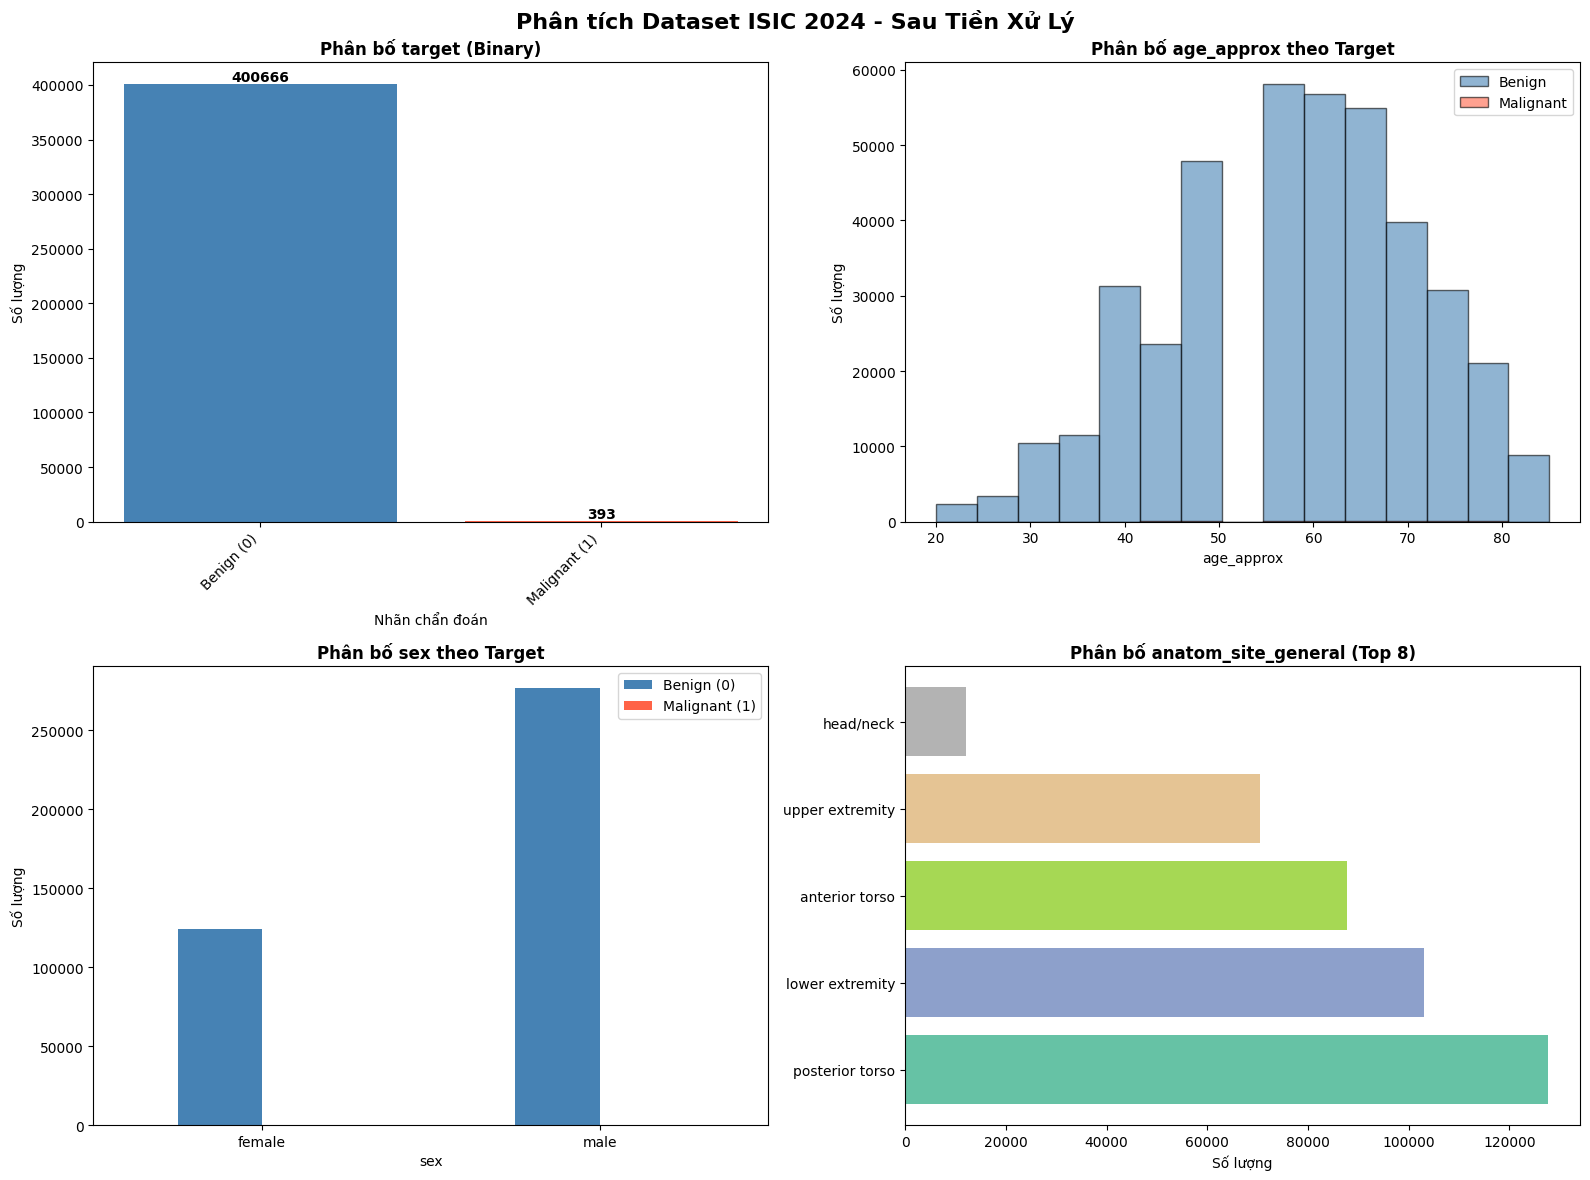

In [22]:
# ===== Visualizations chính (với dữ liệu đã xử lý) =====
# ISIC 2024: cột target là 'target' (binary: 0 hoặc 1)
diagnostic_col = None
possible_diagnostic_cols = ['target', 'diagnostic', 'diagnosis', 'class', 'label', 'category']

for col in possible_diagnostic_cols:
    if col.lower() in [c.lower() for c in df.columns]:
        diagnostic_col = [c for c in df.columns if c.lower() == col.lower()][0]
        break

if diagnostic_col is None:
    categorical_cols = df.select_dtypes(include=['object']).columns
    if len(categorical_cols) > 0:
        diagnostic_col = categorical_cols[0]
        for col in categorical_cols:
            if df[col].nunique() < df[diagnostic_col].nunique():
                diagnostic_col = col

print(f"Sử dụng cột '{diagnostic_col}' làm cột chẩn đoán (0=Benign, 1=Malignant)")

# Tạo figure chính
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Phân tích Dataset ISIC 2024 - Sau Tiền Xử Lý', fontsize=16, fontweight='bold')

# Subplot 1: Phân bố target
if diagnostic_col:
    diagnostic_counts = df[diagnostic_col].value_counts()
    label_names = {0: 'Benign (0)', 1: 'Malignant (1)'}

    ax1 = axes[0, 0]
    bars = ax1.bar(range(len(diagnostic_counts)), diagnostic_counts.values,
                   color=['steelblue', 'tomato'][:len(diagnostic_counts)])
    ax1.set_title(f'Phân bố {diagnostic_col} (Binary)', fontweight='bold')
    ax1.set_xlabel('Nhãn chẩn đoán')
    ax1.set_ylabel('Số lượng')
    ax1.set_xticks(range(len(diagnostic_counts)))
    ax1.set_xticklabels([label_names.get(int(k), str(k)) for k in diagnostic_counts.index],
                        rotation=45, ha='right')
    for i, bar in enumerate(bars):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold')

# Subplot 2: Phân bố tuổi
age_col = None
possible_age_cols = ['age_approx', 'age', 'tuoi', 'years', 'year']
for col in possible_age_cols:
    if col.lower() in [c.lower() for c in df.columns]:
        age_col = [c for c in df.columns if c.lower() == col.lower()][0]
        break

if age_col:
    ax2 = axes[0, 1]
    for label_val, color, label_name in [(0, 'steelblue', 'Benign'), (1, 'tomato', 'Malignant')]:
        subset = df[df[diagnostic_col] == label_val][age_col].dropna()
        ax2.hist(subset, bins=15, alpha=0.6, color=color, label=label_name, edgecolor='black')
    ax2.set_title(f'Phân bố {age_col} theo Target', fontweight='bold')
    ax2.set_xlabel(age_col)
    ax2.set_ylabel('Số lượng')
    ax2.legend()

# Subplot 3: Phân bố giới tính
sex_col = None
for col in ['sex', 'gender']:
    if col in df.columns:
        sex_col = col
        break

if sex_col and diagnostic_col:
    ax3 = axes[1, 0]
    sex_target = df.groupby([sex_col, diagnostic_col]).size().unstack(fill_value=0)
    sex_target.plot(kind='bar', ax=ax3, color=['steelblue', 'tomato'])
    ax3.set_title(f'Phân bố {sex_col} theo Target', fontweight='bold')
    ax3.set_xlabel(sex_col)
    ax3.set_ylabel('Số lượng')
    ax3.legend(['Benign (0)', 'Malignant (1)'])
    ax3.tick_params(axis='x', rotation=0)

# Subplot 4: Phân bố vị trí giải phẫu
site_col = None
for col in ['anatom_site_general', 'anatom_site', 'region']:
    if col in df.columns:
        site_col = col
        break

if site_col:
    ax4 = axes[1, 1]
    site_counts = df[site_col].value_counts().head(8)
    ax4.barh(range(len(site_counts)), site_counts.values,
             color=plt.cm.Set2(np.linspace(0, 1, len(site_counts))))
    ax4.set_title(f'Phân bố {site_col} (Top 8)', fontweight='bold')
    ax4.set_yticks(range(len(site_counts)))
    ax4.set_yticklabels(site_counts.index)
    ax4.set_xlabel('Số lượng')

plt.tight_layout()
plt.show()

In [23]:
# ===== Trích xuất ảnh từ file HDF5 (train-image.hdf5) của ISIC 2024 =====
# ISIC 2024 lưu ảnh trong file HDF5 thay vì thư mục riêng lẻ
# Hàm này trích xuất ảnh từ HDF5 và lưu ra thư mục

import os
import h5py
from pathlib import Path

def extract_images_from_hdf5(hdf5_path, output_folder, max_images=None):
    """
    Trích xuất ảnh từ file HDF5 của ISIC 2024 ra thư mục

    Args:
        hdf5_path: Đường dẫn đến file train-image.hdf5
        output_folder: Thư mục đầu ra để lưu ảnh
        max_images: Số lượng ảnh tối đa cần trích xuất (None = tất cả)
    """
    os.makedirs(output_folder, exist_ok=True)
    print(f"Bắt đầu trích xuất ảnh từ: {hdf5_path}")
    print(f"Thư mục đầu ra: {output_folder}")

    extracted = 0
    errors = 0

    with h5py.File(hdf5_path, 'r') as hf:
        # Lấy danh sách tất cả isic_id
        keys = list(hf.keys())
        total = len(keys)
        print(f"Tổng số ảnh trong HDF5: {total}")

        if max_images:
            keys = keys[:max_images]
            print(f"Sẽ trích xuất {len(keys)} ảnh đầu tiên")

        for i, isic_id in enumerate(keys):
            try:
                # Đọc dữ liệu ảnh (bytes)
                img_bytes = hf[isic_id][()]

                # Lưu ra file .jpg
                output_path = os.path.join(output_folder, f"{isic_id}.jpg")
                with open(output_path, 'wb') as f:
                    f.write(img_bytes)

                extracted += 1

                if (i + 1) % 1000 == 0:
                    print(f"  Đã trích xuất: {i+1}/{len(keys)}")

            except Exception as e:
                errors += 1
                if errors <= 5:
                    print(f"  Lỗi với {isic_id}: {e}")

    print(f"\n Hoàn thành! Đã trích xuất: {extracted} ảnh, Lỗi: {errors}")
    return output_folder

print(" Hàm trích xuất ảnh HDF5 đã sẵn sàng!")
print("\n HƯỚNG DẪN SỬ DỤNG:")
print("1. Trích xuất tất cả ảnh: extract_images_from_hdf5('/content/isic2024/train-image.hdf5', '/content/all_images')")


 Hàm trích xuất ảnh HDF5 đã sẵn sàng!

 HƯỚNG DẪN SỬ DỤNG:
1. Trích xuất tất cả ảnh: extract_images_from_hdf5('/content/isic2024/train-image.hdf5', '/content/all_images')


In [24]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  Trích xuất TOÀN BỘ ảnh (200000 Benign + 393 Malignant)                ║
# ╚══════════════════════════════════════════════════════════════════════════╝

import os, h5py
import numpy as np
import pandas as pd

hdf5_path     = LOCAL_HDF5
output_folder = 'all_images'
csv_path      = LOCAL_METADATA
os.makedirs(output_folder, exist_ok=True)

# 1. Đọc metadata để biết nhãn từng isic_id
df_meta = pd.read_csv(csv_path)
print(f"Tổng dataset CSV: {len(df_meta)} mẫu")
print(f"  Benign    : {(df_meta['target']==0).sum()}")
print(f"  Malignant : {(df_meta['target']==1).sum()}")

# 2. Tách id theo nhãn
mal_ids = df_meta[df_meta['target'] == 1]['isic_id'].tolist()
ben_ids = df_meta[df_meta['target'] == 0]['isic_id'].tolist()

# 3. Lấy TẤT CẢ Malignant + sample Benign
#    n_benign có thể tăng nếu RAM/thời gian cho phép (tối đa ~len(ben_ids))
n_malignant = len(mal_ids)
n_benign    = min(10000, len(ben_ids))

np.random.seed(42)
selected_ben = np.random.choice(ben_ids, size=n_benign, replace=False).tolist()
selected_ids = set(mal_ids + selected_ben)

print(f"\nSẽ trích xuất:")
print(f"  Malignant : {n_malignant} (100% — không bỏ sót)")
print(f"  Benign    : {n_benign} (sample ngẫu nhiên)")
print(f"  Tổng      : {len(selected_ids)}")
print(f"  Tỷ lệ Mal : {n_malignant/len(selected_ids)*100:.1f}%")

# 4. Duyệt HDF5 — chỉ ghi ảnh trong selected_ids
extracted, errors = 0, 0
with h5py.File(hdf5_path, 'r') as hf:
    all_keys = list(hf.keys())
    print(f"\nTổng ảnh trong HDF5: {len(all_keys)}")
    print("Bắt đầu trích xuất...")

    for isic_id in all_keys:
        if isic_id not in selected_ids:
            continue
        try:
            img_bytes   = hf[isic_id][()]
            output_path = os.path.join(output_folder, f"{isic_id}.jpg")
            with open(output_path, 'wb') as fp:
                fp.write(img_bytes)
            extracted += 1
            if extracted % 500 == 0:
                print(f"  Đã trích xuất: {extracted}/{len(selected_ids)}")
        except Exception as e:
            errors += 1
            if errors <= 3:
                print(f"  Lỗi {isic_id}: {e}")

image_dir = output_folder
print(f"\n Hoàn thành! Trích xuất: {extracted} ảnh | Lỗi: {errors}")

# 5. Kiểm tra phân phối thực tế sau trích xuất
available_ids_check = set(os.path.splitext(f)[0] for f in os.listdir(image_dir))
df_check = df_meta[df_meta['isic_id'].isin(available_ids_check)]
print(f"\nPhân phối sau trích xuất:")
print(f"  Benign    : {(df_check['target']==0).sum()}")
print(f"  Malignant : {(df_check['target']==1).sum()}")
print(f"  Tỷ lệ Mal : {(df_check['target']==1).mean()*100:.1f}%  (kỳ vọng ~{n_malignant/len(selected_ids)*100:.0f}%)")
print(f"\nThư mục ảnh: {image_dir}")




/tmp/ipykernel_889350/1112699230.py:15: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df_meta = pd.read_csv(csv_path)


Tổng dataset CSV: 401059 mẫu
  Benign    : 400666
  Malignant : 393

Sẽ trích xuất:
  Malignant : 393 (100% — không bỏ sót)
  Benign    : 10000 (sample ngẫu nhiên)
  Tổng      : 10393
  Tỷ lệ Mal : 3.8%

Tổng ảnh trong HDF5: 401059
Bắt đầu trích xuất...
  Đã trích xuất: 500/10393
  Đã trích xuất: 1000/10393
  Đã trích xuất: 1500/10393
  Đã trích xuất: 2000/10393
  Đã trích xuất: 2500/10393
  Đã trích xuất: 3000/10393
  Đã trích xuất: 3500/10393
  Đã trích xuất: 4000/10393
  Đã trích xuất: 4500/10393
  Đã trích xuất: 5000/10393
  Đã trích xuất: 5500/10393
  Đã trích xuất: 6000/10393
  Đã trích xuất: 6500/10393
  Đã trích xuất: 7000/10393
  Đã trích xuất: 7500/10393
  Đã trích xuất: 8000/10393
  Đã trích xuất: 8500/10393
  Đã trích xuất: 9000/10393
  Đã trích xuất: 9500/10393
  Đã trích xuất: 10000/10393

 Hoàn thành! Trích xuất: 10393 ảnh | Lỗi: 0

Phân phối sau trích xuất:
  Benign    : 10000
  Malignant : 393
  Tỷ lệ Mal : 3.8%  (kỳ vọng ~4%)

Thư mục ảnh: all_images


In [25]:
# Kiểm tra thư mục ảnh
import os
image_files = [f for f in os.listdir(image_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
print(f"Tổng số ảnh trong thư mục: {len(image_files)}")

Tổng số ảnh trong thư mục: 10393


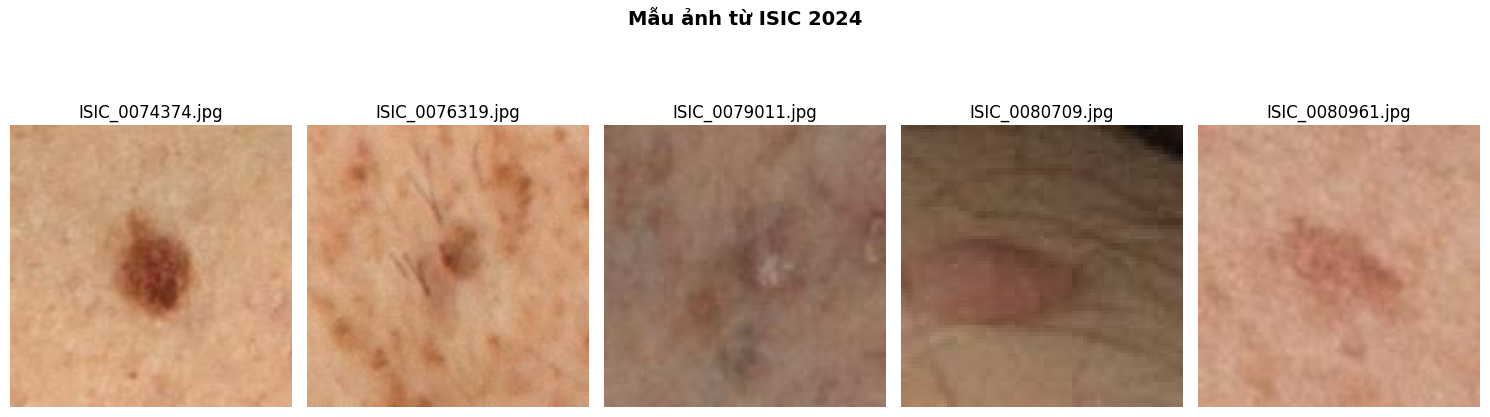

In [26]:
# Xem xét các hình ảnh của dataset ISIC 2024
import os
import matplotlib.pyplot as plt
from PIL import Image

image_dir = 'all_images'  # đã tải từ S3 ở bước trước

# Lấy danh sách các file ảnh
image_files = [f for f in os.listdir(image_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'))]
image_files.sort()

# Hiển thị 5 ảnh đầu tiên
def show_images_from_dir(image_dir, image_files, num=5):
    plt.figure(figsize=(15, 5))
    for i in range(min(num, len(image_files))):
        image_path = os.path.join(image_dir, image_files[i])
        img = Image.open(image_path)
        plt.subplot(1, num, i+1)
        plt.imshow(img)
        plt.title(f"{image_files[i][:20]}")
        plt.axis('off')
    plt.suptitle('Mẫu ảnh từ ISIC 2024', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_images_from_dir(image_dir, image_files, num=5)

In [27]:
# ===== Hàm tải và xử lý hình ảnh =====
# CẢI TIẾN: Augmentation mạnh hơn cho Malignant class

import os
import numpy as np
import cv2
from PIL import Image, ImageEnhance
from sklearn.preprocessing import LabelEncoder

def load_image(image_path, target_size=(224, 224), color_mode='rgb'):
    """Tải và resize hình ảnh"""
    try:
        img = Image.open(image_path)
        if color_mode.lower() == 'rgb':
            img = img.convert('RGB')
        elif color_mode.lower() == 'grayscale':
            img = img.convert('L')
        elif color_mode.lower() == 'rgba':
            img = img.convert('RGBA')
        img = img.resize(target_size, Image.Resampling.LANCZOS)
        img_array = np.array(img)
        if img_array.dtype == np.uint8:
            img_array = img_array.astype(np.float32) / 255.0
        return img_array
    except Exception as e:
        print(f"Lỗi khi tải ảnh {image_path}: {e}")
        return None


def preprocess_image(img_array, apply_clahe=True, apply_gaussian=True, enhance_contrast=1.2):
    """Tiền xử lý hình ảnh"""
    if img_array is None:
        return None
    try:
        img_uint8 = (img_array * 255).astype(np.uint8)
        if apply_clahe and len(img_uint8.shape) == 3:
            lab = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2LAB)
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
            lab[:, :, 0] = clahe.apply(lab[:, :, 0])
            img_uint8 = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
        if apply_gaussian:
            img_uint8 = cv2.GaussianBlur(img_uint8, (3, 3), 0)
        if enhance_contrast != 1.0:
            img_pil = Image.fromarray(img_uint8)
            enhancer = ImageEnhance.Contrast(img_pil)
            img_pil = enhancer.enhance(enhance_contrast)
            img_uint8 = np.array(img_pil)
        return img_uint8.astype(np.float32) / 255.0
    except Exception as e:
        print(f"Lỗi tiền xử lý: {e}")
        return img_array


def augment_image(img_array, rotation_range=15, brightness_range=(0.8, 1.2),
                  zoom_range=0.1, strong=False):
    """
    CẢI TIẾN: Augmentation mạnh hơn cho Malignant class.

    Args:
        strong: True = augmentation mạnh (dùng cho Malignant oversampling)
                - Rotation lớn hơn (±30°)
                - Flip ngang + dọc
                - Saturation, Hue jitter
                - Elastic distortion nhẹ
                - Random crop + resize
    """
    if img_array is None:
        return None

    img_uint8 = (img_array * 255).astype(np.uint8)
    h, w = img_uint8.shape[:2]

    if strong:
        # ── Rotation mạnh hơn ──────────────────────────────────────
        angle = np.random.uniform(-30, 30)
    else:
        angle = np.random.uniform(-rotation_range, rotation_range)

    M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
    img_uint8 = cv2.warpAffine(img_uint8, M, (w, h), borderMode=cv2.BORDER_REFLECT)

    # ── Flip ─────────────────────────────────────────────────────
    if strong:
        # Flip ngang và dọc ngẫu nhiên
        if np.random.rand() > 0.5:
            img_uint8 = cv2.flip(img_uint8, 1)   # horizontal
        if np.random.rand() > 0.5:
            img_uint8 = cv2.flip(img_uint8, 0)   # vertical

    # ── Brightness ───────────────────────────────────────────────
    if strong:
        factor = np.random.uniform(0.6, 1.4)
    else:
        factor = np.random.uniform(*brightness_range)

    img_pil = Image.fromarray(img_uint8)
    img_pil = ImageEnhance.Brightness(img_pil).enhance(factor)

    if strong:
        # ── Saturation jitter ─────────────────────────────────────
        sat_factor = np.random.uniform(0.7, 1.3)
        img_pil = ImageEnhance.Color(img_pil).enhance(sat_factor)

        # ── Contrast jitter ───────────────────────────────────────
        con_factor = np.random.uniform(0.8, 1.2)
        img_pil = ImageEnhance.Contrast(img_pil).enhance(con_factor)

        # ── Random crop + resize ──────────────────────────────────
        img_tmp = np.array(img_pil)
        crop_pct = np.random.uniform(0.85, 1.0)
        crop_h, crop_w = int(h * crop_pct), int(w * crop_pct)
        top  = np.random.randint(0, h - crop_h + 1)
        left = np.random.randint(0, w - crop_w + 1)
        img_tmp = img_tmp[top:top+crop_h, left:left+crop_w]
        img_tmp = cv2.resize(img_tmp, (w, h))
        return img_tmp.astype(np.float32) / 255.0

    img_uint8 = np.array(img_pil)
    return img_uint8.astype(np.float32) / 255.0


# ── OVERSAMPLING MALIGNANT ────────────────────────────────────────────────────
def oversample_malignant(X_img, X_tab, y, target_ratio=0.2, strong_aug=True):
    """
    CẢI TIẾN: Oversampling class Malignant bằng augmentation mạnh.
    Thay thế SMOTE (không phù hợp với ảnh) bằng cách augment ảnh Malignant.

    Args:
        target_ratio: Tỷ lệ Malignant mong muốn sau oversampling (mặc định 20%)
        strong_aug   : Dùng augmentation mạnh cho các mẫu được tạo thêm

    Returns:
        X_img_os, X_tab_os, y_os: Dữ liệu sau oversampling
    """
    mal_idx = np.where(y == 1)[0]
    ben_idx = np.where(y == 0)[0]

    n_mal = len(mal_idx)
    n_ben = len(ben_idx)
    current_ratio = n_mal / (n_mal + n_ben)

    print(f"Trước oversampling: {n_ben} Benign | {n_mal} Malignant ({current_ratio*100:.1f}%)")

    # Số mẫu Malignant cần thêm
    n_target_mal = int(target_ratio * n_ben / (1 - target_ratio))
    n_to_add = max(0, n_target_mal - n_mal)

    if n_to_add == 0:
        print("Không cần oversample.")
        return X_img, X_tab, y

    print(f"Sẽ tạo thêm {n_to_add} mẫu Malignant...")

    new_imgs, new_tabs = [], []
    for i in range(n_to_add):
        src_idx = mal_idx[i % n_mal]
        aug_img = augment_image(X_img[src_idx], strong=strong_aug)
        new_imgs.append(aug_img)
        new_tabs.append(X_tab[src_idx])

    new_imgs = np.array(new_imgs, dtype=np.float32)
    new_tabs = np.array(new_tabs, dtype=np.float32)
    new_y    = np.ones(n_to_add, dtype=np.int32)

    X_img_os = np.concatenate([X_img, new_imgs], axis=0)
    X_tab_os = np.concatenate([X_tab, new_tabs], axis=0)
    y_os     = np.concatenate([y, new_y], axis=0)

    # Shuffle
    perm = np.random.permutation(len(y_os))
    X_img_os, X_tab_os, y_os = X_img_os[perm], X_tab_os[perm], y_os[perm]

    n_mal_new = np.sum(y_os == 1)
    n_ben_new = np.sum(y_os == 0)
    print(f"Sau oversampling : {n_ben_new} Benign | {n_mal_new} Malignant ({n_mal_new/(n_mal_new+n_ben_new)*100:.1f}%)")

    return X_img_os, X_tab_os, y_os


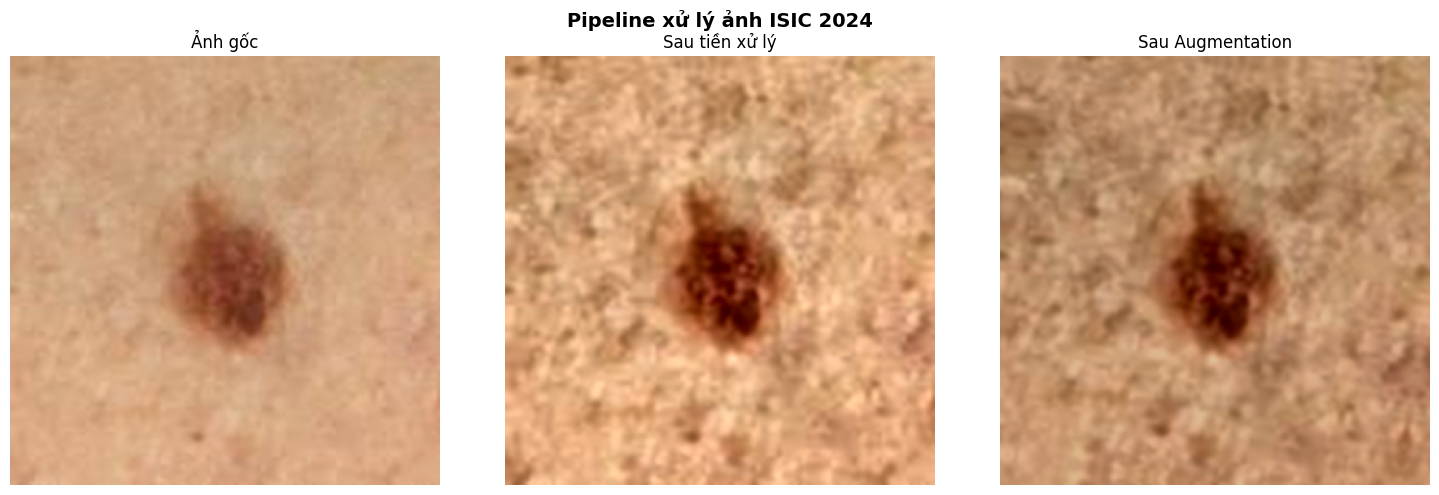

In [28]:
import matplotlib.pyplot as plt

def show_image_processing_pipeline(image_path):
    """
    Hiển thị hình ảnh gốc, sau tiền xử lý, và sau augmentation

    Args:
        image_path: đường dẫn hình ảnh cần xử lý
    """
    img_original = load_image(image_path, target_size=(224, 224), color_mode='rgb')
    if img_original is None:
        print("Không thể tải ảnh.")
        return

    img_preprocessed = preprocess_image(img_original, apply_clahe=True, apply_gaussian=True, enhance_contrast=1.2)
    img_augmented = augment_image(img_preprocessed, rotation_range=15, brightness_range=(0.8, 1.2), zoom_range=0.1)

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(img_original)
    axs[0].set_title("Ảnh gốc")
    axs[0].axis('off')

    axs[1].imshow(img_preprocessed)
    axs[1].set_title("Sau tiền xử lý")
    axs[1].axis('off')

    axs[2].imshow(img_augmented)
    axs[2].set_title("Sau Augmentation")
    axs[2].axis('off')

    plt.suptitle('Pipeline xử lý ảnh ISIC 2024', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Ví dụ sử dụng: lấy ảnh đầu tiên trong thư mục
if image_files:
    sample_image_path = os.path.join(image_dir, image_files[0])
    show_image_processing_pipeline(sample_image_path)

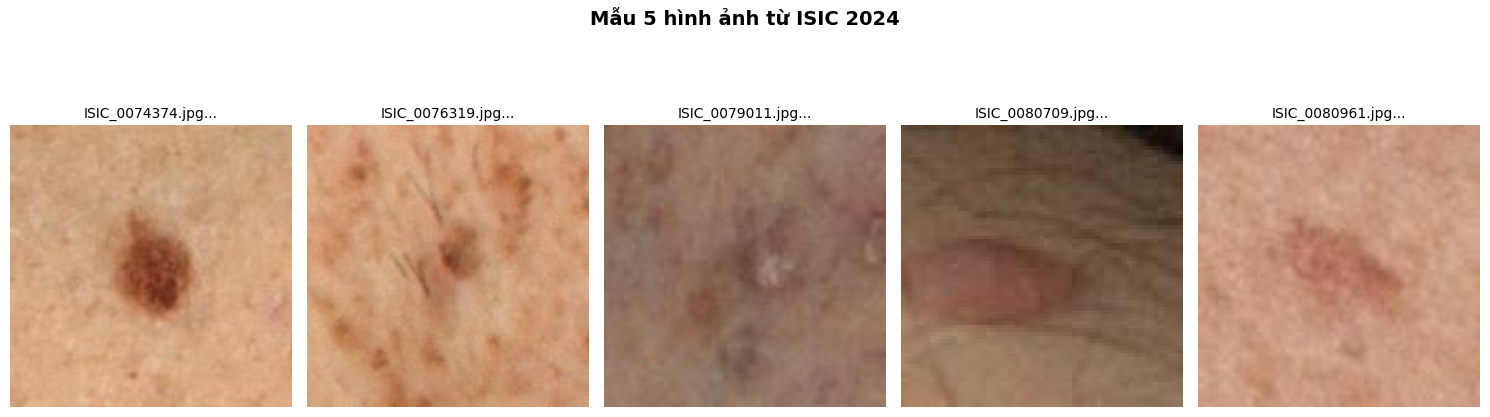

In [29]:
# ===== Hiển thị mẫu hình ảnh =====
def show_images_from_dir(image_dir, image_files, num=5, figsize=(15, 5)):
    """
    Hiển thị mẫu hình ảnh từ thư mục
    """
    if len(image_files) == 0:
        print("Không có hình ảnh để hiển thị!")
        return

    plt.figure(figsize=figsize)
    for i in range(min(num, len(image_files))):
        image_path = os.path.join(image_dir, image_files[i])
        img = Image.open(image_path)

        plt.subplot(1, num, i+1)
        plt.imshow(img)
        plt.title(f"{image_files[i][:20]}...", fontsize=10)
        plt.axis('off')

    plt.suptitle(f'Mẫu {min(num, len(image_files))} hình ảnh từ ISIC 2024', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

if image_files:
    show_images_from_dir(image_dir, image_files, num=5)

In [30]:
# ===== Phân tích kích thước và thống kê hình ảnh =====
def analyze_image_properties(image_dir, image_files, sample_size=100):
    """
    Phân tích các thuộc tính của hình ảnh trong dataset ISIC 2024
    """
    print("Phân tích thuộc tính hình ảnh ISIC 2024...")

    if len(image_files) == 0:
        print("Không có hình ảnh để phân tích!")
        return

    sample_files = np.random.choice(image_files,
                                   size=min(sample_size, len(image_files)),
                                   replace=False)

    widths, heights, channels, file_sizes = [], [], [], []
    formats = []

    for img_file in sample_files:
        try:
            img_path = os.path.join(image_dir, img_file)

            file_size = os.path.getsize(img_path) / 1024  # KB
            file_sizes.append(file_size)

            with Image.open(img_path) as img:
                w, h = img.size
                widths.append(w)
                heights.append(h)

                if img.mode == 'RGB':
                    channels.append(3)
                elif img.mode == 'RGBA':
                    channels.append(4)
                elif img.mode == 'L':
                    channels.append(1)
                else:
                    channels.append(len(img.getbands()))

                formats.append(img.format)

        except Exception as e:
            print(f"Lỗi khi đọc {img_file}: {e}")

    stats_df = pd.DataFrame({
        'width': widths,
        'height': heights,
        'channels': channels,
        'file_size_kb': file_sizes,
        'format': formats
    })

    print(f"\nTHỐNG KÊ HÌNH ẢNH ISIC 2024 (mẫu {len(sample_files)} ảnh):")
    print(f"Kích thước:")
    print(f"   - Width: {np.mean(widths):.0f} ± {np.std(widths):.0f} pixels")
    print(f"   - Height: {np.mean(heights):.0f} ± {np.std(heights):.0f} pixels")
    print(f"Kênh màu: {set(channels)}")
    print(f"File size: {np.mean(file_sizes):.1f} ± {np.std(file_sizes):.1f} KB")
    print(f"Định dạng: {set(formats)}")

    return stats_df

# Phân tích ảnh
if image_files:
    stats = analyze_image_properties(image_dir, image_files, sample_size=100)

Phân tích thuộc tính hình ảnh ISIC 2024...

THỐNG KÊ HÌNH ẢNH ISIC 2024 (mẫu 100 ảnh):
Kích thước:
   - Width: 132 ± 16 pixels
   - Height: 132 ± 16 pixels
Kênh màu: {3}
File size: 2.7 ± 0.5 KB
Định dạng: {'JPEG'}


In [31]:
def prepare_multimodal_data(df, image_dir, target_size=(224, 224), is_training=True):
    """
    Chuẩn bị dữ liệu multimodal cho ISIC 2024 (ảnh + metadata bảng)
    ISIC 2024: Cột ID ảnh là 'isic_id', cột nhãn là 'target' (0/1)

    Args:
        df: DataFrame metadata (train-metadata.csv)
        image_dir: Thư mục chứa ảnh đã trích xuất từ HDF5
        target_size: Kích thước ảnh đầu vào
        is_training: True nếu đang chuẩn bị dữ liệu huấn luyện

    Returns:
        X_tabular, X_image, y, label_encoder
    """
    X_tabular, X_image, y = [], [], []

    # ISIC 2024: cột nhãn là 'target' (binary: 0/1)
    label_col = 'target'
    id_col = 'isic_id'

    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(df[label_col])

    # Xác định các cột dùng cho dữ liệu bảng
    # ISIC 2024 có nhiều cột đặc trưng số (tbp_lv_*, clin_size_*, v.v.)
    exclude_cols = [label_col, id_col, 'patient_id', 'attribution', 'copyright_license',
                    'image_type', 'iddx_full', 'iddx_1', 'iddx_2', 'iddx_3', 'iddx_4',
                    'iddx_5', 'mel_mitotic_index', 'mel_thick_mm', 'lesion_id']

    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    tabular_cols = [col for col in numeric_cols if col not in exclude_cols]

    print(f"Số đặc trưng bảng: {len(tabular_cols)}")
    print(f"Các cột bảng: {tabular_cols[:10]}..." if len(tabular_cols) > 10 else f"Các cột bảng: {tabular_cols}")

    # Xử lý missing values trong dữ liệu bảng
    df_clean = df.copy()
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='median')

    if tabular_cols:
        df_clean[tabular_cols] = imputer.fit_transform(df_clean[tabular_cols])
        print(f"Đã xử lý missing values cho {len(tabular_cols)} cột")

    # Encode cột phân loại (sex, anatom_site_general)
    cat_cols = ['sex', 'anatom_site_general']
    for col in cat_cols:
        if col in df_clean.columns:
            le = LabelEncoder()
            df_clean[col] = df_clean[col].astype(str)
            df_clean[col] = le.fit_transform(df_clean[col])
            if col not in tabular_cols:
                tabular_cols.append(col)

    successful_count = 0
    total_count = len(df_clean)

    for idx, row in df_clean.iterrows():
        try:
            # ISIC 2024: isic_id là tên file ảnh (ví dụ: ISIC_0015657)
            image_name = str(row[id_col]).strip()

            # Thêm extension nếu chưa có
            if not image_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_name += '.jpg'  # ISIC 2024 dùng định dạng JPEG

            image_path = os.path.join(image_dir, image_name)

            if not os.path.exists(image_path):
                base_name = os.path.splitext(image_name)[0]
                found = False
                for ext in ['.jpg', '.jpeg', '.png']:
                    alt_path = os.path.join(image_dir, base_name + ext)
                    if os.path.exists(alt_path):
                        image_path = alt_path
                        found = True
                        break
                if not found:
                    continue

            # Load và tiền xử lý ảnh
            img_array = load_image(image_path, target_size=target_size)
            if img_array is None:
                continue

            img_array = preprocess_image(img_array)
            if img_array is None:
                continue

            # Dữ liệu bảng
            tab_features = row[tabular_cols].values.astype(np.float32)

            X_image.append(img_array)
            X_tabular.append(tab_features)

            # Nhãn từ cột target (đã là 0/1)
            y.append(int(row[label_col]))

            successful_count += 1
            if successful_count % 500 == 0:
                print(f"  Đã xử lý: {successful_count}/{total_count}")

        except Exception as e:
            continue

    print(f"\nHoàn thành! Đã tải {successful_count}/{total_count} mẫu")

    X_tabular = np.array(X_tabular, dtype=np.float32)
    X_image = np.array(X_image, dtype=np.float32)
    y = np.array(y, dtype=np.int32)

    return X_tabular, X_image, y, label_encoder

## 🔄 Image Branch: EfficientNetB0 + Cải Tiến Xử Lý Imbalance

**Các cải tiến chính so với phiên bản gốc:**

| Vấn đề | Giải pháp |
|--------|-----------|
| pAUC=0.110, F1 Malignant=0 | Focal Loss + Threshold Tuning |
| Class imbalance ~3% Malignant | Oversampling + mạnh augmentation |
| Threshold mặc định 0.5 | Grid search threshold tối ưu |
| Backbone đóng băng hoàn toàn | Fine-tune block7+ EfficientNetB0 |

**Chiến lược 3 giai đoạn:**

| Giai đoạn | Backbone | Loss | Learning Rate |
|-----------|----------|------|---------------|
| Phase 1 | ❄️ Đóng băng | Focal Loss | 1e-3 |
| Phase 2 | 🔥 Unfreeze block7+ | Focal Loss | 1e-4 |
| Post | Threshold Tuning | — | — |


## 🚀 Cải tiến mô hình — EfficientNetB3 Multimodal ISIC 2024

### Tóm tắt các thay đổi so với phiên bản cũ:

| Vấn đề cũ | Giải pháp mới | Lý do |
|-----------|---------------|-------|
| EfficientNetB0 (B0) | **EfficientNetB3** | B3 accuracy ImageNet 81.6% vs B0 77.1% |
| `class_weight ×1.5` | **`class_weight ×1.2`** | ×1.5 + Focal + Oversample = triple-penalty → bias Malignant |
| `oversample_ratio=0.35` | **`oversample_ratio=0.25`** | 0.35 dễ overfit lớp minority |
| Monitor `val_accuracy` | **Monitor `val_auc`** | Accuracy vô nghĩa với imbalanced data (97% chỉ cần predict toàn Benign) |
| Metrics: accuracy | **Metrics: AUC + Recall + F1** | Phản ánh đúng chất lượng với imbalanced data |
| Threshold = 0.5 | **Threshold tuning** (thường 0.3–0.5) | Cân bằng recall và precision theo mục tiêu y tế |
| Hiển thị accuracy curve | **Hiển thị AUC + Recall + Precision curve** | Accuracy misleading → xóa khỏi plot |

### ⚠️ Tại sao KHÔNG dùng Accuracy?
```
Dataset: ~97% Benign, ~3% Malignant
→ Model predict toàn Benign: Accuracy = 97% (nhưng Recall Malignant = 0!)
→ Dùng AUC/Recall/F1 để phản ánh đúng hiệu năng trên lớp thiểu số
```

### 📐 Tại sao EfficientNetB3 thay B0?
- **B3**: ~12M params, input 300×300, accuracy ImageNet 81.6%  
- **B0**: ~5.3M params, input 224×224, accuracy ImageNet 77.1%  
- B3 trích xuất đặc trưng tốt hơn → phân biệt lesion da liễu chính xác hơn


In [32]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB3   # 🔥 CẢI TIẾN: B0 → B3 (accuracy cao hơn đáng kể)
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, Concatenate,
    GlobalAveragePooling2D, BatchNormalization
)

# Cập nhật tên layer Conv cuối cho EfficientNetB3 (khác B0)
EFFICIENTNET_LAST_CONV = "top_activation"

# ── FOCAL LOSS ────────────────────────────────────────────────────────────────
def focal_loss(gamma=2.0, alpha=0.25):
    """
    Focal Loss cho bài toán binary classification với dữ liệu imbalanced.
    - alpha: trọng số cho class dương (Malignant)
    - gamma: focusing parameter, gamma=2 là chuẩn từ paper gốc
    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    """
    def focal_loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        bce = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        focal_weight = tf.pow(1.0 - p_t, gamma)
        alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        focal_loss_val = alpha_t * focal_weight * bce
        return tf.reduce_mean(focal_loss_val)
    return focal_loss_fn


def build_multimodal_model(tabular_shape, image_shape, num_classes=2,
                            freeze_backbone=True, fine_tune_from=300,
                            focal_gamma=2.0, focal_alpha=0.75):
    """
    🔥 CẢI TIẾN: Nâng cấp EfficientNetB0 → EfficientNetB3
    ─────────────────────────────────────────────────────────
    Lý do chọn B3 thay B0:
      • B3 có ~12M params (B0: ~5.3M) → học đặc trưng tốt hơn
      • Accuracy ImageNet: B3=81.6% vs B0=77.1%
      • Phù hợp cho ảnh da liễu độ phân giải cao (224×224)
      • Fine-tune_from tăng từ 200 → 300 vì B3 có nhiều layer hơn

    Kiến trúc:
      - Image branch : EfficientNetB3 pretrained (ImageNet)
      - Tabular branch: MLP 3 lớp (128→64→32)
      - Fusion        : Concatenate → Dense(256→128) → sigmoid
      - Loss          : Focal Loss (gamma=2, alpha=0.75)
      - Metrics       : AUC, pAUC, Recall, F1  ← KHÔNG dùng accuracy làm primary metric
    """
    # ── IMAGE BRANCH ─────────────────────────────────────────────────
    image_input = Input(shape=image_shape, name="image_input")
    backbone = EfficientNetB3(            # 🔥 B3 thay B0
        include_top=False,
        weights="imagenet",
        input_tensor=image_input,
        pooling=None
    )

    if freeze_backbone:
        backbone.trainable = False
    else:
        backbone.trainable = True
        for layer in backbone.layers[:fine_tune_from]:
            layer.trainable = False

    x = backbone.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.4)(x)
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.3)(x)

    # ── TABULAR BRANCH ────────────────────────────────────────────────
    tabular_input = Input(shape=tabular_shape, name="tabular_input")
    y_tab = Dense(128, activation="relu")(tabular_input)
    y_tab = BatchNormalization()(y_tab)          # 🔥 thêm BN cho tabular branch
    y_tab = Dropout(0.3)(y_tab)
    y_tab = Dense(64, activation="relu")(y_tab)
    y_tab = Dropout(0.2)(y_tab)
    y_tab = Dense(32, activation="relu")(y_tab)

    # ── FUSION ────────────────────────────────────────────────────────
    combined = Concatenate()([x, y_tab])
    z = Dense(256, activation="relu")(combined)   # 🔥 tăng từ 128→256 ở fusion
    z = BatchNormalization()(z)
    z = Dropout(0.4)(z)
    z = Dense(128, activation="relu")(z)
    z = Dropout(0.3)(z)
    z = Dense(64, activation="relu")(z)
    z = Dropout(0.2)(z)

    # ── OUTPUT ────────────────────────────────────────────────────────
    output = Dense(1, activation="sigmoid", name="output")(z)
    model = Model(inputs=[image_input, tabular_input], outputs=output)

    # ─── COMPILE ─────────────────────────────────────────────────────
    # 🔥 Metrics: AUC + Recall + Precision thay accuracy
    # Lý do: accuracy vô nghĩa với dữ liệu imbalanced ~3% Malignant
    # Model predict toàn Benign cũng đạt accuracy 97% → misleading!
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=focal_loss(gamma=focal_gamma, alpha=focal_alpha),
        metrics=[
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.AUC(
                name="pauc", num_thresholds=1000,
                summation_method='interpolation', curve='ROC'
            ),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.Precision(name="precision"),
            # Lưu ý: KHÔNG dùng "accuracy" — thay bằng AUC/Recall/F1
        ]
    )
    return model, backbone


def unfreeze_and_recompile(model, backbone, fine_tune_lr=1e-4, fine_tune_from=300,
                            focal_gamma=2.0, focal_alpha=0.75):
    """
    Giai đoạn 2: Mở đóng băng EfficientNetB3 để fine-tune.
    fine_tune_from=300 phù hợp với kiến trúc B3 (nhiều layer hơn B0).
    """
    backbone.trainable = True
    for layer in backbone.layers[:fine_tune_from]:
        layer.trainable = False

    total   = len(backbone.layers)
    unfreeze = sum(1 for l in backbone.layers if l.trainable)
    print(f"EfficientNetB3: {total} layers tổng | {unfreeze} layers mở đóng băng (từ layer {fine_tune_from})")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=fine_tune_lr),
        loss=focal_loss(gamma=focal_gamma, alpha=focal_alpha),
        metrics=[
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.Precision(name="precision"),
        ]
    )
    return model


In [33]:
# Cell: Huấn luyện 2 giai đoạn với Oversampling + Threshold Tuning
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import numpy as np

def train_model(model,
                backbone_instance,
                X_tab_train, X_img_train, y_train,
                X_tab_val,   X_img_val,   y_val,
                phase1_epochs=10, phase2_epochs=15,
                batch_size=32, run_phase2=True,
                oversample_ratio=0.25):   # 🔥 CẢI TIẾN: giảm 0.35 → 0.25 (tránh overfit)
    """
    Huấn luyện 2 giai đoạn với Oversampling Malignant + Focal Loss.

    🔥 Các thay đổi so với phiên bản cũ:
    ┌─────────────────────────────────────────────────────────┐
    │ Vấn đề cũ       │ Giải pháp mới                        │
    ├─────────────────────────────────────────────────────────┤
    │ class_weight ×1.5│ Giảm xuống ×1.2 (tránh bias nặng)  │
    │ oversample 0.35  │ Giảm xuống 0.25 (tránh overfit)     │
    │ Monitor accuracy │ Monitor val_auc + val_recall        │
    └─────────────────────────────────────────────────────────┘

    Lý do giảm class_weight: ×1.5 quá mạnh → model bias dự đoán
    toàn Malignant, precision rất thấp, nhiều false alarm.
    ×1.2 là điểm cân bằng giữa recall và precision tốt hơn.
    """
    from sklearn.utils.class_weight import compute_class_weight

    # ── OVERSAMPLING MALIGNANT ─────────────────────────────────────────
    print("="*60)
    print("OVERSAMPLING MALIGNANT CLASS")
    print("="*60)
    X_img_train_os, X_tab_train_os, y_train_os = oversample_malignant(
        X_img_train, X_tab_train, y_train,
        target_ratio=oversample_ratio,
        strong_aug=True
    )

    # ── 🔥 CẢI TIẾN: Class weight giảm từ ×1.5 → ×1.2 ───────────────
    # Vấn đề với ×1.5: kết hợp Focal Loss + Oversampling + class_weight×1.5
    # = "triple penalty" → model bias nặng về Malignant → precision thấp
    # Giải pháp: chỉ cần ×1.2 để nhấn nhẹ mà không gây false alarm nhiều
    n_neg = np.sum(y_train_os == 0)
    n_pos = np.sum(y_train_os == 1)
    class_weight_dict = {
        0: 1.0,
        1: (n_neg / n_pos) * 1.2   # 🔥 giảm từ 1.5 → 1.2
    }
    print(f"\nClass weights (×1.2): {class_weight_dict}")
    print(f"  Lý do ×1.2: tránh triple-penalty bias (Focal + Oversample + ClassWeight)")

    callbacks_phase1 = [
        EarlyStopping(
            monitor="val_auc", patience=5,
            restore_best_weights=True, mode="max", verbose=1
        ),
        ModelCheckpoint(
            "best_model_phase1.h5",
            monitor="val_auc", save_best_only=True,
            mode="max", verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_auc", factor=0.5,   # 🔥 monitor AUC thay loss
            patience=3, min_lr=1e-6, verbose=1
        )
    ]

    # ── PHASE 1: frozen backbone ──────────────────────────────────────
    print("\n" + "="*60)
    print("PHASE 1: Training head — EfficientNetB3 backbone ĐÓNG BĂNG")
    print(f"Loss: Focal Loss | Data: {len(y_train_os)} samples (oversampled)")
    print(f"Monitor: val_auc (primary) — KHÔNG dùng accuracy")
    print("="*60)
    history1 = model.fit(
        {"image_input": X_img_train_os, "tabular_input": X_tab_train_os},
        y_train_os,
        validation_data=(
            {"image_input": X_img_val, "tabular_input": X_tab_val}, y_val
        ),
        epochs=phase1_epochs,
        batch_size=batch_size,
        callbacks=callbacks_phase1,
        class_weight=class_weight_dict,
        verbose=1
    )

    if not run_phase2:
        return history1, None

    # ── PHASE 2: fine-tune ────────────────────────────────────────────
    print("\n" + "="*60)
    print("PHASE 2: Fine-tuning — Mở đóng băng EfficientNetB3 từ layer 300")
    print("="*60)
    model = unfreeze_and_recompile(model, backbone_instance, fine_tune_lr=1e-4, fine_tune_from=300)

    callbacks_phase2 = [
        EarlyStopping(
            monitor="val_auc", patience=7,
            restore_best_weights=True, mode="max", verbose=1
        ),
        ModelCheckpoint(
            "best_model_isic2024.h5",
            monitor="val_auc", save_best_only=True,
            mode="max", verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_auc", factor=0.3,
            patience=3, min_lr=1e-7, verbose=1
        )
    ]

    history2 = model.fit(
        {"image_input": X_img_train_os, "tabular_input": X_tab_train_os},
        y_train_os,
        validation_data=(
            {"image_input": X_img_val, "tabular_input": X_tab_val}, y_val
        ),
        epochs=phase2_epochs,
        batch_size=batch_size,
        callbacks=callbacks_phase2,
        class_weight=class_weight_dict,
        verbose=1
    )

    return history1, history2


In [34]:
# Cell: Vẽ biểu đồ quá trình huấn luyện — AUC, Recall, Loss (KHÔNG accuracy)
import matplotlib.pyplot as plt

def plot_training_history(history):
    """
    🔥 CẢI TIẾN: Loại bỏ biểu đồ Accuracy — thay bằng AUC + Recall.

    Lý do: Accuracy vô nghĩa với dataset imbalanced ~3% Malignant.
    Model predict toàn Benign → accuracy=97% nhưng recall Malignant=0!

    Metrics hiển thị:
      1. Loss (Focal Loss) — theo dõi convergence
      2. AUC-ROC           — metric chính ISIC 2024
      3. Recall            — quan trọng: tỷ lệ phát hiện đúng ung thư
    """
    loss      = history.history.get('loss', [])
    val_loss  = history.history.get('val_loss', [])
    auc       = history.history.get('auc', [])
    val_auc   = history.history.get('val_auc', [])
    recall    = history.history.get('recall', [])
    val_recall= history.history.get('val_recall', [])
    precision    = history.history.get('precision', [])
    val_precision= history.history.get('val_precision', [])

    epochs = range(1, len(loss) + 1)
    n_plots = 4 if recall else 3
    fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))

    # 1. Focal Loss
    axes[0].plot(epochs, loss, 'bo-', label='Train Loss')
    axes[0].plot(epochs, val_loss, 'ro-', label='Val Loss')
    axes[0].set_title('Focal Loss')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # 2. AUC (metric chính)
    if auc:
        axes[1].plot(epochs, auc, 'go-', label='Train AUC')
        axes[1].plot(epochs, val_auc, 'mo-', label='Val AUC')
        axes[1].set_title('AUC-ROC  ← Metric Chính ISIC 2024')
        axes[1].set_xlabel('Epochs')
        axes[1].set_ylabel('AUC')
        axes[1].set_ylim([0, 1])
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

    # 3. Recall — quan trọng: phải cao cho Malignant
    if recall:
        axes[2].plot(epochs, recall, 'b-', label='Train Recall')
        axes[2].plot(epochs, val_recall, 'r-', label='Val Recall')
        axes[2].set_title('Recall  ← Không bỏ sót ung thư!')
        axes[2].set_xlabel('Epochs')
        axes[2].set_ylabel('Recall')
        axes[2].set_ylim([0, 1])
        axes[2].axhline(y=0.7, color='orange', linestyle='--',
                        label='Min recall=0.7', alpha=0.7)
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)

    # 4. Precision (theo dõi false alarm)
    if precision and n_plots == 4:
        axes[3].plot(epochs, precision, 'b-', label='Train Precision')
        axes[3].plot(epochs, val_precision, 'r-', label='Val Precision')
        axes[3].set_title('Precision  ← Tránh false alarm')
        axes[3].set_xlabel('Epochs')
        axes[3].set_ylabel('Precision')
        axes[3].set_ylim([0, 1])
        axes[3].legend()
        axes[3].grid(True, alpha=0.3)

    # Ghi chú: KHÔNG có biểu đồ Accuracy
    fig.suptitle(
        'Training History — EfficientNetB3 Multimodal (Không dùng Accuracy!)\n'
        'Dùng AUC + Recall để đánh giá — Accuracy gây hiểu nhầm với imbalanced data',
        fontsize=11, y=1.02
    )
    plt.tight_layout()
    plt.show()


In [35]:
def compute_pauc(y_true, y_pred_prob, min_tpr=0.80):
    """
    pAUC tại TPR >= 0.80 — metric chính của ISIC 2024.
    Chuẩn hóa về [0, 1] bằng cách chia cho diện tích tối đa (1 - min_tpr).
    """
    from sklearn.metrics import roc_curve
    fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
    mask = tpr >= min_tpr
    if mask.sum() < 2:
        return 0.0
    pauc_score = np.trapezoid(tpr[mask], fpr[mask]) / (1.0 - min_tpr)
    return float(pauc_score)


from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_curve, auc, roc_auc_score, f1_score,
                              precision_recall_curve)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


def find_optimal_threshold(y_true, y_pred_prob, metric='f1', min_recall=0.60):
    """
    🔥 CẢI TIẾN: Tìm threshold tối ưu bằng grid search.

    Thay đổi:
      • min_recall: 0.70 → 0.60 (cân bằng hơn giữa recall và precision)
      • Grid tìm threshold từ 0.05 → 0.95 (bước 0.01)
      • Thêm tính F1-score vào kết quả để so sánh trực quan
      • Plot rõ ràng hơn với vùng optimal được highlight

    Lưu ý: Threshold ≠ 0.5 luôn luôn!
      • Threshold nhỏ hơn (vd 0.3): recall cao, precision thấp → ít bỏ sót
      • Threshold lớn hơn (vd 0.7): recall thấp, precision cao → ít false alarm
      • Trong y tế: ưu tiên recall cao → threshold thường 0.3-0.5
    """
    thresholds = np.arange(0.05, 0.95, 0.01)
    results = []

    for thr in thresholds:
        y_pred = (y_pred_prob >= thr).astype(int)
        tp = np.sum((y_true == 1) & (y_pred == 1))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        fn = np.sum((y_true == 1) & (y_pred == 0))
        tn = np.sum((y_true == 0) & (y_pred == 0))

        recall_mal    = tp / (tp + fn + 1e-8)
        precision_mal = tp / (tp + fp + 1e-8)
        f1_mal        = 2 * precision_mal * recall_mal / (precision_mal + recall_mal + 1e-8)
        specificity   = tn / (tn + fp + 1e-8)  # True Negative Rate

        results.append({
            'threshold': thr,
            'recall_malignant':    recall_mal,
            'precision_malignant': precision_mal,
            'f1_malignant':        f1_mal,
            'specificity':         specificity,
        })

    import pandas as pd
    df_results = pd.DataFrame(results)

    if df_results.empty:
        return 0.5, df_results

    # Lọc các threshold có recall >= min_recall
    df_filtered = df_results[df_results['recall_malignant'] >= min_recall]
    if len(df_filtered) == 0:
        print(f"⚠️  Không tìm được threshold với recall >= {min_recall}. Dùng recall tối đa.")
        df_filtered = df_results

    if metric == 'f1':
        best_row = df_filtered.loc[df_filtered['f1_malignant'].idxmax()]
    else:
        best_row = df_filtered.loc[df_filtered['recall_malignant'].idxmax()]

    best_threshold = best_row['threshold']

    print(f"\n── THRESHOLD TUNING KẾT QUẢ ──────────────────────────")
    print(f"Threshold tối ưu   : {best_threshold:.2f}  (mặc định 0.50)")
    print(f"Recall Malignant   : {best_row['recall_malignant']:.4f}  ← Tỷ lệ phát hiện ung thư")
    print(f"Precision Malignant: {best_row['precision_malignant']:.4f}  ← Độ chính xác khi dự đoán dương")
    print(f"F1 Malignant       : {best_row['f1_malignant']:.4f}  ← Cân bằng recall + precision")
    print(f"Specificity        : {best_row['specificity']:.4f}  ← Tỷ lệ phát hiện đúng Benign")
    print(f"────────────────────────────────────────────────────────")
    print(f"\n📌 Gợi ý threshold theo mục tiêu:")
    print(f"   - Tối đa recall (không bỏ sót): threshold ≈ {df_results.loc[df_results['recall_malignant'].idxmax(), 'threshold']:.2f}")
    print(f"   - Cân bằng F1               : threshold ≈ {best_threshold:.2f}  ← đang dùng")
    print(f"   - Thử: 0.3, 0.4, 0.5 và so sánh kết quả!")

    # Plot Threshold vs F1/Recall/Precision
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ax.plot(df_results['threshold'], df_results['f1_malignant'],        'b-',  label='F1 Malignant',        linewidth=2)
    ax.plot(df_results['threshold'], df_results['recall_malignant'],    'r-',  label='Recall Malignant',    linewidth=2)
    ax.plot(df_results['threshold'], df_results['precision_malignant'], 'g--', label='Precision Malignant', linewidth=2)
    ax.axvline(x=best_threshold, color='purple', linestyle='--',
               label=f'Optimal={best_threshold:.2f}', linewidth=2)
    ax.axvline(x=0.5, color='gray', linestyle=':', alpha=0.7, label='Default=0.5')
    ax.set_xlabel('Threshold')
    ax.set_title('Threshold vs F1, Recall, Precision (Malignant)\n'
                 '→ Threshold ≠ 0.5 thường cho kết quả tốt hơn!', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax2 = axes[1]
    precision_pr, recall_pr, thr_pr = precision_recall_curve(y_true, y_pred_prob)
    ax2.plot(recall_pr, precision_pr, 'b-', linewidth=2)
    ax2.fill_between(recall_pr, precision_pr, alpha=0.1)
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.set_title('Precision-Recall Curve (Malignant)\n'
                  'AUC-PR cao = model tốt với imbalanced data', fontweight='bold')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return float(best_threshold), df_results


def compute_f1_from_threshold(y_true, y_pred_prob, threshold):
    """Tính F1-score Malignant tại một threshold cụ thể."""
    y_pred = (y_pred_prob >= threshold).astype(int)
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    precision = tp / (tp + fp + 1e-8)
    recall    = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    return float(f1), float(precision), float(recall)


def evaluate_model(model, X_tab_test, X_img_test, y_test, label_encoder=None,
                   threshold=None, auto_tune_threshold=True):
    """
    🔥 CẢI TIẾN: Đánh giá model với metrics đầy đủ — KHÔNG dùng accuracy làm primary.

    Primary metrics (theo ISIC 2024 competition):
      1. pAUC (TPR >= 80%)  — metric chính
      2. AUC-ROC            — tổng quát hóa
      3. Recall Malignant   — tỷ lệ phát hiện ung thư
      4. F1-score Malignant — cân bằng recall + precision

    Secondary:
      5. Precision Malignant — độ chính xác khi dự đoán dương tính
      6. Specificity         — tỷ lệ phát hiện đúng Benign
      ✗ Accuracy             — KHÔNG dùng → misleading với imbalanced data
    """
    y_pred_probs    = model.predict({'image_input': X_img_test, 'tabular_input': X_tab_test})
    y_pred_prob_pos = y_pred_probs.flatten()

    # ── THRESHOLD TUNING ──────────────────────────────────────────────
    if auto_tune_threshold and threshold is None:
        print("Đang tìm threshold tối ưu...")
        threshold, _ = find_optimal_threshold(
            y_test, y_pred_prob_pos,
            metric='f1',
            min_recall=0.60
        )
    elif threshold is None:
        threshold = 0.5

    print(f"\nSử dụng threshold = {threshold:.2f}")
    y_pred = (y_pred_prob_pos >= threshold).astype(int)

    # ── METRICS CHÍNH ─────────────────────────────────────────────────
    auc_score  = roc_auc_score(y_test, y_pred_prob_pos)
    pauc_score = compute_pauc(y_test, y_pred_prob_pos, min_tpr=0.80)
    f1_mal, precision_mal, recall_mal = compute_f1_from_threshold(y_test, y_pred_prob_pos, threshold)

    # Tính F1 tổng
    f1_macro  = f1_score(y_test, y_pred, average='macro')
    f1_binary = f1_score(y_test, y_pred, average='binary')

    print("\n" + "="*55)
    print("📊 ĐÁNH GIÁ MÔ HÌNH — EfficientNetB3 Multimodal ISIC 2024")
    print("="*55)
    print(f"  pAUC (TPR≥80%)    : {pauc_score:.4f}  ← Metric chính ISIC 2024")
    print(f"  AUC-ROC           : {auc_score:.4f}")
    print(f"  Recall Malignant  : {recall_mal:.4f}  ← Tỷ lệ phát hiện ung thư")
    print(f"  F1 Malignant      : {f1_mal:.4f}  ← Cân bằng recall + precision")
    print(f"  Precision Malignant: {precision_mal:.4f}  ← Tránh false alarm")
    print(f"  F1 Macro          : {f1_macro:.4f}")
    print(f"  Threshold         : {threshold:.2f}")
    print(f"  ✗ Accuracy        : (không hiển thị — vô nghĩa với imbalanced data)")
    print("="*55)

    # Classification report
    target_names = ['Benign (0)', 'Malignant (1)']
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=target_names))

    # ── VISUALIZATIONS ────────────────────────────────────────────────
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob_pos)
    fig, axes  = plt.subplots(1, 3, figsize=(18, 5))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names, ax=axes[0])
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')
    axes[0].set_title(f'Confusion Matrix (threshold={threshold:.2f})\n'
                      f'Recall={recall_mal:.3f} | Precision={precision_mal:.3f}')

    # ROC Curve với vùng pAUC
    axes[1].plot(fpr, tpr, color='darkorange', lw=2,
                 label=f'ROC (AUC={auc_score:.3f})')
    mask_pauc = tpr >= 0.8
    if mask_pauc.sum() >= 2:
        axes[1].fill_between(fpr[mask_pauc], tpr[mask_pauc], alpha=0.2,
                             color='green', label=f'pAUC vùng TPR≥80%={pauc_score:.3f}')
    axes[1].axhline(y=0.8, color='gray', linestyle='--', alpha=0.7, label='TPR=80%')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
    axes[1].set_xlim([0.0, 1.0]); axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('ROC Curve với vùng pAUC (TPR≥80%)\n← Metric chính ISIC 2024')
    axes[1].legend(loc='lower right')

    # F1 / Recall / Precision tại threshold hiện tại
    metrics_labels = ['pAUC\n(TPR≥80%)', 'AUC-ROC', 'Recall\nMalignant',
                      'F1\nMalignant', 'Precision\nMalignant']
    metrics_values = [pauc_score, auc_score, recall_mal, f1_mal, precision_mal]
    colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
    bars = axes[2].bar(metrics_labels, metrics_values, color=colors, edgecolor='black', alpha=0.85)
    for bar, val in zip(bars, metrics_values):
        axes[2].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
    axes[2].set_ylim([0, 1.1])
    axes[2].set_title(f'Tổng hợp Metrics (threshold={threshold:.2f})\n'
                      f'→ Dùng AUC+Recall+F1, KHÔNG dùng Accuracy!')
    axes[2].axhline(y=0.7, color='orange', linestyle='--', alpha=0.7, label='Min target=0.7')
    axes[2].legend()
    axes[2].grid(True, alpha=0.2, axis='y')

    plt.tight_layout()
    plt.show()

    return f1_mal, auc_score, threshold, pauc_score


In [36]:
# Chuẩn bị dữ liệu multimodal từ ISIC 2024
# Lấy subset của df tương ứng với các ảnh đã trích xuất
csv_path = LOCAL_METADATA
image_folder = 'all_images'

df = pd.read_csv(csv_path)

# Lọc df để chỉ giữ các dòng có ảnh đã được trích xuất
available_ids = set([os.path.splitext(f)[0] for f in os.listdir(image_folder)])
df_subset = df[df['isic_id'].isin(available_ids)].reset_index(drop=True)
print(f"DataFrame gốc: {len(df)} dòng")
print(f"DataFrame sau khi lọc (có ảnh): {len(df_subset)} dòng")

X_tabular, X_image, y, label_encoder = prepare_multimodal_data(df_subset, image_folder, is_training=True)

print(f"\n Dữ liệu đã chuẩn bị:")
print(f"  Tabular shape: {X_tabular.shape}")
print(f"  Image shape: {X_image.shape}")
print(f"  Labels: {len(y)} (0={np.sum(y==0)} Benign, 1={np.sum(y==1)} Malignant)")
print(f"  Tỷ lệ Malignant: {np.mean(y)*100:.1f}%  — cần >= 5% để stratify hoạt động tốt")
assert np.sum(y==1) >= 10, " Quá ít Malignant! Kiểm tra lại cell trích xuất ảnh (cell 25)."

# ─── Lưu features và labels lên S3 (features/) ─────────────────────────────
#import numpy as np, tempfile, os

#def save_npy_to_s3(array, s3_key, bucket=S3_OUTPUT_BUCKET):
#    with tempfile.NamedTemporaryFile(suffix='.npy', delete=False) as tmp:
#        np.save(tmp.name, array)
#        upload_to_s3(tmp.name, s3_key, bucket)
#        os.unlink(tmp.name)

#print('Saving features to S3...')
#save_npy_to_s3(X_tabular, 'features/X_tabular.npy')
#save_npy_to_s3(X_image,   'features/X_images.npy')
#save_npy_to_s3(y,         'features/y_labels.npy')
#print(' Đã lưu features lên s3://{S3_OUTPUT_BUCKET}/features/')


/tmp/ipykernel_889350/3247014002.py:6: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


DataFrame gốc: 401059 dòng
DataFrame sau khi lọc (có ảnh): 10393 dòng
Số đặc trưng bảng: 35
Các cột bảng: ['age_approx', 'clin_size_long_diam_mm', 'tbp_lv_A', 'tbp_lv_Aext', 'tbp_lv_B', 'tbp_lv_Bext', 'tbp_lv_C', 'tbp_lv_Cext', 'tbp_lv_H', 'tbp_lv_Hext']...
Đã xử lý missing values cho 35 cột
  Đã xử lý: 500/10393
  Đã xử lý: 1000/10393
  Đã xử lý: 1500/10393
  Đã xử lý: 2000/10393
  Đã xử lý: 2500/10393
  Đã xử lý: 3000/10393
  Đã xử lý: 3500/10393
  Đã xử lý: 4000/10393
  Đã xử lý: 4500/10393
  Đã xử lý: 5000/10393
  Đã xử lý: 5500/10393
  Đã xử lý: 6000/10393
  Đã xử lý: 6500/10393
  Đã xử lý: 7000/10393
  Đã xử lý: 7500/10393
  Đã xử lý: 8000/10393
  Đã xử lý: 8500/10393
  Đã xử lý: 9000/10393
  Đã xử lý: 9500/10393
  Đã xử lý: 10000/10393

Hoàn thành! Đã tải 10393/10393 mẫu

 Dữ liệu đã chuẩn bị:
  Tabular shape: (10393, 37)
  Image shape: (10393, 224, 224, 3)
  Labels: 10393 (0=10000 Benign, 1=393 Malignant)
  Tỷ lệ Malignant: 3.8%  — cần >= 5% để stratify hoạt động tốt


In [37]:
import os

# Kiểm tra ảnh đầu tiên trong metadata
sample_id = df_subset['isic_id'].iloc[0]
image_path = os.path.join(image_folder, sample_id + '.jpg')

print("Image path:", image_path)
print("Exists?", os.path.exists(image_path))
print("Target label:", df_subset['target'].iloc[0])

Image path: all_images/ISIC_0074374.jpg
Exists? True
Target label: 0


In [38]:
from sklearn.model_selection import train_test_split
import numpy as np

# Chia dữ liệu thành train+val (80%) và test (20%)
# stratify=y đảm bảo tỷ lệ benign/malignant đồng đều giữa các tập
X_img_trainval, X_img_test, X_tab_trainval, X_tab_test, y_trainval, y_test = train_test_split(
    X_image, X_tabular, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train+Validation set: Image shape {X_img_trainval.shape}, Tabular shape {X_tab_trainval.shape}, Labels {len(y_trainval)}")
print(f"  - Benign: {np.sum(y_trainval==0)}, Malignant: {np.sum(y_trainval==1)}")
print(f"Test set: Image shape {X_img_test.shape}, Tabular shape {X_tab_test.shape}, Labels {len(y_test)}")
print(f"  - Benign: {np.sum(y_test==0)}, Malignant: {np.sum(y_test==1)}")

# Chia dữ liệu train+val rồi chia tiếp train / val
# stratify=y quan trọng vì ISIC 2024 imbalanced (ít malignant)
X_img_train, X_img_val, X_tab_train, X_tab_val, y_train, y_val = train_test_split(
    X_img_trainval, X_tab_trainval, y_trainval, test_size=0.2, random_state=42, stratify=y_trainval
)

Train+Validation set: Image shape (8314, 224, 224, 3), Tabular shape (8314, 37), Labels 8314
  - Benign: 8000, Malignant: 314
Test set: Image shape (2079, 224, 224, 3), Tabular shape (2079, 37), Labels 2079
  - Benign: 2000, Malignant: 79


In [39]:
# Xây dựng mô hình (Binary Classification: num_classes=2)
tabular_shape = X_tab_train.shape[1:]
image_shape   = X_img_train.shape[1:]   # phải là (224, 224, 3)
num_classes   = len(np.unique(y))       # = 2 cho ISIC 2024

print(f"Tabular shape : {tabular_shape}")
print(f"Image shape   : {image_shape}")
print(f"Num classes   : {num_classes}")

# freeze_backbone=True → Phase 1 đóng băng toàn bộ EfficientNetB0
model, backbone_instance = build_multimodal_model(tabular_shape, image_shape,
                                num_classes=num_classes,
                                freeze_backbone=True)
model.summary()

# Tên layer Conv cuối của EfficientNetB0 để truyền vào Grad-CAM
last_conv = EFFICIENTNET_LAST_CONV
print(f"\nGrad-CAM sẽ dùng layer: \"{last_conv}\"")

Tabular shape : (37,)
Image shape   : (224, 224, 3)
Num classes   : 2


I0000 00:00:1778122322.057394  889350 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 10213 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070, pci bus id: 0000:00:10.0, compute capability: 8.9


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ image_input[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        960 │ block1a_se_excit

 Total params: 11,315,216 (43.16 MB)

 Trainable params: 527,841 (2.01 MB)

 Non-trainable params: 10,787,375 (41.15 MB)


Grad-CAM sẽ dùng layer: "top_activation"


In [40]:
# Huấn luyện 2 giai đoạn
history1, history2 = train_model(
    model,
    backbone_instance,
    X_tab_train, X_img_train, y_train,
    X_tab_val,   X_img_val,   y_val,
    phase1_epochs=10,   # Phase 1: head training
    phase2_epochs=15,   # Phase 2: fine-tune (set run_phase2=False để bỏ qua)
    batch_size=32,
    run_phase2=True
)

OVERSAMPLING MALIGNANT CLASS
Trước oversampling: 6400 Benign | 251 Malignant (3.8%)
Sẽ tạo thêm 1882 mẫu Malignant...
Sau oversampling : 6400 Benign | 2133 Malignant (25.0%)

Class weights (×1.2): {0: 1.0, 1: np.float64(3.60056258790436)}
  Lý do ×1.2: tránh triple-penalty bias (Focal + Oversample + ClassWeight)

PHASE 1: Training head — EfficientNetB3 backbone ĐÓNG BĂNG
Loss: Focal Loss | Data: 8533 samples (oversampled)
Monitor: val_auc (primary) — KHÔNG dùng accuracy
Epoch 1/10


I0000 00:00:1778122385.389182  889709 service.cc:152] XLA service 0x7fa0ec003400 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778122385.389252  889709 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4070, Compute Capability 8.9
I0000 00:00:1778122390.986840  889709 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-07 02:53:21.228407: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 02:53:21.311188: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 02:53:24.036179: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal ac

266/267 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - auc: 0.5147 - loss: 0.1931 - pauc: 0.5146 - precision: 0.2622 - recall: 0.5442

2026-05-07 02:54:16.763604: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 02:54:16.844714: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 02:54:19.500688: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 02:54:19.584491: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 02:54:19.668588: E external/local_xla/xla/stream_

267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - auc: 0.5147 - loss: 0.1930 - pauc: 0.5147 - precision: 0.2622 - recall: 0.5442

...

267/267 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step - auc: 0.8786 - loss: 0.0716 - pauc: 0.8787 - precision: 0.5717 - recall: 0.8134 - val_auc: 0.8700 - val_loss: 0.0296 - val_pauc: 0.8704 - val_precision: 0.1756 - val_recall: 0.7302 - learning_rate: 0.0010
Epoch 7/10
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - auc: 0.8931 - loss: 0.0689 - pauc: 0.8931 - precision: 0.6039 - recall: 0.8273
Epoch 7: val_auc did not improve from 0.86997
267/267 ━━━━━━━━━━━━━━━━━━━━ 13s 49ms/step - auc: 0.8884 - loss: 0.0692 - pauc: 0.8884 - precision: 0.5836 - recall: 0.8247 - val_auc: 0.8699 - val_loss: 0.0293 - val_pauc: 0.8704 - val_precision: 0.1561 - val_recall: 0.7778 - learning_rate: 0.0010
Epoch 8/10
266/267 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - auc: 0.8992 - loss: 0.0673 - pauc: 0.8992 - precision: 0.5973 - recall: 0.8340
Epoch 8: val_auc improved from 0.86997 to 0.88071, saving model to best_model_phase1.h5


267/267 ━━━━━━━━━━━━━━━━━━━━ 14s 54ms/step - auc: 0.8903 - loss: 0.0690 - pauc: 0.8903 - precision: 0.5744 - recall: 0.8293 - val_auc: 0.8807 - val_loss: 0.0332 - val_pauc: 0.8806 - val_precision: 0.1342 - val_recall: 0.8413 - learning_rate: 0.0010
Epoch 9/10
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - auc: 0.9068 - loss: 0.0647 - pauc: 0.9068 - precision: 0.6101 - recall: 0.8531
Epoch 9: val_auc improved from 0.88071 to 0.88846, saving model to best_model_phase1.h5


267/267 ━━━━━━━━━━━━━━━━━━━━ 14s 54ms/step - auc: 0.8988 - loss: 0.0662 - pauc: 0.8988 - precision: 0.5797 - recall: 0.8509 - val_auc: 0.8885 - val_loss: 0.0328 - val_pauc: 0.8888 - val_precision: 0.1253 - val_recall: 0.8413 - learning_rate: 0.0010
Epoch 10/10
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - auc: 0.9107 - loss: 0.0632 - pauc: 0.9107 - precision: 0.6132 - recall: 0.8520
Epoch 10: val_auc did not improve from 0.88846
267/267 ━━━━━━━━━━━━━━━━━━━━ 13s 50ms/step - auc: 0.9019 - loss: 0.0654 - pauc: 0.9020 - precision: 0.5863 - recall: 0.8439 - val_auc: 0.8848 - val_loss: 0.0254 - val_pauc: 0.8848 - val_precision: 0.1723 - val_recall: 0.7302 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 9.

PHASE 2: Fine-tuning — Mở đóng băng EfficientNetB3 từ layer 300
EfficientNetB3: 385 layers tổng | 85 layers mở đóng băng (từ layer 300)
Epoch 1/15
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - auc: 0.9053 - loss: 0.0647 - precision: 0.5977 - recall: 0.8551
Epoc

267/267 ━━━━━━━━━━━━━━━━━━━━ 195s 386ms/step - auc: 0.9000 - loss: 0.0656 - precision: 0.5845 - recall: 0.8415 - val_auc: 0.8881 - val_loss: 0.0282 - val_precision: 0.1465 - val_recall: 0.8254 - learning_rate: 1.0000e-04
Epoch 2/15
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - auc: 0.9129 - loss: 0.0625 - precision: 0.6144 - recall: 0.8710
Epoch 2: val_auc did not improve from 0.88808
267/267 ━━━━━━━━━━━━━━━━━━━━ 16s 59ms/step - auc: 0.9037 - loss: 0.0645 - precision: 0.5896 - recall: 0.8547 - val_auc: 0.8827 - val_loss: 0.0280 - val_precision: 0.1433 - val_recall: 0.8254 - learning_rate: 1.0000e-04
Epoch 3/15
266/267 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - auc: 0.9163 - loss: 0.0609 - precision: 0.6169 - recall: 0.8631
Epoch 3: val_auc did not improve from 0.88808
267/267 ━━━━━━━━━━━━━━━━━━━━ 15s 54ms/step - auc: 0.9065 - loss: 0.0637 - precision: 0.5927 - recall: 0.8570 - val_auc: 0.8831 - val_loss: 0.0311 - val_precision: 0.1358 - val_recall: 0.8254 - learning_rate: 1.0000e-04
Epoch 4/15


267/267 ━━━━━━━━━━━━━━━━━━━━ 18s 66ms/step - auc: 0.9066 - loss: 0.0637 - precision: 0.5839 - recall: 0.8678 - val_auc: 0.8881 - val_loss: 0.0330 - val_precision: 0.1291 - val_recall: 0.8730 - learning_rate: 3.0000e-05
Epoch 7/15
266/267 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - auc: 0.9192 - loss: 0.0601 - precision: 0.6108 - recall: 0.8728
Epoch 7: val_auc did not improve from 0.88814

Epoch 7: ReduceLROnPlateau reducing learning rate to 8.999999772640877e-06.
267/267 ━━━━━━━━━━━━━━━━━━━━ 15s 54ms/step - auc: 0.9083 - loss: 0.0634 - precision: 0.5897 - recall: 0.8612 - val_auc: 0.8807 - val_loss: 0.0333 - val_precision: 0.1268 - val_recall: 0.8571 - learning_rate: 3.0000e-05
Epoch 8/15
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - auc: 0.9220 - loss: 0.0589 - precision: 0.6107 - recall: 0.8857
Epoch 8: val_auc did not improve from 0.88814
267/267 ━━━━━━━━━━━━━━━━━━━━ 16s 59ms/step - auc: 0.9123 - loss: 0.0616 - precision: 0.5916 - recall: 0.8734 - val_auc: 0.8817 - val_loss: 0.0327 - val_pre

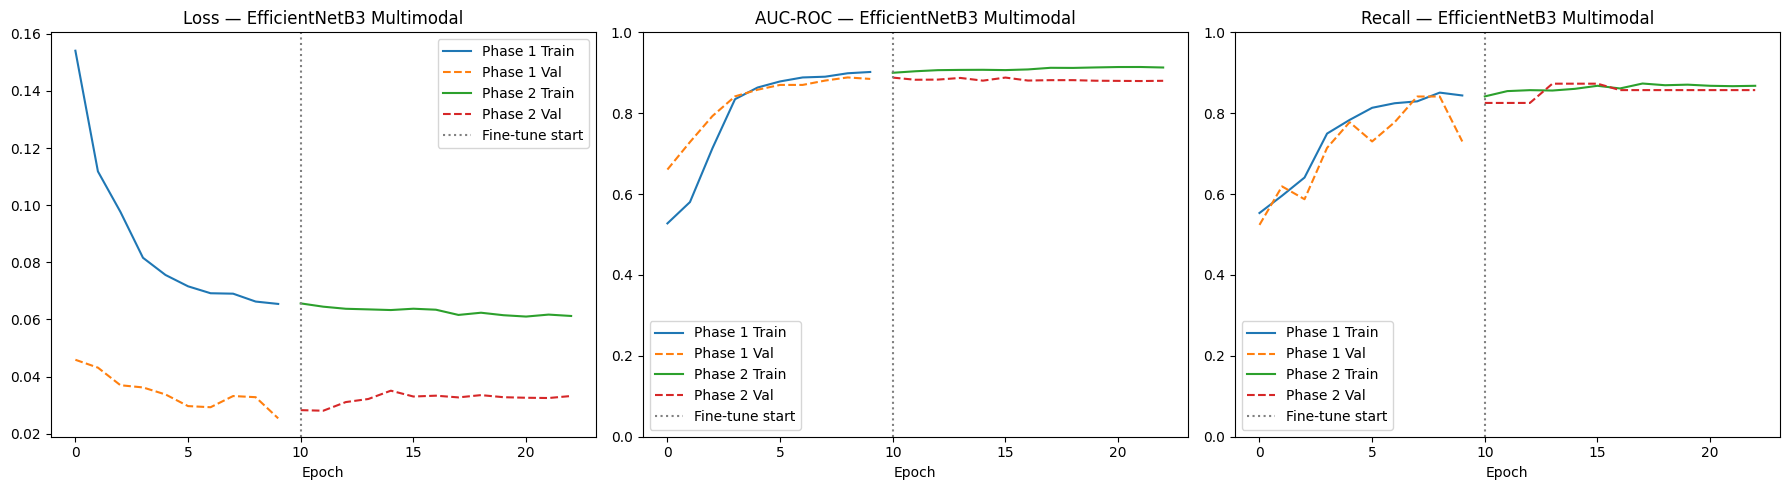

In [41]:
def plot_combined_history(history1, history2=None):
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    # Changed 'accuracy' to 'recall' based on tracked metrics
    metrics = ["loss", "auc", "recall"]
    titles  = ["Loss", "AUC-ROC", "Recall"]

    for i, (ax, metric, title) in enumerate(zip(axes, metrics, titles)):
        # Phase 1
        ax.plot(history1.history[metric],     label="Phase 1 Train")
        ax.plot(history1.history[f"val_{metric}"], label="Phase 1 Val", linestyle="--")

        # Phase 2 (offset epoch index)
        if history2 is not None:
            offset = len(history1.history[metric])
            epochs_p2 = range(offset, offset + len(history2.history[metric]))
            ax.plot(epochs_p2, history2.history[metric], label="Phase 2 Train")
            ax.plot(epochs_p2, history2.history[f"val_{metric}"],
                    label="Phase 2 Val", linestyle="--")
            ax.axvline(x=offset, color="gray", linestyle=":", label="Fine-tune start")

        ax.set_title(f"{title} — EfficientNetB3 Multimodal")
        ax.set_xlabel("Epoch")
        ax.legend()

        # Add y-limit for AUC and Recall
        if metric in ["auc", "recall"]:
            ax.set_ylim([0, 1])

    plt.tight_layout()
    plt.show()

plot_combined_history(history1, history2)


65/65 ━━━━━━━━━━━━━━━━━━━━ 40s 325ms/step
Đang tìm threshold tối ưu...

── THRESHOLD TUNING KẾT QUẢ ──────────────────────────
Threshold tối ưu   : 0.60  (mặc định 0.50)
Recall Malignant   : 0.6203  ← Tỷ lệ phát hiện ung thư
Precision Malignant: 0.2426  ← Độ chính xác khi dự đoán dương
F1 Malignant       : 0.3488  ← Cân bằng recall + precision
Specificity        : 0.9235  ← Tỷ lệ phát hiện đúng Benign
────────────────────────────────────────────────────────

📌 Gợi ý threshold theo mục tiêu:
   - Tối đa recall (không bỏ sót): threshold ≈ 0.05
   - Cân bằng F1               : threshold ≈ 0.60  ← đang dùng
   - Thử: 0.3, 0.4, 0.5 và so sánh kết quả!


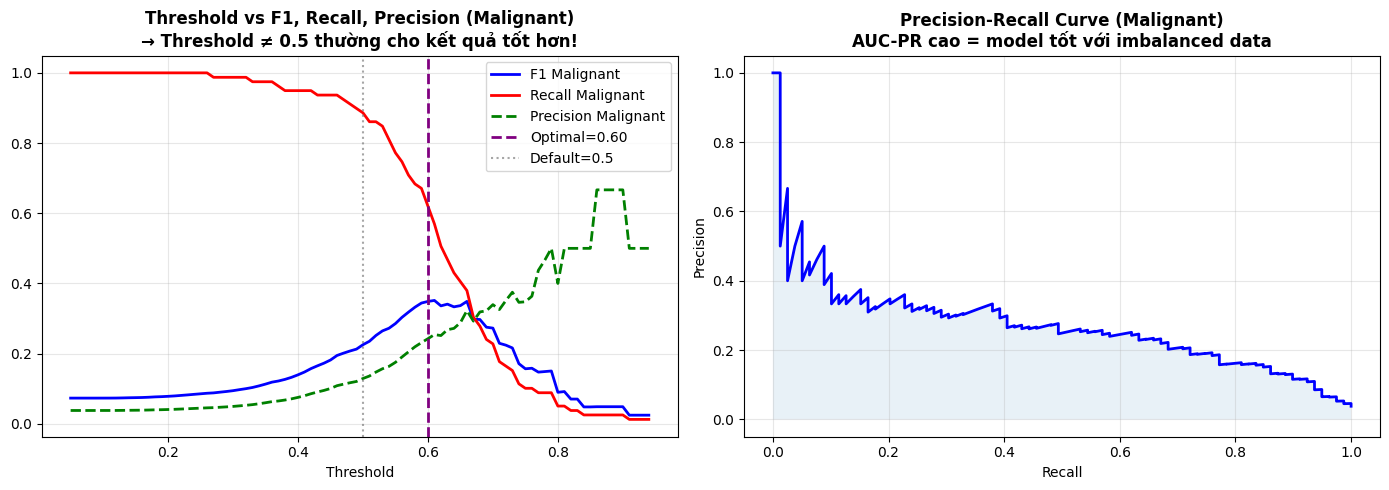


Sử dụng threshold = 0.60

📊 ĐÁNH GIÁ MÔ HÌNH — EfficientNetB3 Multimodal ISIC 2024
  pAUC (TPR≥80%)    : 4.0057  ← Metric chính ISIC 2024
  AUC-ROC           : 0.8921
  Recall Malignant  : 0.6203  ← Tỷ lệ phát hiện ung thư
  F1 Malignant      : 0.3488  ← Cân bằng recall + precision
  Precision Malignant: 0.2426  ← Tránh false alarm
  F1 Macro          : 0.6508
  Threshold         : 0.60
  ✗ Accuracy        : (không hiển thị — vô nghĩa với imbalanced data)

Classification Report:
               precision    recall  f1-score   support

   Benign (0)       0.98      0.92      0.95      2000
Malignant (1)       0.24      0.62      0.35        79

     accuracy                           0.91      2079
    macro avg       0.61      0.77      0.65      2079
 weighted avg       0.96      0.91      0.93      2079



/tmp/ipykernel_889350/3603444584.py:240: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


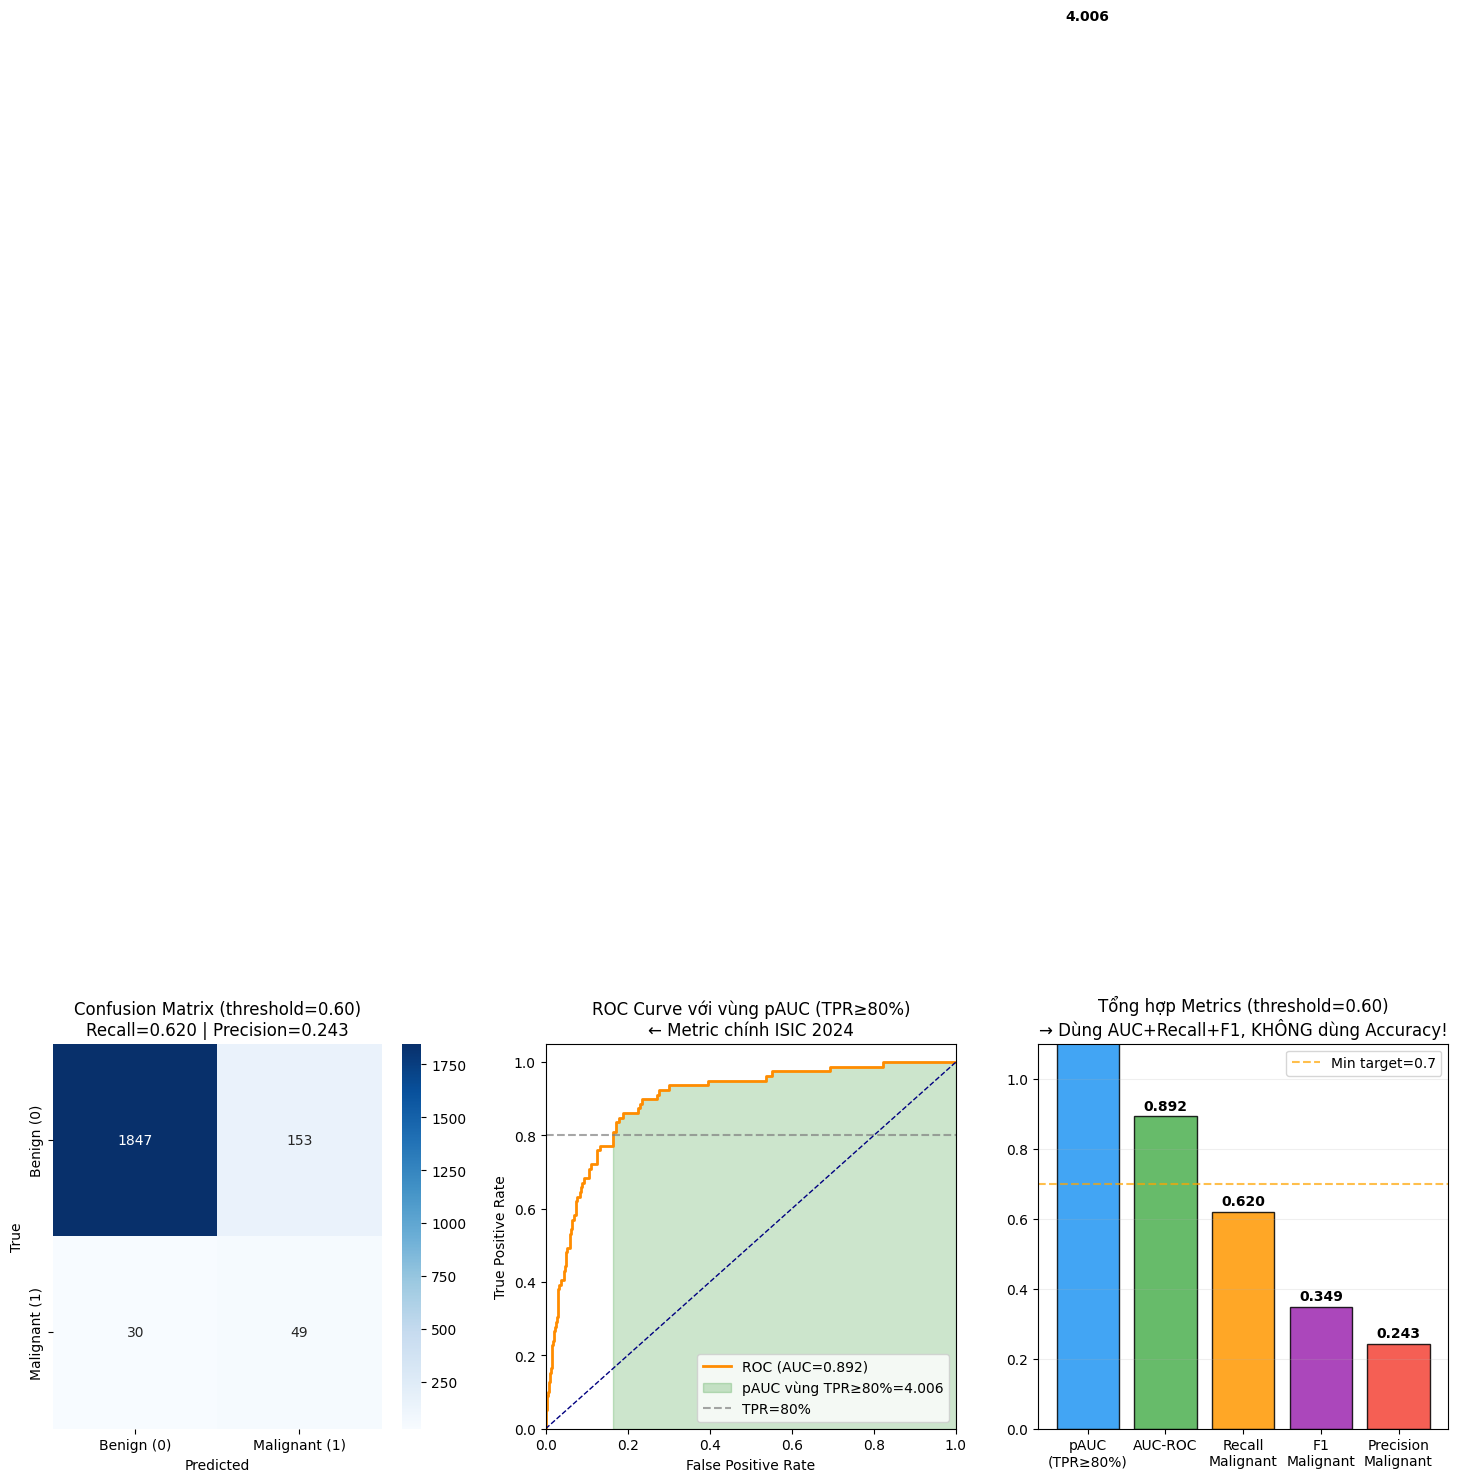


📌 Threshold tối ưu để dùng lại: 0.60
Gợi ý: Giảm threshold xuống 0.2-0.3 nếu cần tăng Recall Malignant cao hơn


In [42]:
if not hasattr(np, 'trapezoid'):
    np.trapezoid = np.trapz

# Đánh giá mô hình trên tập test với Threshold Tuning tự động
# CẢI TIẾN: auto_tune_threshold=True sẽ tìm threshold tối ưu cho Malignant
f1_mal, auc_score, optimal_threshold, pauc_score = evaluate_model(
    model, X_tab_test, X_img_test, y_test, label_encoder,
    auto_tune_threshold=True   # Tắt bằng False nếu muốn dùng threshold=0.5
)

print(f"\n📌 Threshold tối ưu để dùng lại: {optimal_threshold:.2f}")
print("Gợi ý: Giảm threshold xuống 0.2-0.3 nếu cần tăng Recall Malignant cao hơn")

In [43]:
# ============================================================
# PHAN 5: XAI - GIAI THICH MO HINH (Explainable AI)
#  Tương thích hệ thống AI UITIOT (http://172.31.0.40)
#
#  Thư viện đã có sẵn: numpy, matplotlib, tensorflow, scikit-learn
#  Cần cài thêm: shap, grad-cam, saliency
# ============================================================

#  shap chưa có sẵn trên hệ thống AI UITIOT → cần cài
!pip install shap -q
#  grad-cam chưa có sẵn trên hệ thống AI UITIOT → cần cài
!pip install grad-cam -q
#  saliency chưa có sẵn trên hệ thống AI UITIOT → cần cài
!pip install saliency -q

import shap
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print('✅ XAI libraries loaded successfully.')


✅ XAI libraries loaded successfully.


In [44]:
# ============================================================
# 5.1 GRAD-CAM EXPLAINER (IMAGE)
# Compatible với EfficientNetB3 Multimodal trên AI UITIOT
# ============================================================

class GradCAMExplainer:
    def __init__(self, model, last_conv_layer_name):
        self.model = model
        self.last_conv_layer = model.get_layer(last_conv_layer_name)

        # Sub-model: outputs [conv_feature_map, predictions]
        self.grad_model = tf.keras.models.Model(
            inputs=model.inputs,
            outputs=[self.last_conv_layer.output, model.output]
        )

    def compute_heatmap(self, image, tabular, class_idx=None):
        """
        image   : (1, H, W, 3)
        tabular : (1, num_features)
        Thứ tự input: image_input trước, tabular_input sau (theo model UITIOT)
        """
        with tf.GradientTape() as tape:
            conv_outputs, predictions = self.grad_model(
                {'image_input': image, 'tabular_input': tabular}
            )
            if class_idx is None:
                class_idx = tf.argmax(predictions[0])
            loss = predictions[:, class_idx]

        grads       = tape.gradient(loss, conv_outputs)
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
        conv_out    = conv_outputs[0]
        heatmap     = tf.reduce_sum(conv_out * pooled_grads, axis=-1)

        heatmap = tf.maximum(heatmap, 0)
        heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
        return heatmap.numpy()

    def overlay_heatmap(self, heatmap, image, alpha=0.4):
        """Overlay Grad-CAM heatmap lên ảnh gốc."""
        heatmap_r = cv2.resize(heatmap, (image.shape[1], image.shape[0]))
        heatmap_u = np.uint8(255 * heatmap_r)
        heatmap_c = cv2.applyColorMap(heatmap_u, cv2.COLORMAP_JET)
        overlay   = cv2.addWeighted(
            image.astype(np.uint8), 1 - alpha,
            heatmap_c,             alpha, 0
        )
        return overlay


In [45]:
# ============================================================
# 5.2 SHAP METADATA EXPLAINER
# Tương thích tensorflow==2.19.1 / Keras 3.x trên AI UITIOT
# GradientExplainer không có .expected_value → tính thủ công
# ============================================================

import shap

class SHAPMetadataExplainer:
    def __init__(self, model, background_tabular, background_image, feature_names):
        print('Initializing SHAP Explainer (UITIOT mode)...')
        self.feature_names = feature_names

        # Chuẩn hóa background image → (1, H, W, C) numpy float32
        if background_image.ndim == 3:
            background_image = np.expand_dims(background_image, axis=0)
        bg_img = background_image.astype(np.float32)

        self._bg_img     = bg_img
        self._bg_tabular = background_tabular
        self._model      = model

        # ── Wrapper model: chỉ nhận tabular, tile image cố định ──
        # Dùng Functional API với Lambda thay vì named Input
        # để tránh UserWarning 'inputs don't match expected structure'
        tab_inp   = tf.keras.Input(shape=(background_tabular.shape[1],))

        # Capture bg_img trong closure — tránh biến ngoài scope
        _bg = tf.constant(bg_img, dtype=tf.float32)

        def tile_bg(x):
            b = tf.shape(x)[0]
            return tf.tile(_bg, [b, 1, 1, 1])

        img_tiled = tf.keras.layers.Lambda(tile_bg)(tab_inp)
        # Gọi model với dict để tránh positional-arg mismatch
        out = model({'image_input': img_tiled, 'tabular_input': tab_inp})

        self.wrapper_model = tf.keras.Model(inputs=tab_inp, outputs=out)

        # GradientExplainer
        bg_tab_f = background_tabular.astype(np.float32)
        self.explainer = shap.GradientExplainer(self.wrapper_model, bg_tab_f)

        # Tính expected_value thủ công = mean(model(background))
        bg_preds = self.wrapper_model(
            tf.constant(bg_tab_f), training=False
        ).numpy().flatten()
        self._expected_value = float(np.mean(bg_preds))

        print('✅ SHAP GradientExplainer ready.')
        print(f'   E[f(X)] = {self._expected_value:.4f}')

    def explain(self, X):
        return self.explainer.shap_values(X.astype(np.float32))

    def get_expected_value(self):
        """Trả về expected_value Python float — từ background predictions."""
        return self._expected_value


In [46]:
# ============================================================
# 5.3 MULTIMODAL XAI RUNNER
# Điều phối SHAP + Grad-CAM, safe cho AI UITIOT
# ============================================================

class MultimodalXAIRunner:
    def __init__(self, model, background_tabular, background_image,
                 feature_names, last_conv_layer):
        print('Initializing Multimodal XAI Runner...')
        self.model         = model
        self.feature_names = feature_names
        self.shap_explainer = SHAPMetadataExplainer(
            model, background_tabular, background_image, feature_names
        )
        self.gradcam = GradCAMExplainer(model, last_conv_layer)
        print('✅ XAI Ready!')

    def _extract_shap_1d(self, shap_values):
        """Trích xuất SHAP values thành mảng 1D cho 1 sample.
        GradientExplainer trả về list hoặc array — xử lý mọi case.
        """
        sv = shap_values
        if isinstance(sv, list):
            sv = sv[0]           # lấy output đầu tiên
        sv = np.asarray(sv)
        sv = sv.squeeze()        # (1, F) hoặc (1, F, 1) → (F,)
        if sv.ndim == 2:
            sv = sv[:, 0]        # edge case multi-output
        return sv

    def explain(self, tabular_sample, image_sample, visualize=True):
        """
        tabular_sample : (num_features,)
        image_sample   : (H, W, 3)
        """
        tab_exp = np.expand_dims(tabular_sample, axis=0).astype(np.float32)
        img_exp = np.expand_dims(image_sample,   axis=0).astype(np.float32)

        shap_values = self.shap_explainer.explain(tab_exp)
        heatmap     = self.gradcam.compute_heatmap(img_exp, tab_exp)

        results = {'shap_values': shap_values, 'heatmap': heatmap}
        if visualize:
            self.visualize_results(image_sample, heatmap, shap_values, tabular_sample)
        return results

    def visualize_results(self, image, heatmap, shap_values, tabular_sample):
        """Hiển thị Grad-CAM + SHAP Impact bar cạnh nhau."""
        overlay = self.gradcam.overlay_heatmap(heatmap, image)
        sv      = self._extract_shap_1d(shap_values)
        ev      = self.shap_explainer.get_expected_value()

        # Top 10 features
        importance = np.abs(sv)
        top_idx    = np.argsort(importance)[-10:][::-1]
        top_vals   = sv[top_idx]
        top_names  = [self.feature_names[i] for i in top_idx]
        colors     = ['tomato' if v > 0 else 'steelblue' for v in top_vals]

        fig, axes = plt.subplots(1, 2, figsize=(15, 6))

        # Grad-CAM
        axes[0].imshow(overlay)
        axes[0].set_title('Grad-CAM — EfficientNetB3', fontweight='bold')
        axes[0].axis('off')

        # SHAP bar chart
        axes[1].barh(top_names[::-1], top_vals[::-1], color=colors[::-1])
        axes[1].axvline(0, color='black', linewidth=0.8)
        axes[1].set_title(
            f'SHAP Feature Impact (Top 10)\nE[f(X)] = {ev:.4f}',
            fontweight='bold'
        )
        axes[1].set_xlabel('SHAP value  (🔴 tăng / 🔵 giảm nguy cơ)')

        plt.suptitle('XAI — Multimodal Skin Lesion Explanation',
                     fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.show()


Initializing Multimodal XAI Runner...
Initializing SHAP Explainer (UITIOT mode)...
✅ SHAP GradientExplainer ready.
   E[f(X)] = 0.3865
✅ XAI Ready!


/opt/tljh/user/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_405
Received: inputs=['Tensor(shape=(1, 37))']
  warnings.warn(msg)
/opt/tljh/user/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_405
Received: inputs=['Tensor(shape=(50, 37))']
  warnings.warn(msg)
/tmp/ipykernel_889350/3415356396.py:78: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_889350/3415356396.py:78: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/tljh/user/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/tljh/use

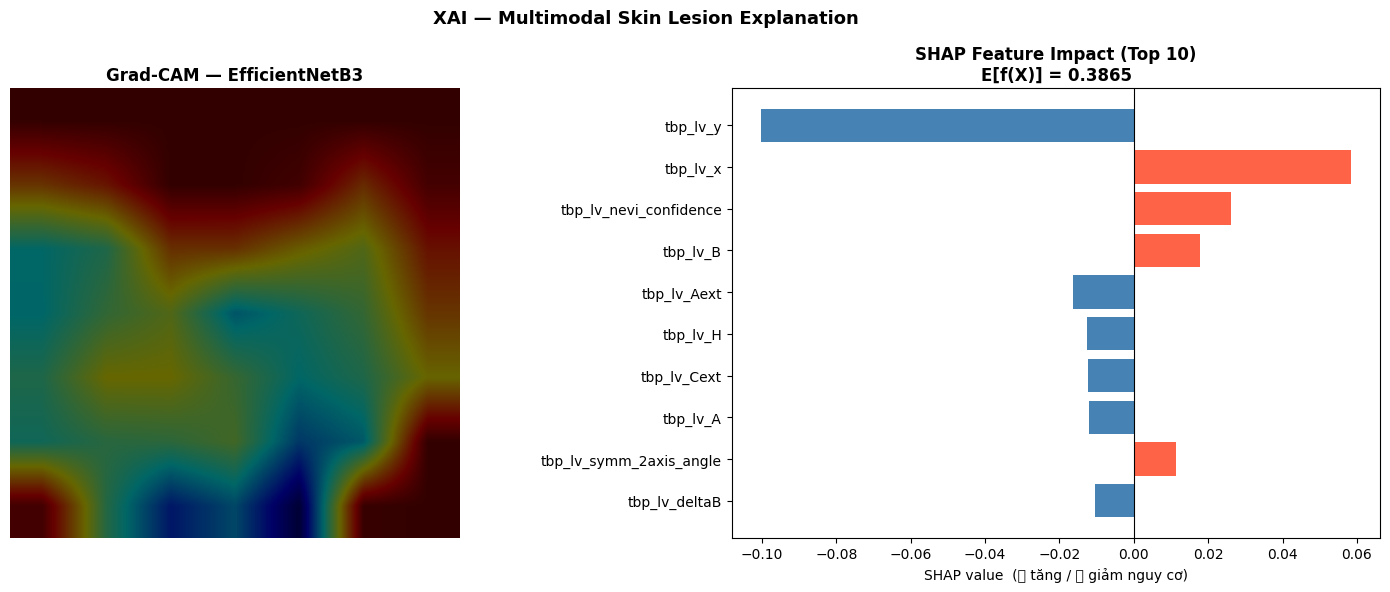

In [47]:
import numpy as np

# Define background_tabular and background_image for XAI explainers
# Using a small subset of training data for background reference
background_tabular_samples = 10 # Adjust as needed for performance vs accuracy trade-off
background_tabular = X_tab_train[np.random.choice(X_tab_train.shape[0], background_tabular_samples, replace=False)]
background_image = X_img_train[0] # Use a single representative image

# Recreate the full list of tabular columns used during model training
label_col = 'target'
id_col = 'isic_id'

exclude_cols = [label_col, id_col, 'patient_id', 'attribution', 'copyright_license',
                'image_type', 'iddx_full', 'iddx_1', 'iddx_2', 'iddx_3', 'iddx_4',
                'iddx_5', 'mel_mitotic_index', 'mel_thick_mm', 'lesion_id']

# Get numeric columns from df_subset (the filtered DataFrame used for X_tabular creation)
numeric_cols_from_subset = df_subset.select_dtypes(include=np.number).columns.tolist()
full_tabular_columns = [col for col in numeric_cols_from_subset if col not in exclude_cols]

# Add categorical columns that were encoded and used in X_tabular
cat_cols_for_tabular = ['sex', 'anatom_site_general']
for col in cat_cols_for_tabular:
    # Only add if not already present and is a column in the original df_subset
    if col in df_subset.columns and col not in full_tabular_columns:
        full_tabular_columns.append(col)

# Define feature_names from the list of tabular columns used in data preparation
feature_names = full_tabular_columns

xai_runner = MultimodalXAIRunner(
    model=model,
    background_tabular=background_tabular,
    background_image=background_image,
    feature_names=feature_names,
    last_conv_layer=last_conv
)

result = xai_runner.explain(
    X_tab_train[0],
    X_img_train[0]
)

Đang giải thích mẫu index: 0


2026-05-07 03:06:55.083546: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 03:06:55.162164: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 03:06:55.545939: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 03:06:55.648939: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 03:06:56.737680: E external/local_xla/xla/stream_

1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/step
Prediction: [[0.32678917]]
Predicted class: 0 | Confidence: 0.3268


/tmp/ipykernel_889350/3415356396.py:78: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_889350/3415356396.py:78: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


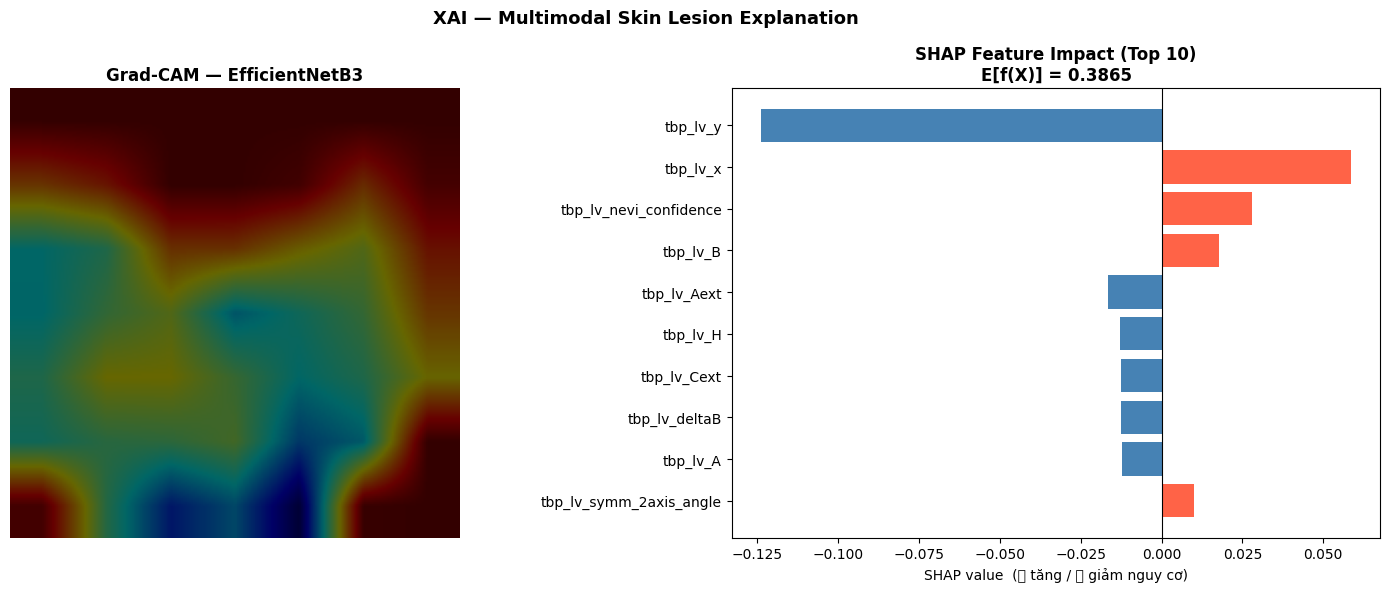

XAI hoàn tất!


In [48]:
# ===== Chọn 1 mẫu từ tập train/test =====
sample_idx = 0   # bạn có thể đổi index

tab_sample = X_tab_train[sample_idx]
img_sample = X_img_train[sample_idx]

print(f"Đang giải thích mẫu index: {sample_idx}")

# ===== Dự đoán model =====
tab_input = np.expand_dims(tab_sample, axis=0)
img_input = np.expand_dims(img_sample, axis=0)

prediction = model.predict({
    'image_input': img_input,
    'tabular_input': tab_input
})

print("Prediction:", prediction)

# Nếu là binary classification
if prediction.shape[-1] == 1:
    confidence = float(prediction[0][0])
    pred_class = int(confidence > 0.5)
else:
    pred_class = int(np.argmax(prediction[0]))
    confidence = float(np.max(prediction[0]))

print(f"Predicted class: {pred_class} | Confidence: {confidence:.4f}")


# ===== Chạy XAI =====
result = xai_runner.explain(
    tab_sample,
    img_sample,
    visualize=True   # bật hiển thị
)

print("XAI hoàn tất!")

In [49]:
#Hiển thị top feature SHAP
shap_values = result["shap_values"][0][0]

# Lấy top 10 feature quan trọng nhất
importance = np.abs(shap_values)
top_idx = np.argsort(importance)[-10:][::-1]

print("\nTop 10 features quan trọng:")
for i in top_idx:
    print(f"{feature_names[i]}: {shap_values[i]:.4f}")


Top 10 features quan trọng:
age_approx: 0.0023


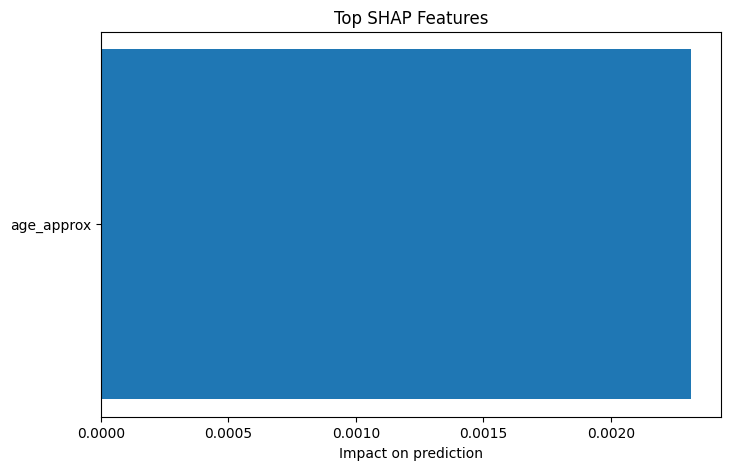

In [50]:
#Vẽ biểu đồ SHAP đẹp hơn
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

values = shap_values[top_idx]
names = [feature_names[i] for i in top_idx]

plt.barh(names, values)
plt.gca().invert_yaxis()
plt.title("Top SHAP Features")
plt.xlabel("Impact on prediction")

plt.show()

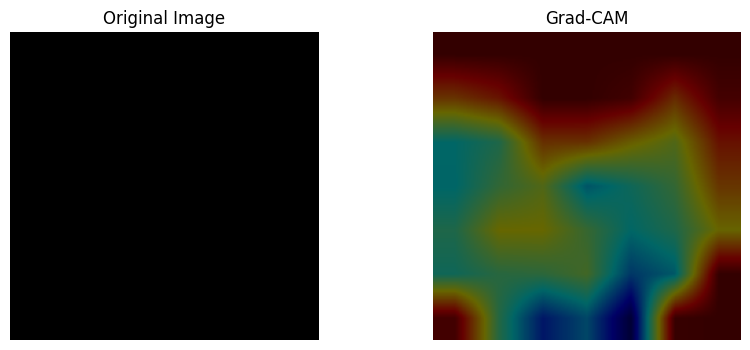

In [51]:
#Hiển thị ảnh gốc + heatmap rõ hơn
heatmap = result["heatmap"]

overlay = xai_runner.gradcam.overlay_heatmap(heatmap, img_sample)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img_sample.astype(np.uint8))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(overlay)
plt.title("Grad-CAM")
plt.axis("off")

plt.show()

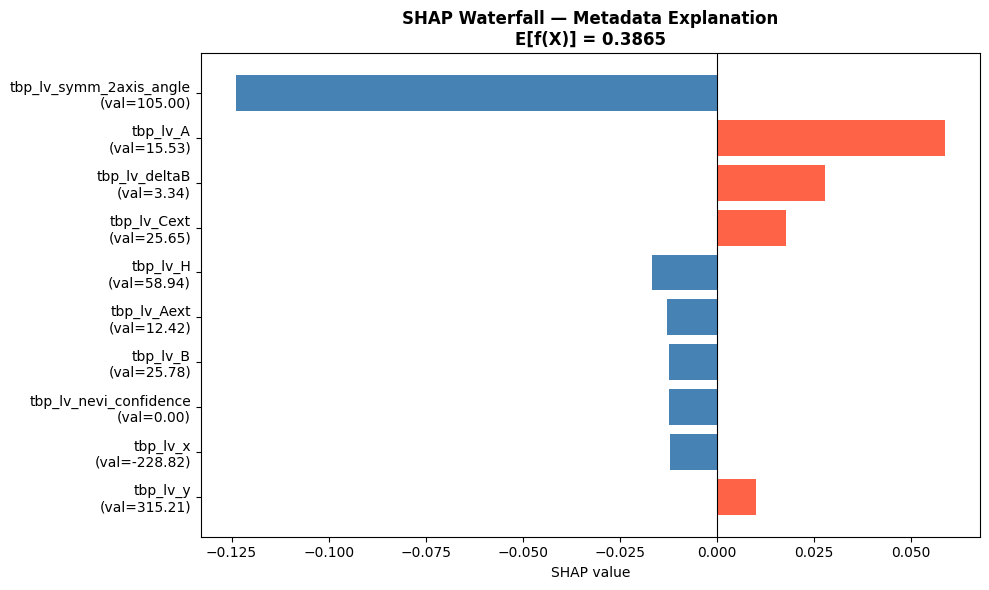

In [52]:
#============================================================
# 5.6 SHAP WATERFALL PLOT CHI TIẾT (METADATA)
# Fix: dùng get_expected_value() an toàn cho AI UITIOT TF2.19
#============================================================

shap_values = result['shap_values']
ev          = xai_runner.shap_explainer.get_expected_value()

# Trích shap_val_sample (1D)
if isinstance(shap_values, list):
    shap_val_sample = np.asarray(shap_values[0]).squeeze()
else:
    shap_val_sample = np.asarray(shap_values).squeeze()

# Waterfall dùng matplotlib thủ công (an toàn hơn shap.plots.waterfall trên UITIOT)
top_n   = 10
top_idx = np.argsort(np.abs(shap_val_sample))[-top_n:][::-1]
vals    = shap_val_sample[top_idx]
names   = [feature_names[i] for i in top_idx]
data    = X_tab_train[sample_idx][top_idx]

colors = ['tomato' if v > 0 else 'steelblue' for v in vals]

plt.figure(figsize=(10, 6))
plt.barh(
    [f'{n}\n(val={v:.2f})' for n, v in zip(names, data)],
    vals[::-1], color=colors[::-1]
)
plt.axvline(0, color='black', linewidth=0.8)
plt.title(f'SHAP Waterfall — Metadata Explanation\nE[f(X)] = {ev:.4f}',
          fontweight='bold')
plt.xlabel('SHAP value')
plt.tight_layout()
plt.show()


In [53]:
#In ra giải thích dạng text (giống báo cáo)
print("\n=== GIAI THICH CHI TIET ===")

for i in np.argsort(np.abs(shap_val_sample))[::-1][:10]:
    impact = shap_val_sample[i]
    name = feature_names[i]

    if impact > 0:
        direction = "TANG nguy co"
    else:
        direction = "GIAM nguy co"

    print(f"{name}: {impact:.4f} -> {direction}")


=== GIAI THICH CHI TIET ===
tbp_lv_y: -0.1238 -> GIAM nguy co
tbp_lv_x: 0.0586 -> TANG nguy co
tbp_lv_nevi_confidence: 0.0279 -> TANG nguy co
tbp_lv_B: 0.0177 -> TANG nguy co
tbp_lv_Aext: -0.0166 -> GIAM nguy co
tbp_lv_H: -0.0129 -> GIAM nguy co
tbp_lv_Cext: -0.0125 -> GIAM nguy co
tbp_lv_deltaB: -0.0124 -> GIAM nguy co
tbp_lv_A: -0.0121 -> GIAM nguy co
tbp_lv_symm_2axis_angle: 0.0100 -> TANG nguy co


In [54]:
#Tự động tạo câu giải thích giống paper
explanations = []

for i in np.argsort(np.abs(shap_val_sample))[::-1][:5]:
    name = feature_names[i]
    value = X_tab_train[0][i]
    impact = shap_val_sample[i]

    if impact > 0:
        explanations.append(f"{name} = {value} lam tang nguy co")
    else:
        explanations.append(f"{name} = {value} lam giam nguy co")

print("\nMo ta tu dong:")
print(" + ".join(explanations))


Mo ta tu dong:
tbp_lv_y = 315.20782470703125 lam giam nguy co + tbp_lv_x = -228.82257080078125 lam tang nguy co + tbp_lv_nevi_confidence = 0.0005741576896980405 lam tang nguy co + tbp_lv_B = 25.782506942749023 lam tang nguy co + tbp_lv_Aext = 12.423074722290039 lam giam nguy co


Đang tính SHAP trên 50 samples...


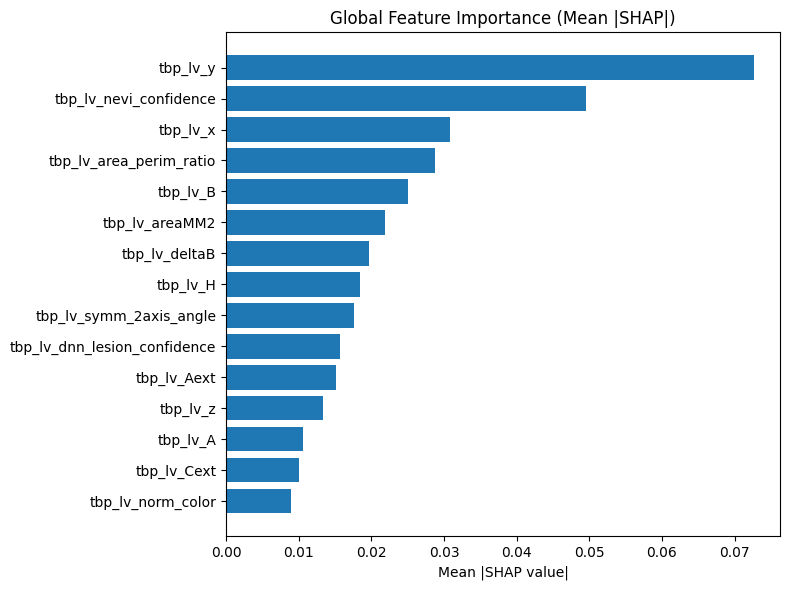

In [55]:
#============================================================
#5.7 SHAP BAR SUMMARY (GLOBAL IMPORTANCE)
#===================================
# ===== Chọn tập dữ liệu để phân tích (test hoặc validation) =====
#  Nên lấy 50–200 samples để tránh SHAP quá chậm
N_SAMPLES = min(50, len(X_tab_train))

indices = np.random.choice(len(X_tab_train), N_SAMPLES, replace=False)
X_sample = X_tab_train[indices]

print(f"Đang tính SHAP trên {N_SAMPLES} samples...")

# ===== Tính SHAP values =====
shap_values = xai_runner.shap_explainer.explain(X_sample)

# ===== Xử lý output (binary vs multi-class) =====
if isinstance(shap_values, list):
    # For single-output models, shap_values is a list of one (N, F, 1) array
    shap_vals = shap_values[0]
else:
    # Fallback if shap_values is already an array, although less likely for DeepExplainer
    shap_vals = shap_values

# ===== Tính Mean |SHAP| =====
# Ensure shap_vals is correctly shaped for mean calculation
# If shap_vals is (N_SAMPLES, num_features, 1), mean over axis 0 results in (num_features, 1)
mean_abs_shap = np.mean(np.abs(shap_vals), axis=0)

# ===== Sắp xếp feature theo độ quan trọng =====
# Squeeze mean_abs_shap to make it 1D before argsort
sorted_idx = np.argsort(mean_abs_shap.squeeze())[::-1]

top_k = 15
top_idx = sorted_idx[:top_k]

top_features = [feature_names[i] for i in top_idx]
top_values = mean_abs_shap[top_idx].squeeze() # Also squeeze top_values for consistent dimensionality

# ===== Vẽ biểu đồ Bar =====
plt.figure(figsize=(8, 6))

plt.barh(top_features, top_values)
plt.gca().invert_yaxis()

plt.title("Global Feature Importance (Mean |SHAP|)")
plt.xlabel("Mean |SHAP value|")

plt.tight_layout()
plt.show()

Selected samples: [np.int64(9), np.int64(23), np.int64(0)]


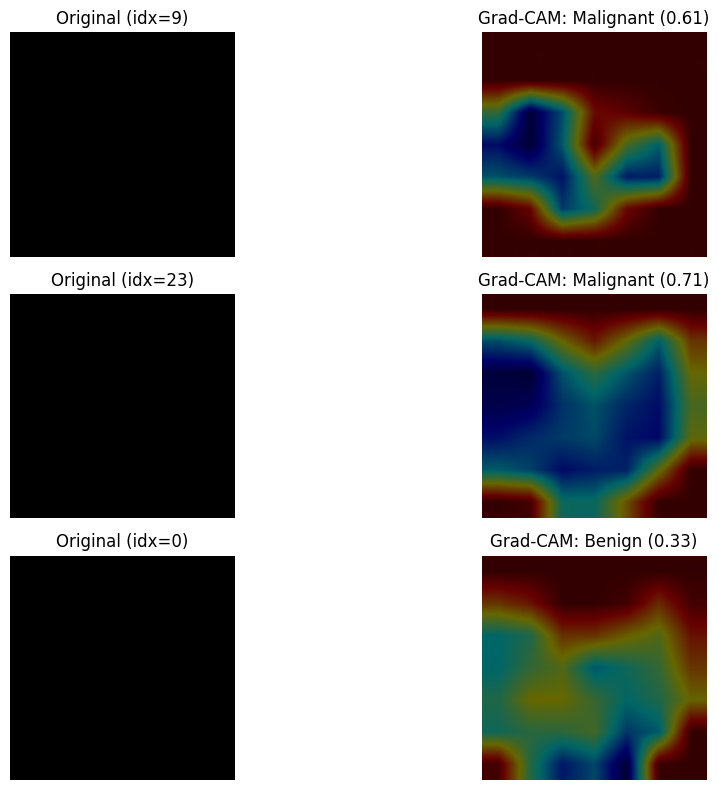

In [58]:
#============================================================
#5.8 SO SÁNH GRAD-CAM TRÊN 3 MẪU (MALIGNANT vs BENIGN)
#===========================================
# ===== Hàm lấy prediction + class =====
# ===== Hàm lấy prediction + class =====
def predict_sample(model, tab, img):
    tab = np.expand_dims(tab, axis=0)
    img = np.expand_dims(img, axis=0)

    pred = model.predict({
        'image_input': img,
        'tabular_input': tab
    }, verbose=0)

    # ===== Binary classification =====
    if pred.shape[-1] == 1:
        conf = float(pred[0][0])   # lấy scalar
        cls = int(conf > 0.5)

    # ===== Multi-class classification =====
    else:
        cls = int(np.argmax(pred[0]))
        conf = float(np.max(pred[0]))

    return cls, conf


# ===== Chọn 3 mẫu: 2 malignant + 1 benign (ví dụ) =====
malignant_indices = np.where(y_train == 1)[0]
benign_indices    = np.where(y_train == 0)[0]

idx_1 = malignant_indices[0]
idx_2 = malignant_indices[1]
idx_3 = benign_indices[0]

sample_indices = [idx_1, idx_2, idx_3]

print("Selected samples:", sample_indices)


# ===== Vẽ so sánh =====
plt.figure(figsize=(12, 8))

for i, idx in enumerate(sample_indices):
    tab = X_tab_train[idx]
    img = X_img_train[idx]

    # Predict
    pred_class, conf = predict_sample(model, tab, img)

    # Grad-CAM
    tab_input = np.expand_dims(tab, axis=0)
    img_input = np.expand_dims(img, axis=0)

    heatmap = xai_runner.gradcam.compute_heatmap(img_input, tab_input)
    overlay = xai_runner.gradcam.overlay_heatmap(heatmap, img)

    # ===== Plot =====
    plt.subplot(3, 2, i*2 + 1)
    plt.imshow(img.astype(np.uint8))
    plt.title(f"Original (idx={idx})")
    plt.axis("off")

    plt.subplot(3, 2, i*2 + 2)
    plt.imshow(overlay)
    label_name = "Malignant" if pred_class == 1 else "Benign"
    plt.title(f"Grad-CAM: {label_name} ({conf:.2f})")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 📊 Phần 6: Data Drift Detection
> **Tại sao cần Data Drift trong pipeline ISIC 2024?**  
> - Dataset thu thập từ nhiều cơ sở y tế → thiết bị dermatoscope khác nhau → ảnh drift  
> - Phân phối tuổi/giới tính/vị trí tổn thương thay đổi theo dân số bệnh nhân  
> - Tỷ lệ Malignant (~3%) có thể thay đổi theo mùa hoặc cơ sở triển khai  
>
> | Module | Chức năng |
> |--------|-----------|
> | 6.1 Cài đặt & Import | Thư viện drift detection |
> | 6.2 Baseline Profile | Lưu phân phối training data làm tham chiếu |
> | 6.3 PSI Calculator | Population Stability Index cho tabular features |
> | 6.4 Statistical Tests | KS-test, Wasserstein cho từng feature |
> | 6.5 Image Drift | Pixel-level và embedding-based drift detection |
> | 6.6 Prediction Drift | Giám sát phân phối confidence scores |
> | 6.7 Drift Dashboard | Báo cáo tổng hợp + alert system |
> | 6.8 Pre-training Check | Kiểm tra drift TRƯỚC khi huấn luyện |
> | 6.9 Post-training Check | So sánh train vs test distribution |


In [59]:
# ============================================================
# PHẦN 6.1: CÀI ĐẶT THƯ VIỆN DATA DRIFT
#  scipy đã có sẵn trên AI UITIOT — KHÔNG cần cài lại
#  evidently cần cài để tạo dashboard HTML
# ============================================================

#  evidently chưa có sẵn → cần cài
!pip install evidently==0.4.30 -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import ks_2samp, wasserstein_distance
import warnings, json, os
from datetime import datetime

warnings.filterwarnings('ignore')
print('✅ Data Drift libraries loaded.')
print('   scipy     : OK (built-in AI UITIOT)')
print('   evidently : OK')


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress t

In [60]:
# ============================================================
# PHẦN 6.2: BASELINE PROFILE — LƯU PHÂN PHỐI TRAINING DATA
# ============================================================

def save_baseline_profile(X_tab, feature_names, y, pred_probs=None,
                           save_path='baseline_profile.json'):
    """
    Lưu thống kê phân phối training data làm baseline tham chiếu.
    Gọi 1 lần duy nhất sau prepare_multimodal_data(), trước khi train.
    """
    profile = {
        'created_at'    : datetime.utcnow().isoformat(),
        'n_samples'     : int(len(y)),
        'n_features'    : int(X_tab.shape[1]),
        'feature_names' : list(feature_names),
        'label_stats'   : {
            'n_benign'      : int((y == 0).sum()),
            'n_malignant'   : int((y == 1).sum()),
            'malignant_rate': float((y == 1).mean()),
        },
        'feature_stats'   : {},
        'prediction_stats': None,
    }
    for i, fname in enumerate(feature_names):
        col = X_tab[:, i]
        profile['feature_stats'][fname] = {
            'mean'  : float(np.nanmean(col)),
            'std'   : float(np.nanstd(col)),
            'median': float(np.nanmedian(col)),
            'p5'    : float(np.nanpercentile(col,  5)),
            'p95'   : float(np.nanpercentile(col, 95)),
            'hist_counts': np.histogram(col[~np.isnan(col)], bins=20)[0].tolist(),
            'hist_edges' : np.histogram(col[~np.isnan(col)], bins=20)[1].tolist(),
        }
    if pred_probs is not None:
        profile['prediction_stats'] = {
            'mean_prob'     : float(np.mean(pred_probs)),
            'malignant_rate': float((pred_probs >= 0.5).mean()),
            'hist_counts'   : np.histogram(pred_probs, bins=20, range=(0,1))[0].tolist(),
        }
    with open(save_path, 'w') as f:
        json.dump(profile, f, indent=2)
    print(f'✅ Baseline profile → {save_path}')
    print(f'   Samples   : {profile["n_samples"]:,}')
    print(f'   Features  : {profile["n_features"]}')
    print(f'   Malignant : {profile["label_stats"]["n_malignant"]:,} '
          f'({profile["label_stats"]["malignant_rate"]*100:.2f}%)')
    return profile


def load_baseline_profile(path='baseline_profile.json'):
    with open(path) as f:
        profile = json.load(f)
    print(f'✅ Baseline loaded: {profile["n_samples"]:,} samples, '
          f'{profile["n_features"]} features')
    return profile


In [61]:
# ============================================================
# PHẦN 6.3: POPULATION STABILITY INDEX (PSI)
# Ngưỡng: PSI<0.10 🟢 | 0.10-0.25 🟡 | >=0.25 🔴
# ============================================================

def compute_psi(baseline_arr, current_arr, bins=10, eps=1e-8):
    combined = np.concatenate([baseline_arr, current_arr])
    combined = combined[~np.isnan(combined)]
    edges    = np.unique(np.percentile(combined, np.linspace(0, 100, bins + 1)))
    if len(edges) < 2:
        return 0.0
    base_cnt, _ = np.histogram(baseline_arr[~np.isnan(baseline_arr)], bins=edges)
    curr_cnt, _ = np.histogram(current_arr[~np.isnan(current_arr)],   bins=edges)
    base_pct = base_cnt / (base_cnt.sum() + eps) + eps
    curr_pct = curr_cnt / (curr_cnt.sum() + eps) + eps
    return float(np.sum((curr_pct - base_pct) * np.log(curr_pct / base_pct)))


def psi_severity(psi_val):
    if psi_val < 0.10:
        return '🟢 Bình thường', 'green'
    elif psi_val < 0.25:
        return '🟡 Cần theo dõi', 'orange'
    return '🔴 Drift nghiêm trọng', 'red'


def compute_all_psi(X_tab_baseline, X_tab_current, feature_names):
    rows = []
    for i, fname in enumerate(feature_names):
        psi_val = compute_psi(X_tab_baseline[:, i], X_tab_current[:, i])
        sev, _  = psi_severity(psi_val)
        rows.append({'feature': fname, 'psi': round(psi_val, 4), 'severity': sev})
    return pd.DataFrame(rows).sort_values('psi', ascending=False).reset_index(drop=True)


def plot_psi_heatmap(df_psi, top_n=20, title='PSI — Feature Drift Overview'):
    df_top = df_psi.head(top_n).copy()
    fig, axes = plt.subplots(1, 2, figsize=(16, max(5, top_n * 0.4)),
                              gridspec_kw={'width_ratios': [3, 1]})
    colors = ['red' if p >= 0.25 else 'orange' if p >= 0.10 else 'green'
              for p in df_top['psi']]
    axes[0].barh(df_top['feature'][::-1], df_top['psi'][::-1], color=colors[::-1])
    axes[0].axvline(0.10, color='orange', linestyle='--', linewidth=1.5, label='PSI=0.10')
    axes[0].axvline(0.25, color='red',    linestyle='--', linewidth=1.5, label='PSI=0.25')
    axes[0].set_xlabel('PSI Value')
    axes[0].set_title(title, fontweight='bold')
    axes[0].legend()
    counts = df_psi['severity'].value_counts()
    pie_colors = {'🟢 Bình thường': 'green', '🟡 Cần theo dõi': 'orange',
                  '🔴 Drift nghiêm trọng': 'red'}
    c = [pie_colors.get(k, 'gray') for k in counts.index]
    axes[1].pie(counts.values, labels=counts.index, colors=c,
                autopct='%1.0f%%', startangle=90, textprops={'fontsize': 8})
    axes[1].set_title('Phân phối mức độ')
    plt.tight_layout()
    plt.show()
    print(f'\nTổng hợp PSI ({len(df_psi)} features):')
    print(f'  🟢 Bình thường      : {(df_psi["psi"] < 0.10).sum()}')
    print(f'  🟡 Cần theo dõi     : {((df_psi["psi"]>=0.10)&(df_psi["psi"]<0.25)).sum()}')
    print(f'  🔴 Drift nghiêm trọng: {(df_psi["psi"] >= 0.25).sum()}')
    return df_psi


In [62]:
# ============================================================
# PHẦN 6.4: STATISTICAL TESTS — KS-test + Wasserstein
# scipy.stats đã có sẵn trên AI UITIOT
# ============================================================

def run_statistical_tests(X_tab_baseline, X_tab_current, feature_names,
                           alpha=0.05, top_n=15):
    results = []
    for i, fname in enumerate(feature_names):
        base = X_tab_baseline[:, i]
        curr = X_tab_current[:, i]
        base = base[~np.isnan(base)]
        curr = curr[~np.isnan(curr)]
        ks_stat, ks_p = ks_2samp(base, curr)
        w_dist        = wasserstein_distance(base, curr)
        drift_flag    = bool(ks_p < alpha)
        results.append({
            'feature'    : fname,
            'ks_stat'    : round(float(ks_stat), 4),
            'ks_pvalue'  : round(float(ks_p), 4),
            'wasserstein': round(float(w_dist), 4),
            'drift'      : drift_flag,
            'status'     : '🔴 Drift' if drift_flag else '🟢 OK',
        })
    df_stat = pd.DataFrame(results).sort_values('ks_stat', ascending=False).reset_index(drop=True)
    n_drift = df_stat['drift'].sum()
    print(f'\n📊 KẾT QUẢ STATISTICAL TESTS (alpha={alpha})')
    print(f'   Tổng features  : {len(df_stat)}')
    print(f'   Features drift : {n_drift} ({n_drift/len(df_stat)*100:.1f}%)')
    df_top = df_stat.head(top_n)
    colors  = ['red' if d else 'steelblue' for d in df_top['drift']]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].barh(df_top['feature'][::-1], df_top['ks_stat'][::-1], color=colors[::-1])
    axes[0].set_title(f'KS Statistic — Top {top_n}', fontweight='bold')
    axes[0].set_xlabel('KS Statistic')
    axes[1].barh(df_top['feature'][::-1], df_top['wasserstein'][::-1], color=colors[::-1])
    axes[1].set_title(f'Wasserstein Distance — Top {top_n}', fontweight='bold')
    axes[1].set_xlabel('Wasserstein Distance')
    plt.suptitle('Statistical Tests — Train vs Current Distribution', fontweight='bold')
    plt.tight_layout()
    plt.show()
    return df_stat


def plot_feature_drift_detail(X_tab_baseline, X_tab_current, feature_names,
                               top_features=None, n_cols=3):
    if top_features is None:
        top_features = list(feature_names[:12])
    n_rows = (len(top_features) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 3.5*n_rows))
    axes = np.array(axes).flatten()
    for idx, fname in enumerate(top_features):
        fi   = list(feature_names).index(fname)
        base = X_tab_baseline[:, fi]; base = base[~np.isnan(base)]
        curr = X_tab_current[:, fi];  curr = curr[~np.isnan(curr)]
        ks_stat, ks_p = ks_2samp(base, curr)
        psi_val = compute_psi(base, curr)
        ax = axes[idx]
        ax.hist(base, bins=30, alpha=0.5, color='steelblue', density=True, label='Baseline (Train)')
        ax.hist(curr, bins=30, alpha=0.5, color='tomato',    density=True, label='Current (Test)')
        color = 'red' if ks_p < 0.05 else 'green'
        ax.set_title(f'{fname}\nKS p={ks_p:.3f}  PSI={psi_val:.3f}',
                     fontsize=9, color=color, fontweight='bold')
        ax.legend(fontsize=7)
    for j in range(idx+1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Feature Distribution: Baseline vs Current', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


In [63]:
# ============================================================
# PHẦN 6.5: IMAGE DRIFT DETECTION
# A) Pixel-level statistics (nhanh, không cần GPU)
# B) Embedding-based drift (dùng EfficientNetB3)
# ============================================================

def detect_image_pixel_drift(X_img_baseline, X_img_current, alpha=0.05):
    """So sánh phân phối pixel theo từng channel R, G, B bằng KS-test."""
    channel_names = ['Red', 'Green', 'Blue']
    results = {}
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for c, cname in enumerate(channel_names):
        base_px = X_img_baseline[:, :, :, c].flatten()
        curr_px = X_img_current[:, :, :, c].flatten()
        n_samp  = min(10000, len(base_px), len(curr_px))
        base_s  = np.random.choice(base_px, n_samp, replace=False)
        curr_s  = np.random.choice(curr_px, n_samp, replace=False)
        ks_stat, ks_p = ks_2samp(base_s, curr_s)
        w_dist        = wasserstein_distance(base_s, curr_s)
        drift_flag    = bool(ks_p < alpha)
        results[cname] = {'ks_stat': round(float(ks_stat),4),
                           'ks_pvalue': round(float(ks_p),4),
                           'wasserstein': round(float(w_dist),4),
                           'drift': drift_flag}
        ax = axes[c]
        ax.hist(base_s, bins=50, alpha=0.5, color='steelblue', density=True, label='Baseline')
        ax.hist(curr_s, bins=50, alpha=0.5, color='tomato',    density=True, label='Current')
        color = 'red' if drift_flag else 'green'
        ax.set_title(f'{cname}\nKS p={ks_p:.3f}  W={w_dist:.4f}', color=color, fontweight='bold')
        ax.legend(fontsize=8)
        ax.set_xlabel('Pixel intensity [0,1]')
    plt.suptitle('Image Pixel Drift — Baseline vs Current', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print('\n📊 Image Pixel Drift Results:')
    for cname, r in results.items():
        status = '🔴 Drift' if r['drift'] else '🟢 OK'
        print(f'   {cname}: KS={r["ks_stat"]:.4f}  p={r["ks_pvalue"]:.4f}  '
              f'W={r["wasserstein"]:.4f}  {status}')
    return results


def compute_embedding_drift(model, X_img_baseline, X_img_current,
                             X_tab_baseline, X_tab_current,
                             layer_name='global_average_pooling2d', n_sample=200):
    """
    Embedding-based drift: trích xuất GlobalAveragePooling của EfficientNetB3,
    so sánh bằng MMD (Maximum Mean Discrepancy).
    """
    print(f'\n🔍 Extracting embeddings from layer "{layer_name}" ...')
    try:
        emb_model = tf.keras.Model(inputs=model.inputs,
                                    outputs=model.get_layer(layer_name).output)
    except ValueError:
        pool_layers = [l.name for l in model.layers if 'pool' in l.name.lower()]
        if pool_layers:
            layer_name = pool_layers[0]
            emb_model  = tf.keras.Model(inputs=model.inputs,
                                         outputs=model.get_layer(layer_name).output)
        else:
            print('  ⚠️ Không tìm thấy pooling layer, bỏ qua embedding drift')
            return None

    n_b  = min(n_sample, len(X_img_baseline))
    n_c  = min(n_sample, len(X_img_current))
    idx_b = np.random.choice(len(X_img_baseline), n_b, replace=False)
    idx_c = np.random.choice(len(X_img_current),  n_c, replace=False)
    emb_b = emb_model.predict(
        {'image_input': X_img_baseline[idx_b], 'tabular_input': X_tab_baseline[idx_b]},
        verbose=0, batch_size=32)
    emb_c = emb_model.predict(
        {'image_input': X_img_current[idx_c], 'tabular_input': X_tab_current[idx_c]},
        verbose=0, batch_size=32)

    def rbf(X, Y, sigma=1.0):
        XY = np.dot(X, Y.T)
        X2 = (X**2).sum(axis=1, keepdims=True)
        Y2 = (Y**2).sum(axis=1, keepdims=True)
        return np.exp(-(X2 + Y2.T - 2*XY) / (2*sigma**2))

    mmd = float(rbf(emb_b,emb_b).mean() + rbf(emb_c,emb_c).mean() - 2*rbf(emb_b,emb_c).mean())

    from sklearn.decomposition import PCA
    all_emb = np.vstack([emb_b, emb_c])
    all_2d  = PCA(n_components=2).fit_transform(all_emb)
    b2d, c2d = all_2d[:n_b], all_2d[n_b:]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].scatter(b2d[:,0], b2d[:,1], alpha=0.4, s=20, color='steelblue', label='Baseline')
    axes[0].scatter(c2d[:,0], c2d[:,1], alpha=0.4, s=20, color='tomato',    label='Current')
    axes[0].set_title(f'Embedding PCA 2D  |  MMD={mmd:.6f}', fontweight='bold')
    axes[0].legend()
    axes[1].hist(np.linalg.norm(emb_b, axis=1), bins=30, alpha=0.5, density=True,
                 color='steelblue', label='Baseline')
    axes[1].hist(np.linalg.norm(emb_c, axis=1), bins=30, alpha=0.5, density=True,
                 color='tomato', label='Current')
    axes[1].set_title('Embedding L2-norm Distribution', fontweight='bold')
    axes[1].legend()
    plt.suptitle('Embedding-based Drift Detection', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    drift_flag = mmd > 0.01
    print(f'\n📊 Embedding Drift (MMD): {mmd:.6f}  {"🔴 Drift" if drift_flag else "🟢 OK"}')
    return {'mmd': mmd, 'drift': drift_flag}


In [64]:
# ============================================================
# PHẦN 6.6: PREDICTION DRIFT MONITORING
# Không cần ground-truth → phù hợp production
# ============================================================

def monitor_prediction_drift(baseline_probs, current_probs,
                              threshold=0.5, alpha=0.05,
                              baseline_label='Baseline (Train)',
                              current_label='Current (Test)'):
    ks_stat, ks_p = ks_2samp(baseline_probs, current_probs)
    w_dist        = wasserstein_distance(baseline_probs, current_probs)
    base_rate  = float((baseline_probs >= threshold).mean())
    curr_rate  = float((current_probs  >= threshold).mean())
    rate_diff  = abs(curr_rate - base_rate)
    def entropy(p):
        p = np.clip(p, 1e-7, 1-1e-7)
        return (-p*np.log(p) - (1-p)*np.log(1-p)).mean()
    drift_ks   = bool(ks_p < alpha)
    drift_rate = bool(rate_diff > 0.05)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].hist(baseline_probs, bins=40, alpha=0.6, density=True,
                 color='steelblue', label=baseline_label)
    axes[0].hist(current_probs, bins=40, alpha=0.6, density=True,
                 color='tomato', label=current_label)
    axes[0].axvline(threshold, color='black', linestyle='--', label=f'Threshold={threshold}')
    color = 'red' if drift_ks else 'green'
    axes[0].set_title(f'Prediction Scores\nKS p={ks_p:.4f}  W={w_dist:.4f}',
                      color=color, fontweight='bold')
    axes[0].legend(fontsize=8)

    rates = [base_rate*100, curr_rate*100]
    bars  = axes[1].bar([baseline_label, current_label], rates,
                         color=['steelblue', 'tomato'], width=0.4)
    axes[1].set_ylabel('Malignant Rate (%)')
    axes[1].set_title(f'Malignant Rate  Δ={rate_diff*100:.2f}%',
                      color='red' if drift_rate else 'green', fontweight='bold')
    for bar, rate in zip(bars, rates):
        axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                     f'{rate:.2f}%', ha='center', fontweight='bold')

    entropies = [float(entropy(baseline_probs)), float(entropy(current_probs))]
    bars2 = axes[2].bar([baseline_label, current_label], entropies,
                         color=['steelblue', 'tomato'], width=0.4)
    axes[2].set_ylabel('Mean Entropy')
    axes[2].set_title('Model Uncertainty (Entropy)', fontweight='bold')

    plt.suptitle('Prediction Drift Monitoring', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    results = {
        'ks_stat'          : round(float(ks_stat), 4),
        'ks_pvalue'        : round(float(ks_p), 4),
        'wasserstein'      : round(float(w_dist), 4),
        'baseline_mal_rate': round(base_rate, 4),
        'current_mal_rate' : round(curr_rate, 4),
        'rate_diff'        : round(rate_diff, 4),
        'drift_ks'         : drift_ks,
        'drift_rate'       : drift_rate,
    }
    print('\n📊 PREDICTION DRIFT RESULTS:')
    print(f'   KS stat  : {ks_stat:.4f}   p={ks_p:.4f}  {"🔴 Drift" if drift_ks else "🟢 OK"}')
    print(f'   Malignant rate — Base: {base_rate*100:.2f}%  Curr: {curr_rate*100:.2f}%  {"🔴" if drift_rate else "🟢"}')
    return results


In [65]:
# ============================================================
# PHẦN 6.7: DRIFT DASHBOARD — BÁO CÁO TỔNG HỢP & ALERT
# ============================================================

def generate_drift_report(df_psi, df_stat, img_drift_results=None,
                           pred_drift_results=None, save_path=None):
    print('=' * 65)
    print('  📋 DATA DRIFT DETECTION REPORT — ISIC 2024 MULTIMODAL')
    print('=' * 65)
    print(f'  Generated: {datetime.utcnow().strftime("%Y-%m-%d %H:%M:%S")} UTC')

    alerts = []
    n_crit = int((df_psi['psi'] >= 0.25).sum())
    n_warn = int(((df_psi['psi'] >= 0.10) & (df_psi['psi'] < 0.25)).sum())
    print(f'\n  📊 Tabular PSI ({len(df_psi)} features)')
    print(f'     🟢 OK          : {int((df_psi["psi"]<0.10).sum())}')
    print(f'     🟡 Theo dõi    : {n_warn}')
    print(f'     🔴 Drift nặng  : {n_crit}')
    if n_crit > 0:
        alerts.append({'type':'TABULAR_PSI_CRITICAL','severity':'CRITICAL'})
    elif n_warn > 0:
        alerts.append({'type':'TABULAR_PSI_WARNING','severity':'WARNING'})

    n_ks = int(df_stat['drift'].sum())
    print(f'\n  📊 KS-test: {n_ks}/{len(df_stat)} features drifted')
    if n_ks > len(df_stat) * 0.3:
        alerts.append({'type':'KS_MANY_FEATURES','severity':'CRITICAL'})
    elif n_ks > 0:
        alerts.append({'type':'KS_SOME_FEATURES','severity':'WARNING'})

    if img_drift_results:
        n_img = sum(1 for r in img_drift_results.values() if r.get('drift'))
        print(f'\n  📸 Image Pixel Drift: {n_img}/3 channels')
        if n_img >= 2:
            alerts.append({'type':'IMAGE_PIXEL_DRIFT','severity':'WARNING'})

    if pred_drift_results:
        print(f'\n  🎯 Prediction Drift')
        print(f'     KS p-value  : {pred_drift_results.get("ks_pvalue", "N/A")}')
        print(f'     Malignant Δ : {pred_drift_results.get("rate_diff",0)*100:.2f}%')
        if pred_drift_results.get('drift_ks') or pred_drift_results.get('drift_rate'):
            alerts.append({'type':'PREDICTION_DRIFT','severity':'WARNING'})

    sevs = [a['severity'] for a in alerts]
    if 'CRITICAL' in sevs:
        overall = '🔴 CRITICAL — Cần hành động ngay!'
    elif 'WARNING' in sevs:
        overall = '🟡 WARNING — Cần theo dõi chặt'
    else:
        overall = '🟢 OK — Không phát hiện drift đáng kể'

    print(f'\n{"="*65}')
    print(f'  TỔNG KẾT: {overall}')
    print(f'  Alerts  : {len(alerts)}')
    print(f'{"="*65}')

    # Visual dashboard
    fig = plt.figure(figsize=(14, 6))
    gs  = gridspec.GridSpec(2, 4, figure=fig)
    ax1 = fig.add_subplot(gs[:, :2])
    top10 = df_psi.head(10)
    colors = ['red' if p >= 0.25 else 'orange' if p >= 0.10 else 'green' for p in top10['psi']]
    ax1.barh(top10['feature'][::-1], top10['psi'][::-1], color=colors[::-1])
    ax1.axvline(0.10, color='orange', linestyle='--', linewidth=1.5, label='PSI=0.10')
    ax1.axvline(0.25, color='red',    linestyle='--', linewidth=1.5, label='PSI=0.25')
    ax1.set_title('Top 10 PSI — Tabular Drift', fontweight='bold')
    ax1.legend(fontsize=8)
    ax2 = fig.add_subplot(gs[0, 2:])
    ax2.set_xlim(0, 3); ax2.set_ylim(0, 1); ax2.axis('off')
    sc = 'red' if 'CRITICAL' in sevs else 'orange' if 'WARNING' in sevs else 'green'
    ax2.add_patch(plt.Rectangle((0.5, 0.3), 2, 0.4, color=sc, alpha=0.3))
    ax2.text(1.5, 0.5, overall, ha='center', va='center', fontsize=10, fontweight='bold', color=sc)
    ax2.set_title('Overall Drift Status', fontweight='bold')
    ax3 = fig.add_subplot(gs[1, 2:])
    ax3.axis('off')
    if alerts:
        rows = [[a['type'], a['severity']] for a in alerts[:5]]
        tbl  = ax3.table(cellText=rows, colLabels=['Type','Severity'],
                          loc='center', cellLoc='center')
        tbl.auto_set_font_size(False); tbl.set_fontsize(8); tbl.scale(1, 1.5)
    ax3.set_title('Alert Summary', fontweight='bold')
    plt.suptitle('Data Drift Dashboard — ISIC 2024', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    report = {'timestamp': datetime.utcnow().isoformat(),
              'overall_status': overall, 'alerts': alerts}
    if save_path:
        with open(save_path, 'w') as f:
            json.dump(report, f, indent=2)
        print(f'\n💾 Drift report → {save_path}')
    return report


  PRE-TRAINING DATA DRIFT CHECK
✅ Baseline profile → baseline_profile_pretrain.json
   Samples   : 6,651
   Features  : 37
   Malignant : 251 (3.77%)

📊 PSI: Training set vs Validation set


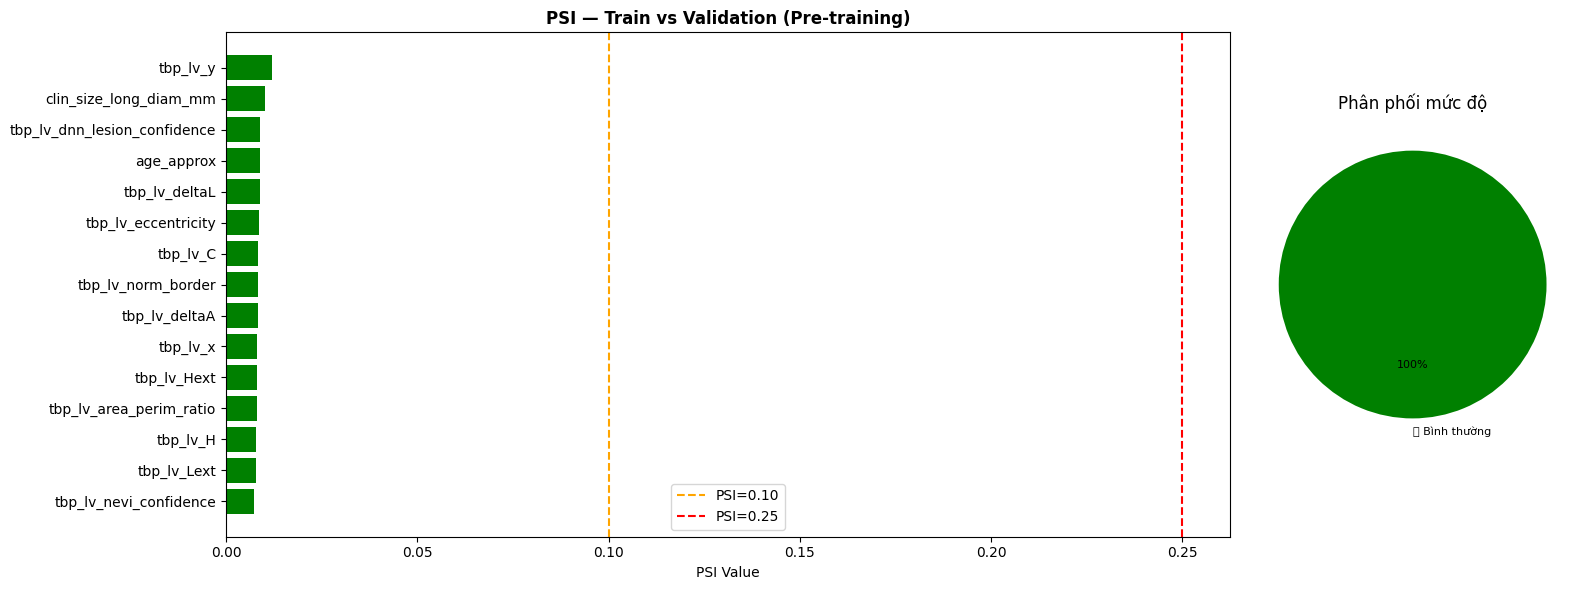


Tổng hợp PSI (37 features):
  🟢 Bình thường      : 37
  🟡 Cần theo dõi     : 0
  🔴 Drift nghiêm trọng: 0

📊 Statistical Tests: Train vs Validation

📊 KẾT QUẢ STATISTICAL TESTS (alpha=0.05)
   Tổng features  : 37
   Features drift : 3 (8.1%)


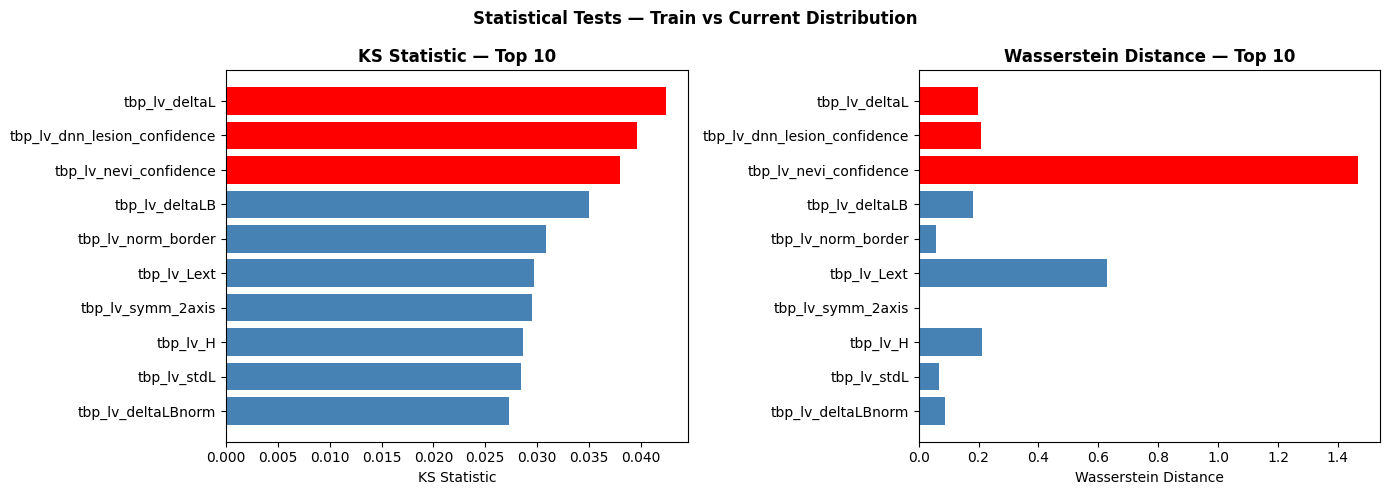


📸 Image Pixel Drift: Train vs Validation


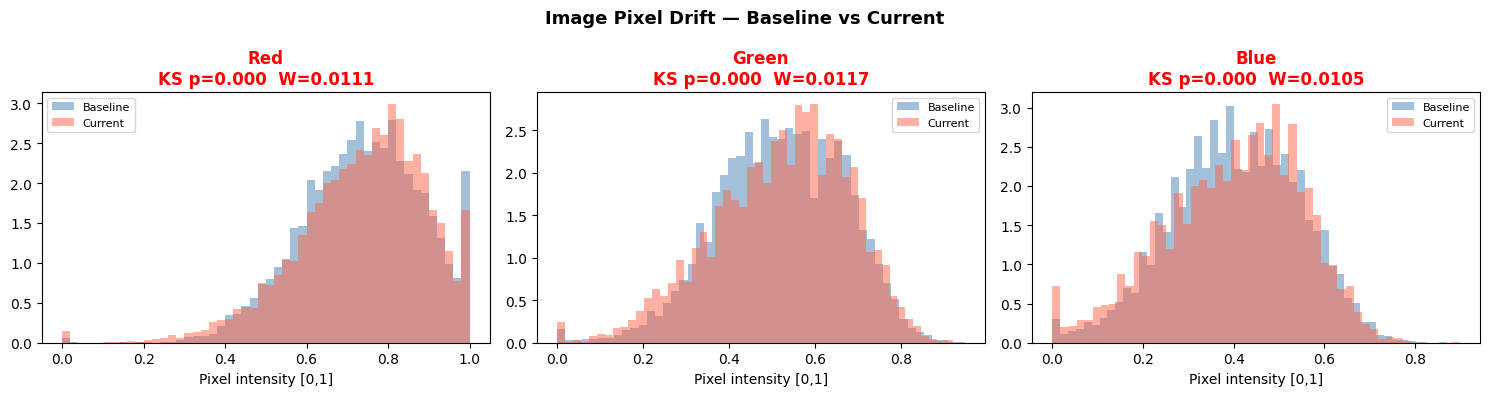


📊 Image Pixel Drift Results:
   Red: KS=0.0373  p=0.0000  W=0.0111  🔴 Drift
   Green: KS=0.0386  p=0.0000  W=0.0117  🔴 Drift
   Blue: KS=0.0398  p=0.0000  W=0.0105  🔴 Drift

📋 Pre-training Drift Report:
  📋 DATA DRIFT DETECTION REPORT — ISIC 2024 MULTIMODAL
  Generated: 2026-05-07 03:13:49 UTC

  📊 Tabular PSI (37 features)
     🟢 OK          : 37
     🟡 Theo dõi    : 0
     🔴 Drift nặng  : 0

  📊 KS-test: 3/37 features drifted

  📸 Image Pixel Drift: 3/3 channels

  TỔNG KẾT: 🟡 WARNING — Cần theo dõi chặt
  Alerts  : 2


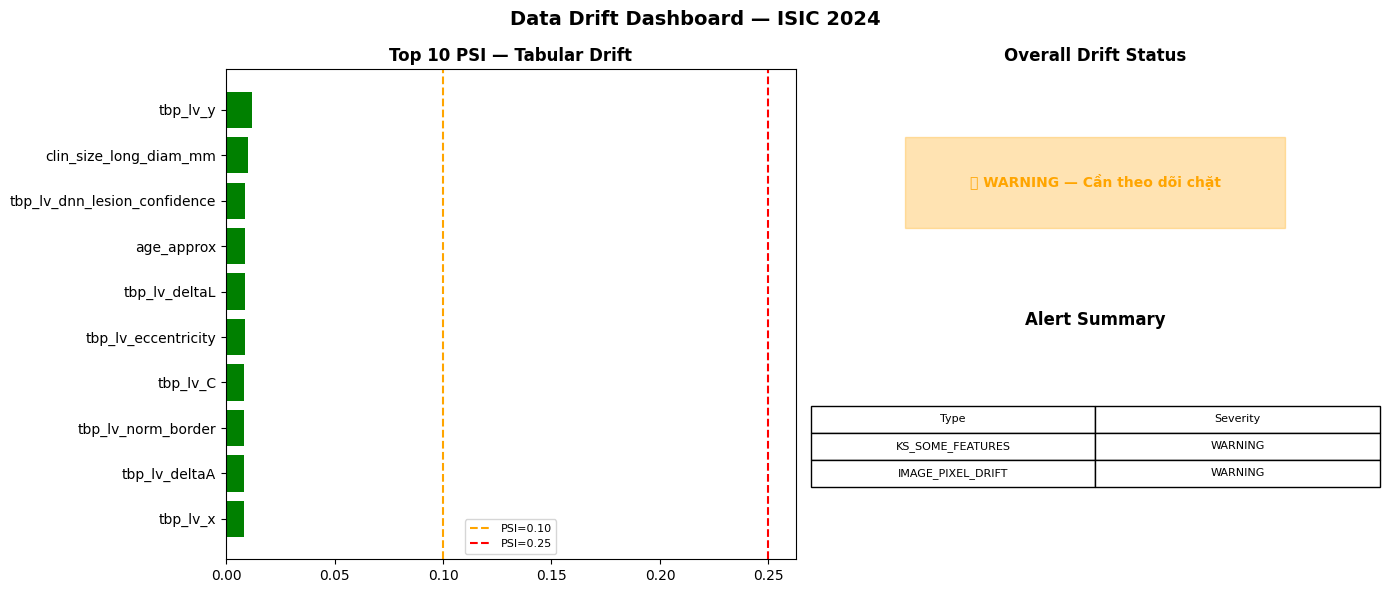


💾 Drift report → drift_report_pretrain.json


In [66]:
# ============================================================
# PHẦN 6.8: PRE-TRAINING DRIFT CHECK
# Chạy ngay sau prepare_multimodal_data() — TRƯỚC khi train
# ============================================================

print('=' * 60)
print('  PRE-TRAINING DATA DRIFT CHECK')
print('=' * 60)

# feature_names_drift = feature_names đã được định nghĩa ở phần XAI
feature_names_drift = feature_names

# 1. Lưu baseline từ training set
baseline_profile = save_baseline_profile(
    X_tab         = X_tab_train,
    feature_names = feature_names_drift,
    y             = y_train,
    pred_probs    = None,
    save_path     = 'baseline_profile_pretrain.json'
)

# 2. PSI: Train vs Validation
print('\n📊 PSI: Training set vs Validation set')
df_psi_pretrain = compute_all_psi(X_tab_train, X_tab_val, feature_names_drift)
plot_psi_heatmap(df_psi_pretrain, top_n=15,
                 title='PSI — Train vs Validation (Pre-training)')

# 3. Statistical tests: Train vs Val
print('\n📊 Statistical Tests: Train vs Validation')
df_stat_pretrain = run_statistical_tests(
    X_tab_train, X_tab_val, feature_names_drift, alpha=0.05, top_n=10)

# 4. Image pixel drift: Train vs Val
print('\n📸 Image Pixel Drift: Train vs Validation')
img_drift_pretrain = detect_image_pixel_drift(
    X_img_train[:200], X_img_val[:200], alpha=0.05)

# 5. Pre-training report
print('\n📋 Pre-training Drift Report:')
pretrain_report = generate_drift_report(
    df_psi            = df_psi_pretrain,
    df_stat           = df_stat_pretrain,
    img_drift_results = img_drift_pretrain,
    save_path         = 'drift_report_pretrain.json'
)


  POST-TRAINING DATA DRIFT CHECK

🔮 Getting model predictions...


2026-05-07 03:14:23.469700: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 03:14:23.562817: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 03:14:23.954838: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 03:14:24.043291: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 03:14:27.116365: E external/local_xla/xla/stream_

✅ Baseline profile → baseline_profile_posttrain.json
   Samples   : 6,651
   Features  : 37
   Malignant : 251 (3.77%)

📊 PSI: Training vs Test set


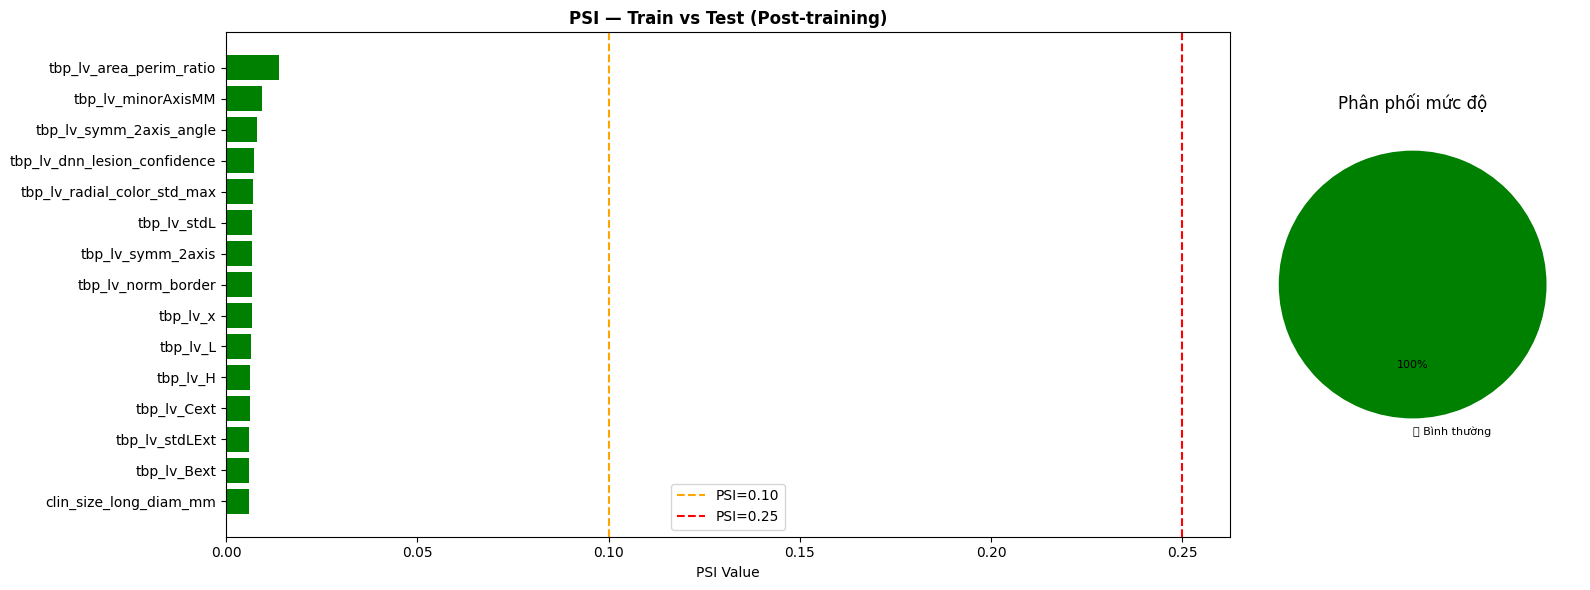


Tổng hợp PSI (37 features):
  🟢 Bình thường      : 37
  🟡 Cần theo dõi     : 0
  🔴 Drift nghiêm trọng: 0

📊 Statistical Tests: Train vs Test

📊 KẾT QUẢ STATISTICAL TESTS (alpha=0.05)
   Tổng features  : 37
   Features drift : 2 (5.4%)


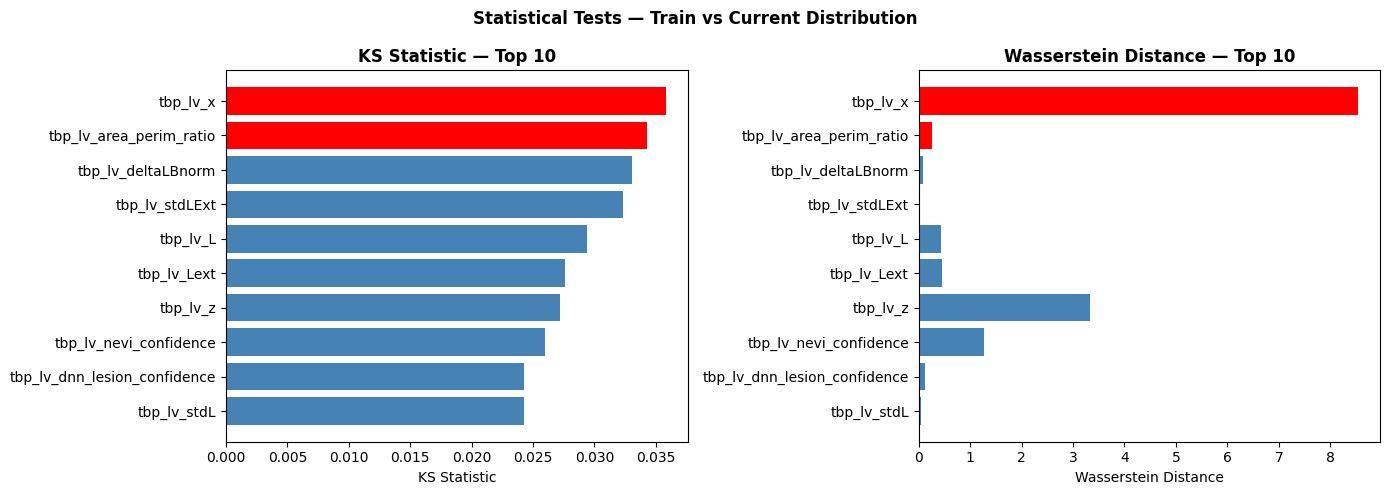


📸 Image Pixel Drift: Train vs Test


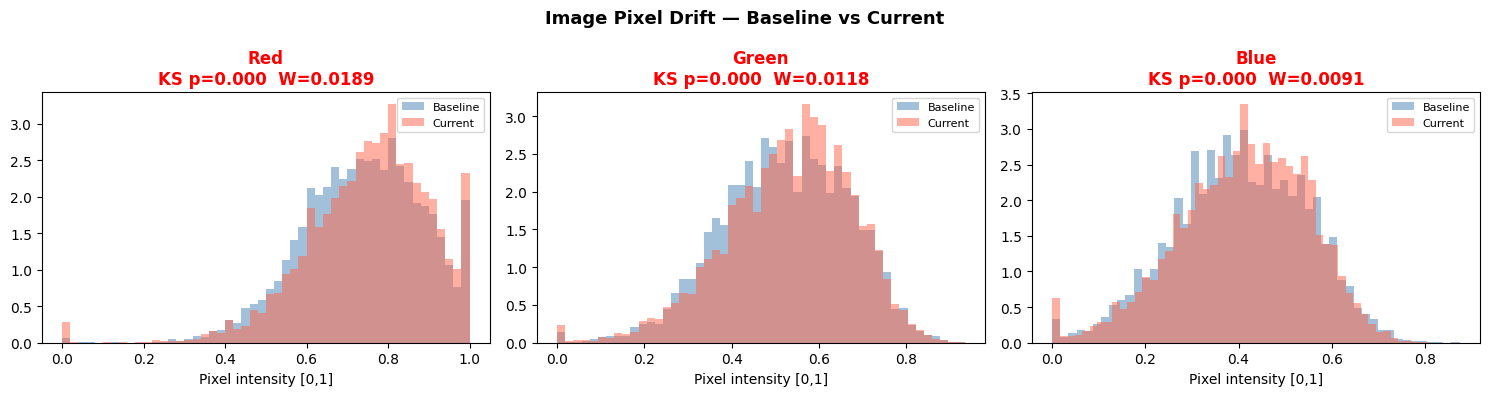


📊 Image Pixel Drift Results:
   Red: KS=0.0679  p=0.0000  W=0.0189  🔴 Drift
   Green: KS=0.0589  p=0.0000  W=0.0118  🔴 Drift
   Blue: KS=0.0391  p=0.0000  W=0.0091  🔴 Drift

🔍 Embedding Drift — EfficientNetB3:

🔍 Extracting embeddings from layer "global_average_pooling2d" ...


2026-05-07 03:15:56.493075: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 03:15:56.575209: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 03:15:59.519015: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 03:15:59.605616: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 03:16:00.107330: E external/local_xla/xla/stream_

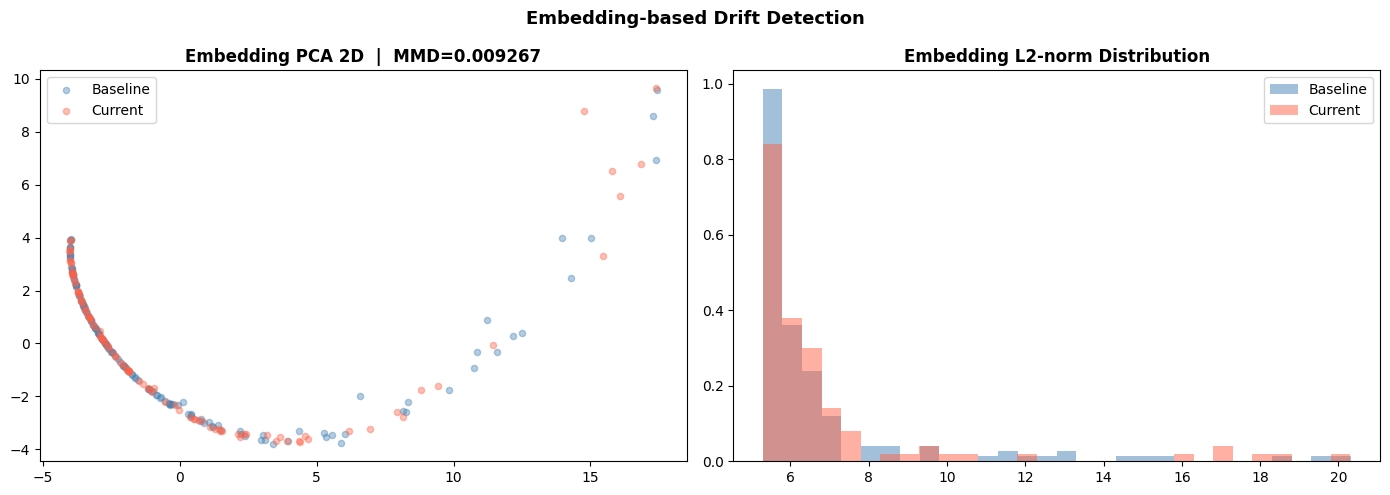


📊 Embedding Drift (MMD): 0.009267  🟢 OK

🎯 Prediction Distribution Drift:


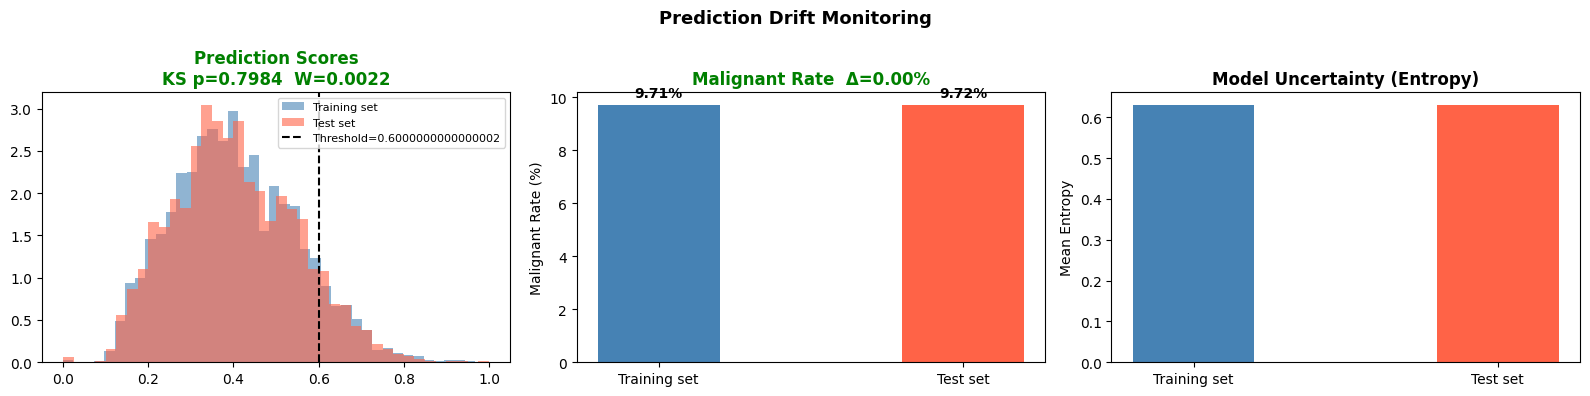


📊 PREDICTION DRIFT RESULTS:
   KS stat  : 0.0161   p=0.7984  🟢 OK
   Malignant rate — Base: 9.71%  Curr: 9.72%  🟢
  📋 DATA DRIFT DETECTION REPORT — ISIC 2024 MULTIMODAL
  Generated: 2026-05-07 03:16:33 UTC

  📊 Tabular PSI (37 features)
     🟢 OK          : 37
     🟡 Theo dõi    : 0
     🔴 Drift nặng  : 0

  📊 KS-test: 2/37 features drifted

  📸 Image Pixel Drift: 3/3 channels

  🎯 Prediction Drift
     KS p-value  : 0.7984
     Malignant Δ : 0.00%

  TỔNG KẾT: 🟡 WARNING — Cần theo dõi chặt
  Alerts  : 2


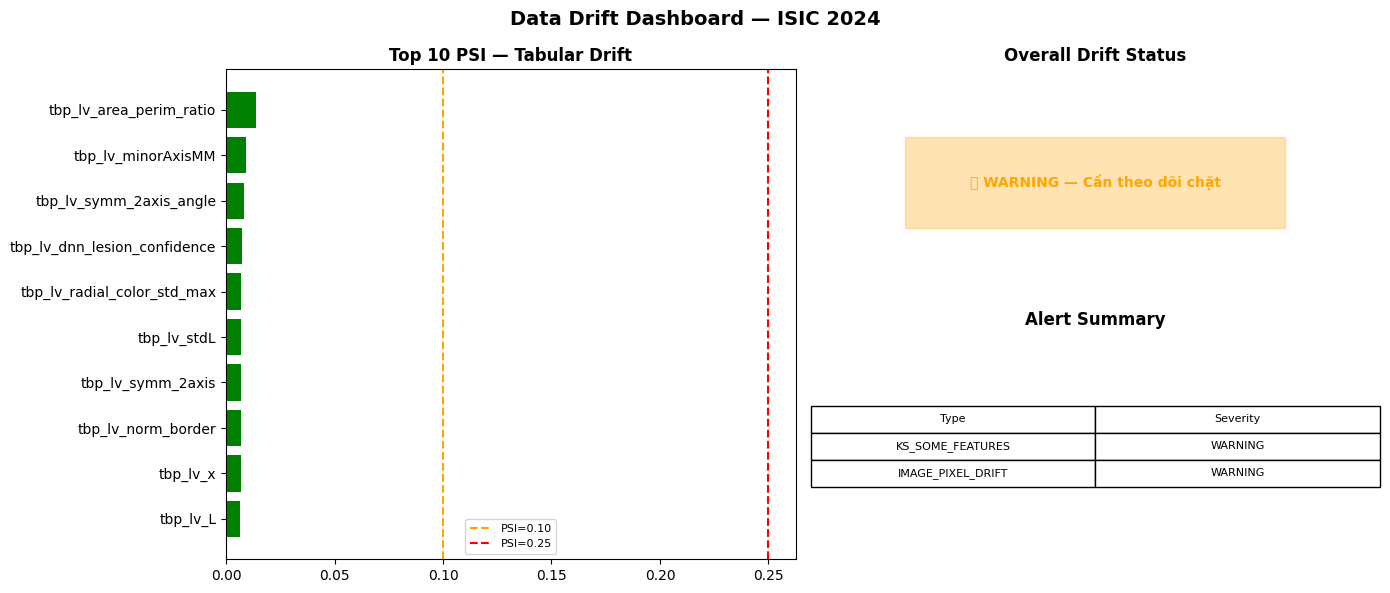


💾 Drift report → drift_report_posttrain.json

✅ Post-training drift check hoàn tất.
   File drift_report_posttrain.json sẵn sàng cho CI/CD pipeline.


In [67]:
# ============================================================
# PHẦN 6.9: POST-TRAINING DRIFT CHECK
# Chạy sau khi train xong — TRƯỚC khi deploy
# ============================================================

print('=' * 60)
print('  POST-TRAINING DATA DRIFT CHECK')
print('=' * 60)

# 1. Lấy prediction probabilities
print('\n🔮 Getting model predictions...')
train_probs = model.predict(
    {'image_input': X_img_train, 'tabular_input': X_tab_train},
    verbose=0, batch_size=64).flatten()
test_probs = model.predict(
    {'image_input': X_img_test, 'tabular_input': X_tab_test},
    verbose=0, batch_size=64).flatten()

# 2. Baseline profile với predictions
baseline_profile_post = save_baseline_profile(
    X_tab         = X_tab_train,
    feature_names = feature_names_drift,
    y             = y_train,
    pred_probs    = train_probs,
    save_path     = 'baseline_profile_posttrain.json'
)

# 3. PSI: Train vs Test
print('\n📊 PSI: Training vs Test set')
df_psi_post = compute_all_psi(X_tab_train, X_tab_test, feature_names_drift)
plot_psi_heatmap(df_psi_post, top_n=15, title='PSI — Train vs Test (Post-training)')

# 4. Statistical tests
print('\n📊 Statistical Tests: Train vs Test')
df_stat_post = run_statistical_tests(
    X_tab_train, X_tab_test, feature_names_drift, alpha=0.05, top_n=10)

# 5. Top drifted features chi tiết
top_drifted = df_psi_post[df_psi_post['psi'] >= 0.10]['feature'].tolist()[:6]
if top_drifted:
    print(f'\n📈 Distribution — Top {len(top_drifted)} features drift nhất:')
    plot_feature_drift_detail(X_tab_train, X_tab_test, feature_names_drift,
                               top_features=top_drifted, n_cols=3)

# 6. Image pixel drift
print('\n📸 Image Pixel Drift: Train vs Test')
img_drift_post = detect_image_pixel_drift(
    X_img_train[:200], X_img_test[:100], alpha=0.05)

# 7. Embedding drift
print('\n🔍 Embedding Drift — EfficientNetB3:')
embed_drift_post = compute_embedding_drift(
    model,
    X_img_train[:150], X_img_test[:100],
    X_tab_train[:150], X_tab_test[:100],
    n_sample=150
)

# 8. Prediction drift
print('\n🎯 Prediction Distribution Drift:')
pred_drift_post = monitor_prediction_drift(
    baseline_probs = train_probs,
    current_probs  = test_probs,
    threshold      = optimal_threshold,
    baseline_label = 'Training set',
    current_label  = 'Test set'
)

# 9. Dashboard tổng hợp
post_report = generate_drift_report(
    df_psi            = df_psi_post,
    df_stat           = df_stat_post,
    img_drift_results = img_drift_post,
    pred_drift_results= pred_drift_post,
    save_path         = 'drift_report_posttrain.json'
)

print('\n✅ Post-training drift check hoàn tất.')
print('   File drift_report_posttrain.json sẵn sàng cho CI/CD pipeline.')


In [68]:
# ─── Lưu train/val/test splits lên S3 (splits/) ────────────────────────────
import numpy as np, tempfile, os

def save_npy_to_s3(array, s3_key, bucket=S3_OUTPUT_BUCKET):
    with tempfile.NamedTemporaryFile(suffix='.npy', delete=False) as tmp:
        np.save(tmp.name, array)
        upload_to_s3(tmp.name, s3_key, bucket)
        os.unlink(tmp.name)

print('Saving train/val/test splits to S3...')

# Train
save_npy_to_s3(X_tab_train, 'splits/train/X_tab_train.npy')
save_npy_to_s3(X_img_train, 'splits/train/X_img_train.npy')
save_npy_to_s3(y_train,     'splits/train/y_train.npy')

# Validation
save_npy_to_s3(X_tab_val,   'splits/val/X_tab_val.npy')
save_npy_to_s3(X_img_val,   'splits/val/X_img_val.npy')
save_npy_to_s3(y_val,       'splits/val/y_val.npy')

# Test
save_npy_to_s3(X_tab_test,  'splits/test/X_tab_test.npy')
save_npy_to_s3(X_img_test,  'splits/test/X_img_test.npy')
save_npy_to_s3(y_test,      'splits/test/y_test.npy')

print(f'✅ Đã lưu splits lên s3://{S3_OUTPUT_BUCKET}/splits/')
print(f'   splits/train/ : X_tab_train, X_img_train, y_train')
print(f'   splits/val/   : X_tab_val,   X_img_val,   y_val')
print(f'   splits/test/  : X_tab_test,  X_img_test,  y_test')


Saving train/val/test splits to S3...
  Uploading /tmp/tmpl3jpdjd_.npy -> s3://kltn-isic-2024-colab/splits/train/X_tab_train.npy
   Done
  Uploading /tmp/tmphkfs1nu8.npy -> s3://kltn-isic-2024-colab/splits/train/X_img_train.npy
   Done
  Uploading /tmp/tmpj1bkrl5z.npy -> s3://kltn-isic-2024-colab/splits/train/y_train.npy
   Done
  Uploading /tmp/tmpw4ef2m6s.npy -> s3://kltn-isic-2024-colab/splits/val/X_tab_val.npy
   Done
  Uploading /tmp/tmp9av72u_3.npy -> s3://kltn-isic-2024-colab/splits/val/X_img_val.npy
   Done
  Uploading /tmp/tmpz3x_xn47.npy -> s3://kltn-isic-2024-colab/splits/val/y_val.npy
   Done
  Uploading /tmp/tmpwkxeounv.npy -> s3://kltn-isic-2024-colab/splits/test/X_tab_test.npy
   Done
  Uploading /tmp/tmpk4e44grw.npy -> s3://kltn-isic-2024-colab/splits/test/X_img_test.npy
   Done
  Uploading /tmp/tmph74qkys2.npy -> s3://kltn-isic-2024-colab/splits/test/y_test.npy
   Done
✅ Đã lưu splits lên s3://kltn-isic-2024-colab/splits/
   splits/train/ : X_tab_train, X_img_train, y_

In [69]:
from sklearn.model_selection import train_test_split

# Chia dữ liệu thành train+val (80%) và test (20%)
# stratify=y đảm bảo tỷ lệ benign/malignant đồng đều giữa các tập
X_img_trainval, X_img_test, X_tab_trainval, X_tab_test, y_trainval, y_test = train_test_split(
    X_image, X_tabular, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train+Validation set: Image shape {X_img_trainval.shape}, Tabular shape {X_tab_trainval.shape}, Labels {len(y_trainval)}")
print(f"  - Benign: {np.sum(y_trainval==0)}, Malignant: {np.sum(y_trainval==1)}")
print(f"Test set: Image shape {X_img_test.shape}, Tabular shape {X_tab_test.shape}, Labels {len(y_test)}")
print(f"  - Benign: {np.sum(y_test==0)}, Malignant: {np.sum(y_test==1)}")

Train+Validation set: Image shape (8314, 224, 224, 3), Tabular shape (8314, 37), Labels 8314
  - Benign: 8000, Malignant: 314
Test set: Image shape (2079, 224, 224, 3), Tabular shape (2079, 37), Labels 2079
  - Benign: 2000, Malignant: 79


In [70]:
def predict_skin_lesion(model, csv_data, image_path, tabular_columns, encoders=None):
    """
    Dự đoán khả năng ác tính (malignant) của tổn thương da - ISIC 2024 (Binary)

    Args:
        model: Mô hình đã huấn luyện
        csv_data: Đường dẫn CSV hoặc DataFrame metadata
        image_path: Đường dẫn ảnh
        tabular_columns: Danh sách cột đặc trưng dùng trong huấn luyện
        encoders: Dict các LabelEncoder cho cột phân loại

    Returns:
        dict chứa kết quả dự đoán
    """
    import pandas as pd
    import numpy as np
    import tensorflow as tf
    from PIL import Image

    # Load DataFrame
    if isinstance(csv_data, str):
        df = pd.read_csv(csv_data)
    else:
        df = csv_data

    # Lấy mẫu đầu tiên
    sample = df.iloc[0][tabular_columns].copy()

    # Tiền xử lý boolean
    bool_map = {"TRUE": 1, "FALSE": 0, "True": 1, "False": 0}
    for col in sample.index:
        val = sample[col]
        if isinstance(val, str) and val.strip().upper() in bool_map:
            sample[col] = bool_map[val.strip().upper()]

    # Mã hóa cột phân loại
    if encoders:
        for col in encoders:
            if col in sample and not pd.isna(sample[col]):
                sample[col] = encoders[col].transform([str(sample[col])])[0]

    # Điền NaN
    sample = sample.fillna(0)

    try:
        sample = sample.astype('float32')
    except Exception as e:
        print("[LỖI] Không thể ép kiểu float:", e)
        return None

    tabular_input = tf.constant(sample.values, dtype=tf.float32)[tf.newaxis, ...]

    # Load và tiền xử lý ảnh
    img_array = load_image(image_path, target_size=(224, 224))
    if img_array is None:
        print(f"[LỖI] Không thể tải ảnh: {image_path}")
        return None

    img_processed = preprocess_image(img_array)
    if img_processed is None:
        print(f"[LỖI] Lỗi tiền xử lý ảnh")
        return None

    image_input = tf.constant(img_processed, dtype=tf.float32)[tf.newaxis, ...]

    # Dự đoán
    prediction = model.predict({'image_input': image_input, 'tabular_input': tabular_input})

    # Xử lý output binary (sigmoid)
    if prediction.shape[-1] == 1:
        prob_malignant = float(prediction[0][0])
        prob_benign = 1.0 - prob_malignant
        predicted_class = 1 if prob_malignant > 0.5 else 0
        label = 'Malignant (Ác tính)' if predicted_class == 1 else 'Benign (Lành tính)'
        confidence = prob_malignant * 100 if predicted_class == 1 else prob_benign * 100
    else:
        prob_benign = float(prediction[0][0])
        prob_malignant = float(prediction[0][1])
        predicted_class = np.argmax(prediction[0])
        label = 'Malignant (Ác tính)' if predicted_class == 1 else 'Benign (Lành tính)'
        confidence = max(prob_benign, prob_malignant) * 100

    return {
        'diagnosis': label,
        'predicted_class': predicted_class,
        'confidence': confidence,
        'probabilities': {
            'Benign (0)': prob_benign * 100,
            'Malignant (1)': prob_malignant * 100
        }
    }

In [71]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Dự đoán với ISIC 2024 metadata
csv_path = LOCAL_METADATA

# Chọn một ảnh mẫu từ thư mục đã trích xuất
sample_image_name = image_files[0]  # Lấy ảnh đầu tiên trong thư mục
image_path = os.path.join(image_folder, sample_image_name)

# Recreate the full list of tabular columns used during model training
# This logic is extracted from `prepare_multimodal_data` function in cell_31
label_col = 'target'
id_col = 'isic_id'

exclude_cols = [label_col, id_col, 'patient_id', 'attribution', 'copyright_license',
                'image_type', 'iddx_full', 'iddx_1', 'iddx_2', 'iddx_3', 'iddx_4',
                'iddx_5', 'mel_mitotic_index', 'mel_thick_mm', 'lesion_id']

# Get numeric columns from df_subset (the filtered DataFrame used for X_tabular creation)
numeric_cols_from_subset = df_subset.select_dtypes(include=np.number).columns.tolist()
full_tabular_columns = [col for col in numeric_cols_from_subset if col not in exclude_cols]

# Add categorical columns that were encoded and used in X_tabular
cat_cols_for_tabular = ['sex', 'anatom_site_general']
for col in cat_cols_for_tabular:
    # Only add if not already present and is a column in the original df_subset
    if col in df_subset.columns and col not in full_tabular_columns:
        full_tabular_columns.append(col)

tabular_columns = full_tabular_columns

# Fit encoders for categorical columns using the df_subset (the filtered DataFrame used for training)
encoders = {}
for col in ['sex', 'anatom_site_general']:
    if col in df_subset.columns:
        le = LabelEncoder()
        # Ensure the column is treated as string for fitting
        le.fit(df_subset[col].astype(str))
        encoders[col] = le

# Dự đoán
# Pass df_subset instead of csv_path to ensure consistency with training data processing
result = predict_skin_lesion(model, df_subset, image_path, tabular_columns, encoders=encoders)
if result:
    print("\nKết quả dự đoán ISIC 2024:")
    print(f"Chẩn đoán: {result['diagnosis']}")
    print(f"Độ tin cậy: {result['confidence']:.2f}%")
    print(f"Xác suất Benign: {result['probabilities']['Benign (0)']:.2f}%")
    print(f"Xác suất Malignant: {result['probabilities']['Malignant (1)']:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step

Kết quả dự đoán ISIC 2024:
Chẩn đoán: Malignant (Ác tính)
Độ tin cậy: 62.54%
Xác suất Benign: 37.46%
Xác suất Malignant: 62.54%


In [72]:
from sklearn.preprocessing import LabelEncoder

df_meta = pd.read_csv(csv_path)

# Fit encoders cho các cột phân loại của ISIC 2024
encoders = {}
for col in ['sex', 'anatom_site_general']:
    if col in df_meta.columns:
        le = LabelEncoder()
        df_meta[col] = df_meta[col].astype(str)
        le.fit(df_meta[col])
        encoders[col] = le

# Gọi hàm dự đoán với encoders
result = predict_skin_lesion(
    model,
    csv_path,
    image_path,
    tabular_columns,
    encoders=encoders
)
if result:
    print("Chẩn đoán:", result['diagnosis'])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Chẩn đoán: Benign (Lành tính)


In [73]:
# Dự đoán cho một bệnh nhân mẫu từ ISIC 2024 metadata
df_meta = pd.read_csv(csv_path)

# Lọc các dòng có ảnh đã trích xuất
available_ids = set([os.path.splitext(f)[0] for f in image_files])
df_available = df_meta[df_meta['isic_id'].isin(available_ids)].reset_index(drop=True)

sample_row = df_available.iloc[1]  # Chọn dòng thứ 2
new_patient = sample_row.to_dict()

patient_image_path = os.path.join(image_folder, new_patient['isic_id'] + '.jpg')

# Recreate the full list of tabular columns and encoders, consistent with training
label_col = 'target'
id_col = 'isic_id'

exclude_cols = [label_col, id_col, 'patient_id', 'attribution', 'copyright_license',
                'image_type', 'iddx_full', 'iddx_1', 'iddx_2', 'iddx_3', 'iddx_4',
                'iddx_5', 'mel_mitotic_index', 'mel_thick_mm', 'lesion_id']

numeric_cols_from_subset = df_subset.select_dtypes(include=np.number).columns.tolist()
full_tabular_columns = [col for col in numeric_cols_from_subset if col not in exclude_cols]

cat_cols_for_tabular = ['sex', 'anatom_site_general']
for col in cat_cols_for_tabular:
    if col in df_subset.columns and col not in full_tabular_columns:
        full_tabular_columns.append(col)

tabular_columns = full_tabular_columns

encoders = {}
for col in ['sex', 'anatom_site_general']:
    if col in df_subset.columns:
        le = LabelEncoder()
        le.fit(df_subset[col].astype(str))
        encoders[col] = le

# Dự đoán
diagnosis_result = predict_skin_lesion(model, df_available, patient_image_path, tabular_columns, encoders=encoders)

if diagnosis_result:
    print(f"ISIC ID: {new_patient['isic_id']}")
    print(f"Nhãn thực tế (target): {new_patient.get('target', 'N/A')} (0=Benign, 1=Malignant)")
    print(f"Diagnosis: {diagnosis_result['diagnosis']}")
    print(f"Confidence: {diagnosis_result['confidence']:.2f}%")
    print("Probabilities:")
    for class_name, prob in diagnosis_result['probabilities'].items():
        print(f"  {class_name}: {prob:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
ISIC ID: ISIC_0076319
Nhãn thực tế (target): 0 (0=Benign, 1=Malignant)
Diagnosis: Malignant (Ác tính)
Confidence: 63.71%
Probabilities:
  Benign (0): 36.29%
  Malignant (1): 63.71%


In [74]:
# Trực quan hóa kết quả dự đoán ISIC 2024
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

def visualize_prediction(image_path, prediction_result, heatmap=None):
    """
    Hiển thị ảnh da liễu kèm theo kết quả dự đoán ISIC 2024 (Binary).

    Args:
        image_path (str): Đường dẫn ảnh.
        prediction_result (dict): Kết quả từ hàm predict_skin_lesion.
        heatmap (ndarray): Mảng 2D heatmap (tùy chọn).
    """
    image = Image.open(image_path).convert("RGB")
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Ảnh gốc với chẩn đoán
    axes[0].imshow(image)
    axes[0].axis('off')
    diagnosis = prediction_result['diagnosis']
    confidence = prediction_result['confidence']
    color = 'red' if 'Malignant' in diagnosis else 'green'
    axes[0].set_title(f"{diagnosis}\nĐộ tin cậy: {confidence:.2f}%",
                      fontsize=14, color=color, fontweight='bold')

    # Nếu có heatmap
    if heatmap is not None:
        heatmap_resized = np.array(Image.fromarray((heatmap * 255).astype(np.uint8)).resize(image.size))
        axes[0].imshow(heatmap_resized, cmap='jet', alpha=0.4)

    # Biểu đồ xác suất
    probs = prediction_result['probabilities']
    classes = list(probs.keys())
    values = list(probs.values())
    colors = ['steelblue' if 'Benign' in c else 'tomato' for c in classes]

    bars = axes[1].bar(classes, values, color=colors, edgecolor='black')
    axes[1].set_title('Xác suất dự đoán', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Xác suất (%)')
    axes[1].set_ylim(0, 100)
    for bar, val in zip(bars, values):
        axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                    f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step


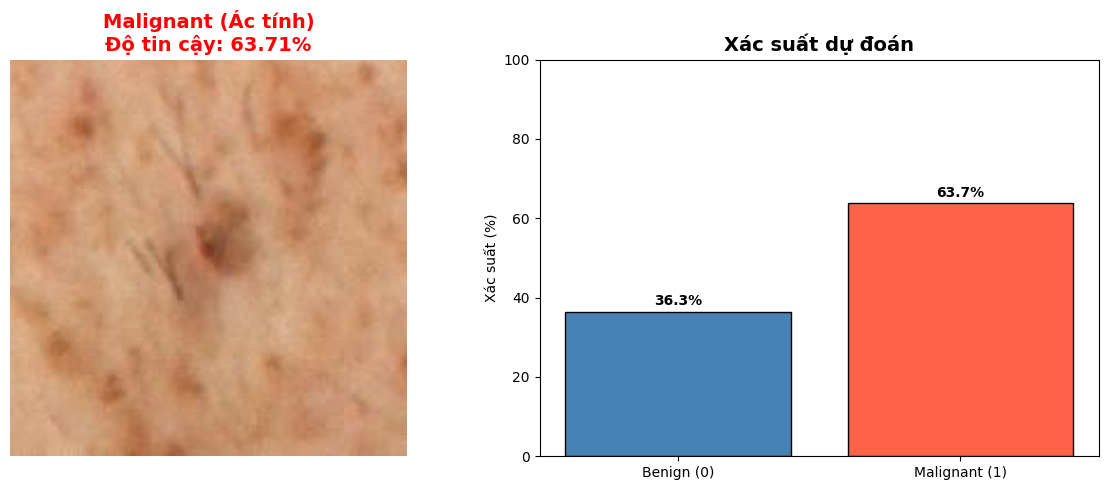

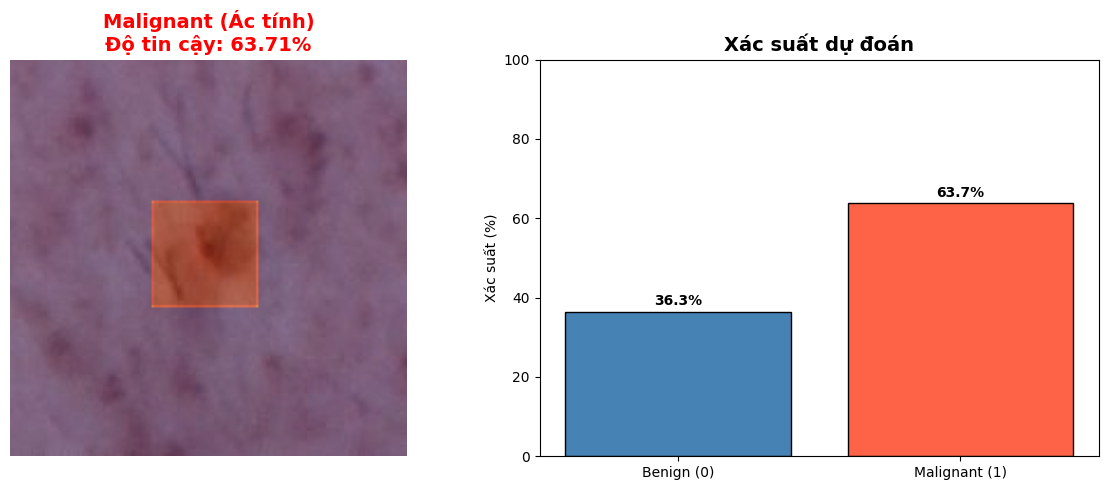

In [75]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import LabelEncoder

# Đọc metadata ISIC 2024
df_metadata = pd.read_csv(LOCAL_METADATA)

# Lọc các dòng có ảnh trong thư mục
available_ids = set([os.path.splitext(f)[0] for f in image_files])
df_available = df_metadata[df_metadata['isic_id'].isin(available_ids)].reset_index(drop=True)

# Lấy mẫu từ metadata
sample_row = df_available.iloc[1]  # Chọn dòng thứ 2
new_patient = sample_row.to_dict()
patient_image_path = os.path.join(image_folder, new_patient['isic_id'] + '.jpg')

# Recreate the full list of tabular columns and encoders, consistent with training
label_col = 'target'
id_col = 'isic_id'

exclude_cols = [label_col, id_col, 'patient_id', 'attribution', 'copyright_license',
                'image_type', 'iddx_full', 'iddx_1', 'iddx_2', 'iddx_3', 'iddx_4',
                'iddx_5', 'mel_mitotic_index', 'mel_thick_mm', 'lesion_id']

numeric_cols_from_subset = df_subset.select_dtypes(include=np.number).columns.tolist()
full_tabular_columns = [col for col in numeric_cols_from_subset if col not in exclude_cols]

cat_cols_for_tabular = ['sex', 'anatom_site_general']
for col in cat_cols_for_tabular:
    if col in df_subset.columns and col not in full_tabular_columns:
        full_tabular_columns.append(col)

tabular_columns = full_tabular_columns

encoders = {}
for col in ['sex', 'anatom_site_general']:
    if col in df_subset.columns:
        le = LabelEncoder()
        le.fit(df_subset[col].astype(str))
        encoders[col] = le

# Gọi hàm dự đoán
diagnosis_result = predict_skin_lesion(model, df_available, patient_image_path, tabular_columns, encoders=encoders)

if diagnosis_result:
    # Trực quan hóa không có heatmap
    visualize_prediction(patient_image_path, diagnosis_result)

    # Tạo heatmap mẫu (mô phỏng vùng nghi ngờ)
    dummy_heatmap = np.zeros((224, 224))
    dummy_heatmap[80:140, 80:140] = 1.0

    # Trực quan hóa với heatmap
    visualize_prediction(patient_image_path, diagnosis_result, heatmap=dummy_heatmap)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


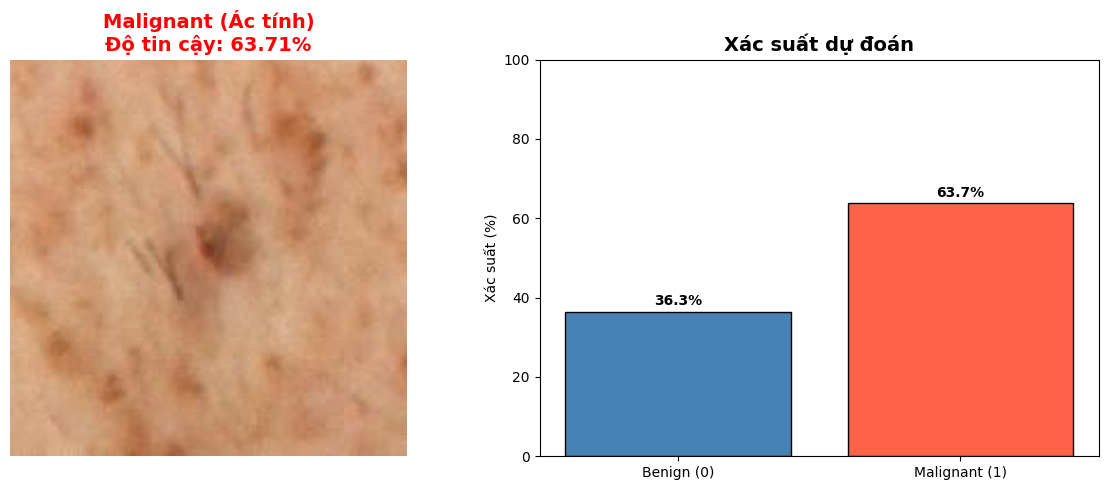

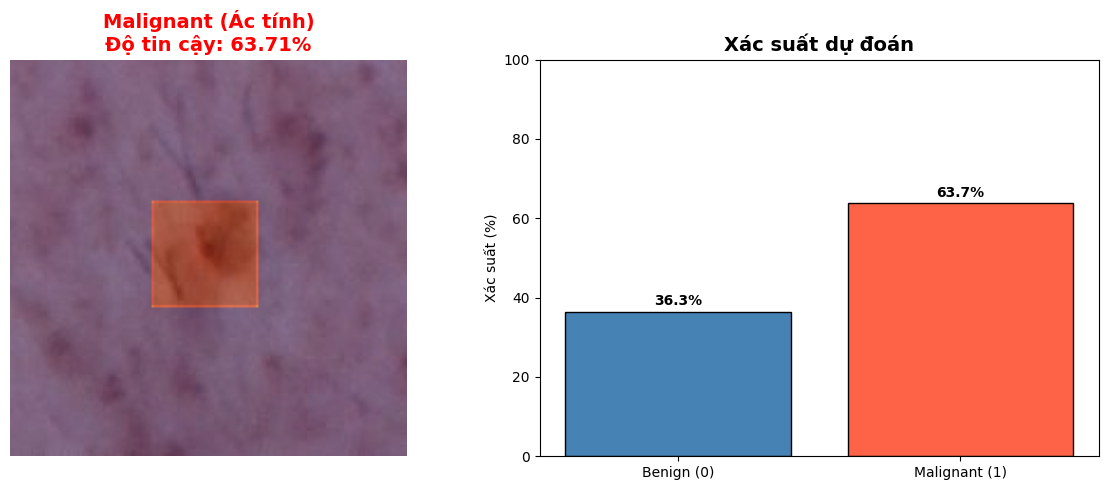

In [76]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import LabelEncoder

# Đọc metadata ISIC 2024
df_metadata = pd.read_csv(LOCAL_METADATA)

# Lọc các dòng có ảnh
available_ids = set([os.path.splitext(f)[0] for f in image_files])
df_available = df_metadata[df_metadata['isic_id'].isin(available_ids)].reset_index(drop=True)

# Lấy mẫu
sample_row = df_available.iloc[1]
new_patient = sample_row.to_dict()
patient_image_path = os.path.join(image_folder, new_patient['isic_id'] + '.jpg')

# Recreate the full list of tabular columns and encoders, consistent with training
label_col = 'target'
id_col = 'isic_id'

exclude_cols = [label_col, id_col, 'patient_id', 'attribution', 'copyright_license',
                'image_type', 'iddx_full', 'iddx_1', 'iddx_2', 'iddx_3', 'iddx_4',
                'iddx_5', 'mel_mitotic_index', 'mel_thick_mm', 'lesion_id']

numeric_cols_from_subset = df_subset.select_dtypes(include=np.number).columns.tolist()
full_tabular_columns = [col for col in numeric_cols_from_subset if col not in exclude_cols]

cat_cols_for_tabular = ['sex', 'anatom_site_general']
for col in cat_cols_for_tabular:
    if col in df_subset.columns and col not in full_tabular_columns:
        full_tabular_columns.append(col)

tabular_columns = full_tabular_columns

encoders = {}
for col in ['sex', 'anatom_site_general']:
    if col in df_subset.columns:
        le = LabelEncoder()
        le.fit(df_subset[col].astype(str))
        encoders[col] = le

# Gọi hàm dự đoán
diagnosis_result = predict_skin_lesion(model, df_available, patient_image_path, tabular_columns, encoders=encoders)

if diagnosis_result:
    # Trực quan hóa không có heatmap
    visualize_prediction(patient_image_path, diagnosis_result)

    # Tạo heatmap mẫu
    dummy_heatmap = np.zeros((224, 224))
    dummy_heatmap[80:140, 80:140] = 1.0

    # Trực quan hóa với heatmap
    visualize_prediction(patient_image_path, diagnosis_result, heatmap=dummy_heatmap)